# Clustering of all data

Read in all necessary packages:

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
import loompy
import collections
import scipy
import math
from matplotlib.colors import LinearSegmentedColormap
import random
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson

import scipy
import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_9835/284414565.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


OMP: Info #273: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [112]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

In [4]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)

k27_k4 = sns.blend_palette(['#6a51a3', '#9e9bc8', '#dadaeb','#c8e9c1','#75c477','#238b45'], as_cmap = True)
k4_k27 = sns.blend_palette(['#238b45', '#75c477', '#c8e9c1' ,'#dadaeb','#9e9bc8','#6a51a3' ], as_cmap = True)
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'


In [5]:
cols = ['grey','skyblue','orange','red']
cols2 = ['white','deepskyblue','orange','red','grey']

leg_dict2 = {'negative': 'grey','positive': 'skyblue','going up': 'orange','going down': 'red'}
coldict=dict(zip(list(pd.DataFrame([0,1,2,3,4]).astype('category')[0]), cols2))
leg_dict = {'negative': 'white', 'positive': 'deepskyblue', 'going up': 'orange', 'going down': 'red'}

In [187]:
pseudo = []
def bintable(df, stepsize):    
    df = df.sort_values(by = ['hour','pseudotime'],ascending=True)
    df['order'] = list(range(0,len(df)))
    df['steps'] = df['order'].apply(lambda x: np.floor(x/stepsize))
    binned_table_mean = {}
    binned_table_sum = {}
    celltype = []
    for step in df['steps'].unique():
        binned_table_mean[step] = df[df['steps'] == step].mean(numeric_only=True)
        binned_table_sum[step] = df[df['steps'] == step].sum(numeric_only=True)
        celltype.append(df[df['steps'] == step]['hour'].value_counts().sort_values(ascending=False).index[0])
    binned_pseudo = pd.DataFrame(pd.DataFrame(binned_table_mean).T['pseudotime'])
    binned_pseudo['celltype'] = celltype
    binned_final_mean = pd.DataFrame(binned_table_mean).T.drop(['order','steps','pseudotime'],axis = 1)
    binned_final_sum = pd.DataFrame(binned_table_sum).T.drop(['order','steps','pseudotime'],axis = 1)
    binned_pseudo = binned_pseudo.iloc[:-1,:]
    binned_final_mean = binned_final_mean.iloc[:-1,:]
    binned_final_sum = binned_final_sum.iloc[:-1,:]
    return binned_pseudo, binned_final_mean, binned_final_sum

## K4me3 TSS table

In [54]:
tss_k4 = pd.read_csv('../data/peter/20240114_H3K4me3_sc_selected_dyn_TSS.tsv', sep = '\t', index_col=0)

In [55]:
tss_k4.index.name = 'cell'
tss_k4.head(2)

,Dlgap1:1,Dlgap1:2,Dlgap1:3,Dlgap1:4,Dlgap1:5,Dlgap1:6,Ank3:1,Ank3:2,Ank3:3,Ank3:4,...,Lima1:3,Rabgap1l:1,Rabgap1l:2,Rabgap1l:3,Rabgap1l:4,Rabgap1l:5,Rabgap1l:6,Rabgap1l:7,Rabgap1l:8,Rabgap1l:9
cell,,,,,,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd6-rep2-H3K4me3-4_199,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ-MB-TChIC-Gastd7-rep2-H3K4me3-2_237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
tss_k4.shape

(25344, 381)

## K27me3 TSS table

In [10]:
tss_k27 = pd.read_csv('../data/peter/20240114_H3K27me3_sc_selected_dyn_TSS.tsv', sep = '\t', index_col=0)
tss_k27.index.name = 'cell'

In [11]:
tss_k27.head(2)

,Dlgap1:1,Dlgap1:2,Dlgap1:3,Dlgap1:4,Dlgap1:5,Dlgap1:6,Ank3:1,Ank3:2,Ank3:3,Ank3:4,...,Lima1:3,Rabgap1l:1,Rabgap1l:2,Rabgap1l:3,Rabgap1l:4,Rabgap1l:5,Rabgap1l:6,Rabgap1l:7,Rabgap1l:8,Rabgap1l:9
cell,,,,,,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-2_227,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-2_237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
tss_k27.shape

(25344, 381)

## RNA table

In [392]:
tss_rna = pd.read_csv('../data/peter/20240114_RNA_sc_selected_dyn_TSS.tsv', sep = '\t', index_col=0)
tss_rna.index.name = 'cell'

In [395]:
tss_rna = tss_rna.T
tss_rna.head(2)

cell,Dlgap1:1,Dlgap1:2,Dlgap1:3,Dlgap1:4,Dlgap1:5,Dlgap1:6,Ank3:1,Ank3:2,Ank3:3,Ank3:4,...,Lima1:3,Rabgap1l:1,Rabgap1l:2,Rabgap1l:3,Rabgap1l:4,Rabgap1l:5,Rabgap1l:6,Rabgap1l:7,Rabgap1l:8,Rabgap1l:9
PZ-MB-TChIC-Gastd6-rep2-H3K27me3-2_78,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PZ-MB-TChIC-Gastd7-rep3-H3K27me3-6_227,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [396]:
tss_rna.shape

(50688, 381)

## plotting

## some QC

Text(0.5, 1.0, 'K4 cells')

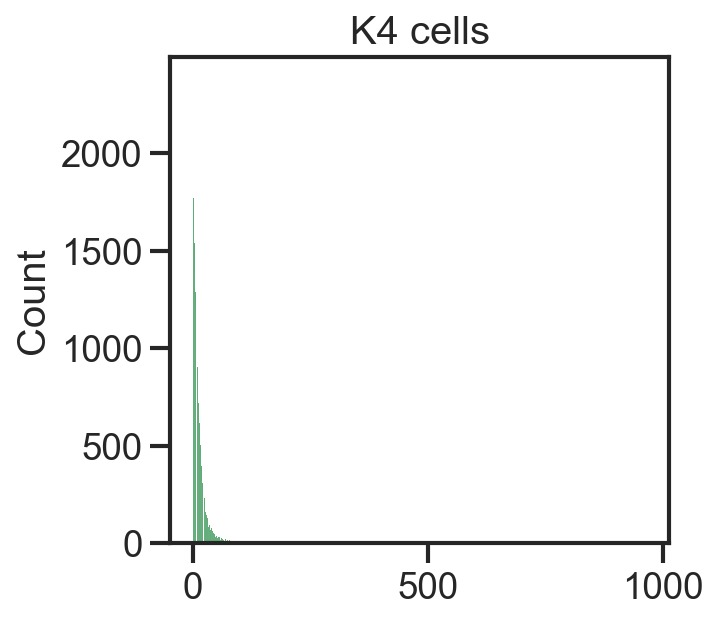

In [20]:
sns.histplot(tss_k4.sum(axis=1), color = Green)
plt.title('K4 cells')

Text(0.5, 1.0, 'K4 genes')

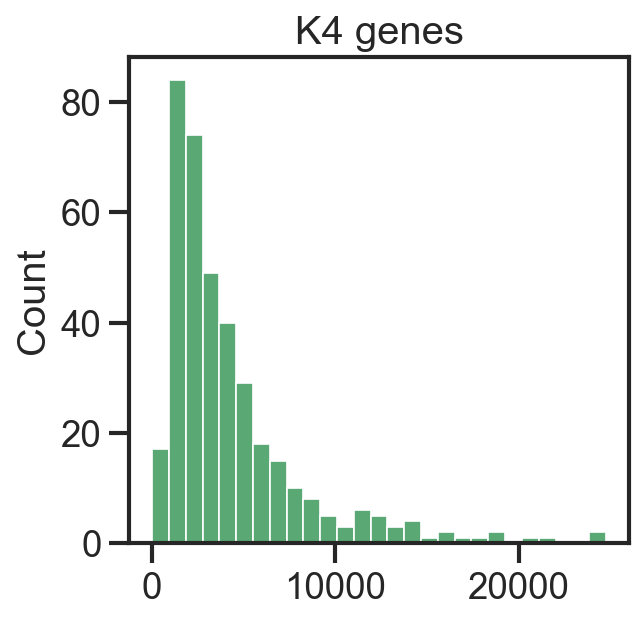

In [21]:
sns.histplot(tss_k27.sum(axis=0), color = Green)
plt.title('K4 genes')

Text(0.5, 1.0, 'K27 cells')

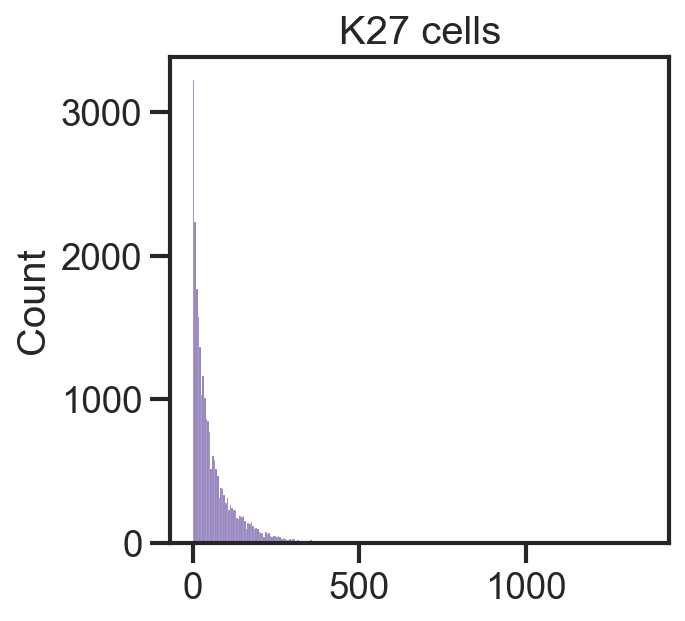

In [18]:
sns.histplot(tss_k27.sum(axis=1), color = Purple)
plt.title('K27 cells')

Text(0.5, 1.0, 'K27 genes')

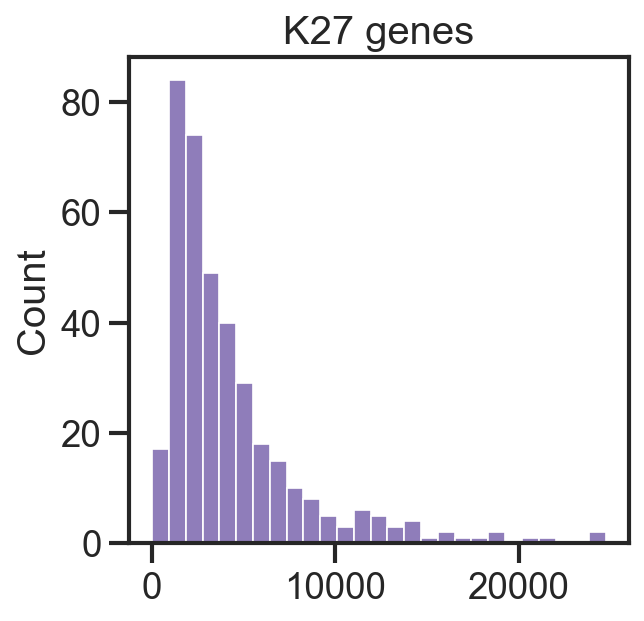

In [19]:
sns.histplot(tss_k27.sum(axis=0), color = Purple)
plt.title('K27 genes')

Text(0.5, 1.0, 'RNA cells')

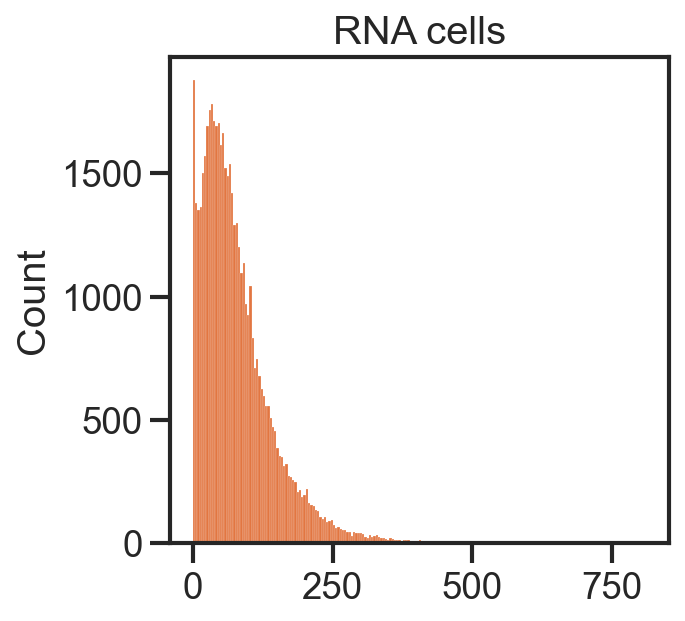

In [398]:
sns.histplot(tss_rna.sum(axis=1), color = Orange)
plt.title('RNA cells')

Text(0.5, 1.0, 'RNA genes')

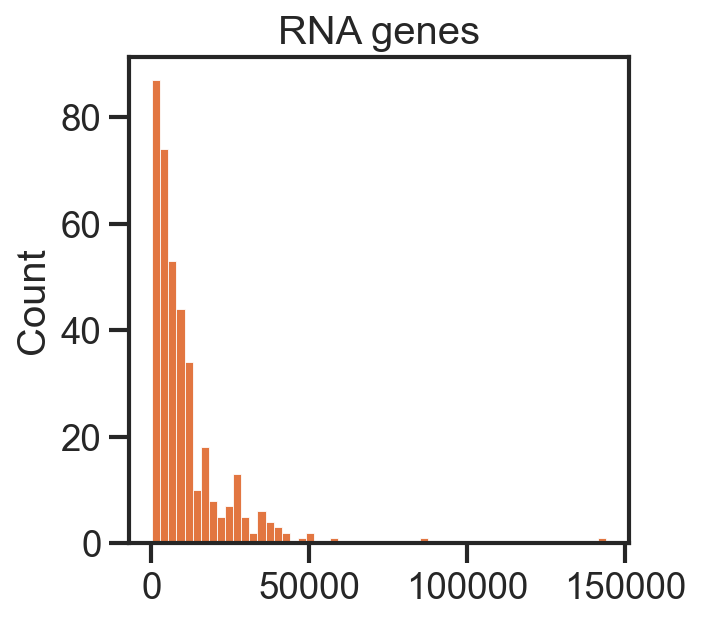

In [400]:
sns.histplot(tss_rna.sum(axis=0), color = Orange)
plt.title('RNA genes')

In [27]:
tss_k4.sum(axis=1).sort_values().value_counts()

0.0      2377
1.0      1770
2.0      1621
3.0      1541
4.0      1395
         ... 
193.0       1
192.0       1
190.0       1
189.0       1
965.0       1
Length: 249, dtype: int64

In [26]:
tss_k27.sum(axis=1).sort_values().value_counts()

0.0       961
1.0       677
2.0       578
3.0       531
5.0       494
         ... 
375.0       1
503.0       1
501.0       1
500.0       1
1364.0      1
Length: 578, dtype: int64

In [401]:
tss_rna.sum(axis=1).sort_values().value_counts()

34     469
36     460
54     445
32     445
47     444
      ... 
475      1
476      1
420      1
479      1
812      1
Length: 487, dtype: int64

## load adata file, subset dataframes

In [43]:
# remove zero counts
tss_k4 = tss_k4[tss_k4.sum(axis=1) != 0 ]
tss_k27 = tss_k27[tss_k27.sum(axis=1) != 0 ]

In [58]:
idx = tss_k4.columns.str.split(':', expand=True)
tss_k4.columns = idx
tss_k4.columns.names = ['gene','TSS']

In [61]:
idx = tss_k27.columns.str.split(':', expand=True)
tss_k27.columns = idx
tss_k27.columns.names = ['gene','TSS']

In [60]:
tss_k4.head(3)

gene                                  Dlgap1                          Ank3  \
TSS                                        1    2    3    4    5    6    1   
cell                                                                         
PZ-MB-TChIC-Gastd6-rep2-H3K4me3-4_199    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PZ-MB-TChIC-Gastd7-rep2-H3K4me3-2_237    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PZ-MB-TChIC-Gastd6-rep2-H3K4me3-1_362    0.0  0.0  0.0  0.0  0.0  0.0  0.0   

gene                                                  ... Lima1 Rabgap1l       \
TSS                                      2    3    4  ...     3        1    2   
cell                                                  ...                       
PZ-MB-TChIC-Gastd6-rep2-H3K4me3-4_199  1.0  0.0  0.0  ...   0.0      0.0  0.0   
PZ-MB-TChIC-Gastd7-rep2-H3K4me3-2_237  0.0  0.0  0.0  ...   0.0      0.0  0.0   
PZ-MB-TChIC-Gastd6-rep2-H3K4me3-1_362  0.0  0.0  0.0  ...   0.0      0.0  0.0   

gene                                                                      
TSS                                      3    4    5    6    7    8    9  
cell                                                                      
PZ-MB-TChIC-Gastd6-rep2-H3K4me3-4_199  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
PZ-MB-TChIC-Gastd7-rep2-H3K4me3-2_237  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
PZ-MB-TChIC-Gastd6-rep2-H3K4me3-1_362  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[3 rows x 381 columns]

In [62]:
tss_k27.head(3)

gene                                   Dlgap1                          Ank3  \
TSS                                         1    2    3    4    5    6    1   
cell                                                                          
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-2_227    1.0  0.0  0.0  0.0  0.0  0.0  1.0   
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-2_237    0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PZ-MB-TChIC-Gastd7-rep2-H3K27me3-4_363    0.0  0.0  0.0  0.0  0.0  0.0  0.0   

gene                                                   ... Lima1 Rabgap1l  \
TSS                                       2    3    4  ...     3        1   
cell                                                   ...                  
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-2_227  0.0  0.0  0.0  ...   0.0      0.0   
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-2_237  0.0  0.0  0.0  ...   0.0      0.0   
PZ-MB-TChIC-Gastd7-rep2-H3K27me3-4_363  0.0  0.0  0.0  ...   0.0      0.0   

gene                                                                            
TSS                                       2    3    4    5    6    7    8    9  
cell                                                                            
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-2_227  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
PZ-MB-TChIC-Gastd4-rep4-H3K27me3-2_237  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
PZ-MB-TChIC-Gastd7-rep2-H3K27me3-4_363  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[3 rows x 381 columns]

In [402]:
tss_rna = tss_rna[tss_rna.sum(axis=1) != 0 ]
idx = tss_rna.columns.str.split(':', expand=True)
tss_rna.columns = idx
tss_rna.columns.names = ['gene','TSS']
tss_rna.head(3)

gene                                   Dlgap1                Ank3           \
TSS                                         1  2  3  4  5  6    1  2  3  4   
PZ-MB-TChIC-Gastd6-rep2-H3K27me3-2_78       0  0  0  0  0  0    0  0  0  0   
PZ-MB-TChIC-Gastd7-rep3-H3K27me3-6_227      0  0  0  0  0  0    0  0  0  0   
PZ-MB-TChIC-Gastd7-rep3-H3K27me3-2_174      0  0  0  0  0  0    0  1  0  0   

gene                                    ... Lima1 Rabgap1l                    \
TSS                                     ...     3        1  2  3  4  5  6  7   
PZ-MB-TChIC-Gastd6-rep2-H3K27me3-2_78   ...     0        0  0  0  0  0  0  0   
PZ-MB-TChIC-Gastd7-rep3-H3K27me3-6_227  ...     0        0  0  0  0  0  0  0   
PZ-MB-TChIC-Gastd7-rep3-H3K27me3-2_174  ...     0        0  0  0  0  0  1  1   

gene                                          
TSS                                     8  9  
PZ-MB-TChIC-Gastd6-rep2-H3K27me3-2_78   0  0  
PZ-MB-TChIC-Gastd7-rep3-H3K27me3-6_227  0  0  
PZ-MB-TChIC-Gastd7-rep3-H3K27me3-2_174  1  0  

[3 rows x 381 columns]

In [66]:
adata = sc.read_h5ad('../data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

In [264]:
pseudo = pd.DataFrame(adata.obs['pseudotime'])
#pseudo = pseudo[(adata.obs['lineage'] == 'Pluripotent')]
pseudo = pseudo[adata.obs['celltype'] != 'PGCs']
pseudo = pseudo[adata.obs['celltype'] != 'Epidermis Progenitors']
pseudo = pseudo[adata.obs['celltype'] != 'Epiblast']
pseudo = pseudo[adata.obs['celltype'] != 'Naive PGCs']
pseudo = pseudo[adata.obs['celltype'] != 'Reprogramming PGCs']
##pseudo = pseudo[adata.obs['celltype'] != 'mESCs']

pseudo.head(2)

,pseudotime
index,
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_341,56.601980
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_310,30.236847


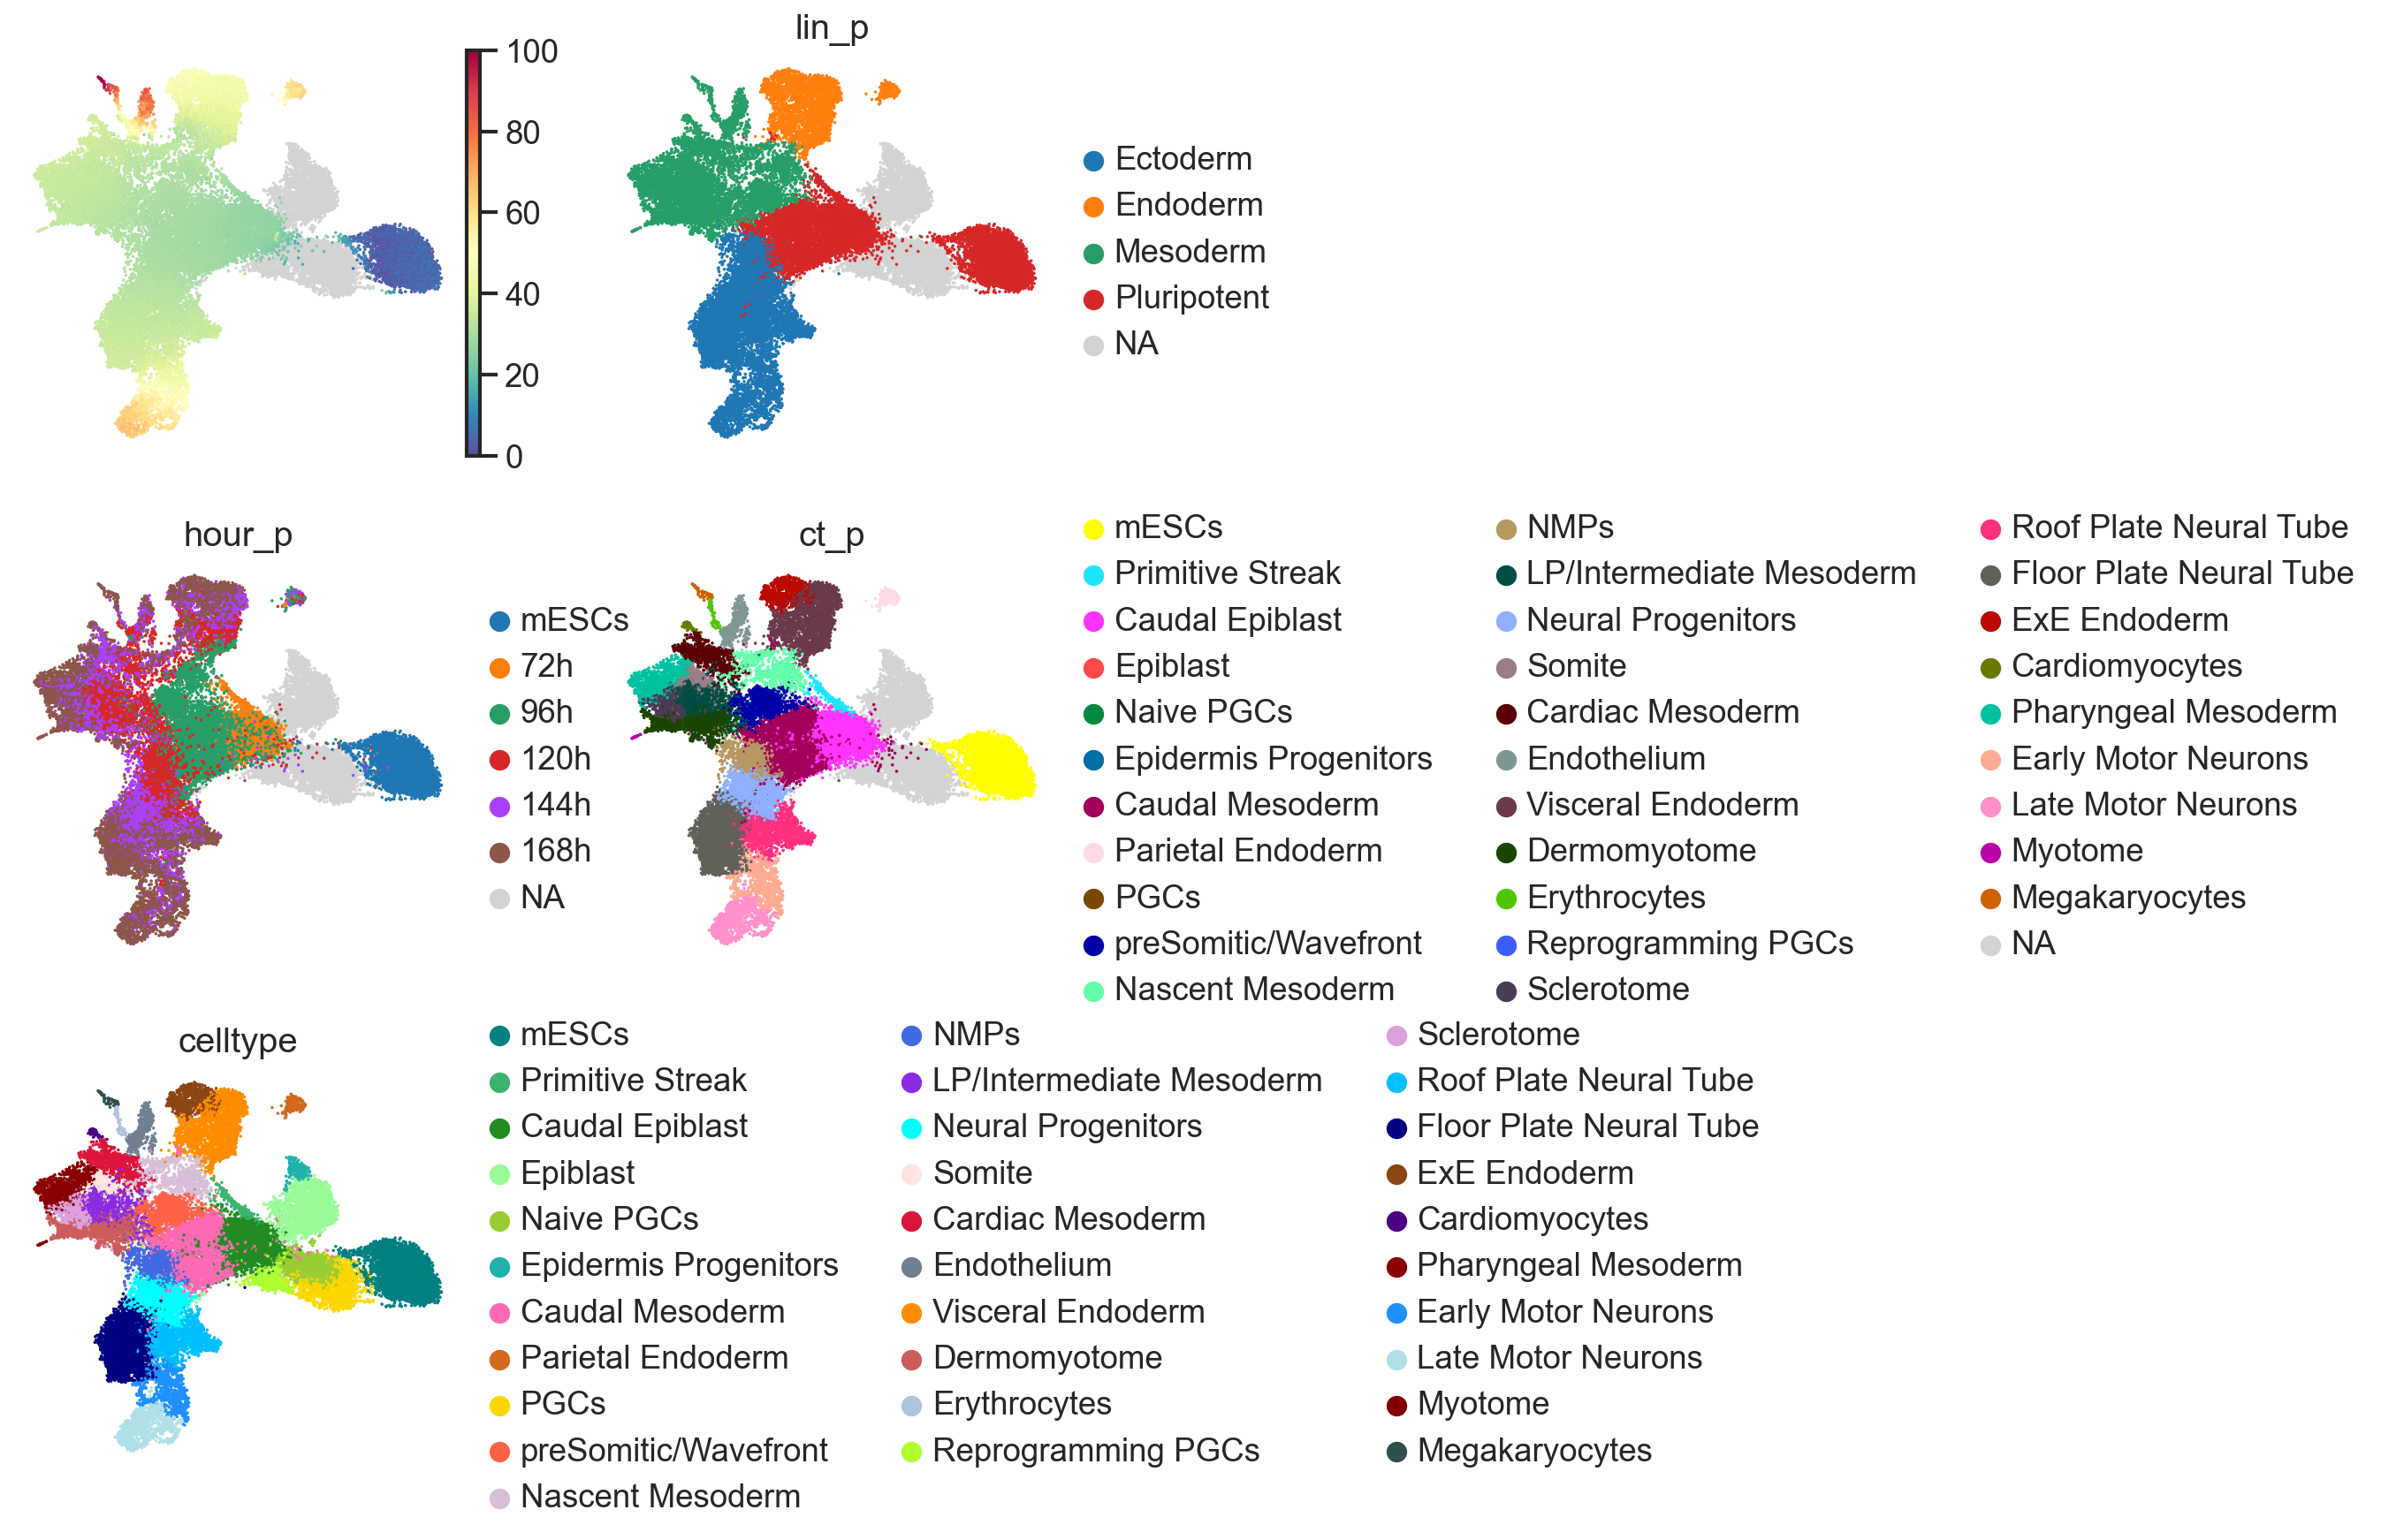

In [459]:
adata.obs['pseudo_p'] = adata.obs.loc[pseudo.index]['pseudotime']
adata.obs['lin_p'] = adata.obs.loc[pseudo.index]['lineage']
adata.obs['ct_p'] = adata.obs.loc[pseudo.index]['celltype']
adata.obs['hour_p'] = adata.obs.loc[pseudo.index]['hour']
sc.pl.umap(adata,color = ['pseudo_p','lin_p','hour_p','ct_p','celltype'], frameon = False, cmap = 'Spectral_r',size = 10, vmin = 0, vmax = 100, title = '', ncols=2)

In [72]:
common_barcodes = np.intersect1d(tss_k4.index,pseudo.index).astype(str)
df_k4 = tss_k4.loc[common_barcodes]


In [73]:
df_k4.shape

(15248, 381)

In [74]:
tss_k4.shape

(25344, 381)

In [100]:
df_k4['pseudo'] = pseudo['pseudotime']
df_k4['lineage'] = adata.obs['lineage']

In [101]:
df_k4 = df_k4[~df_k4['pseudo'].isna()]

In [102]:
df_k4 = df_k4.sort_values(by='pseudo')
df_k4.head(2)

gene                                Dlgap1                          Ank3       \
TSS                                      1    2    3    4    5    6    1    2   
cell                                                                            
PZ-MB-TChIC-mESCs-rep4-H3K4me3-3_22    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K4me3-5_51    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

gene                                           ... Rabgap1l                 \
TSS                                    3    4  ...        2    3    4    5   
cell                                           ...                           
PZ-MB-TChIC-mESCs-rep4-H3K4me3-3_22  0.0  0.0  ...      0.0  0.0  0.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K4me3-5_51  0.0  0.0  ...      0.0  0.0  0.0  0.0   

gene                                                       pseudo      lineage  
TSS                                    6    7    8    9                         
cell                                                                            
PZ-MB-TChIC-mESCs-rep4-H3K4me3-3_22  0.0  0.0  0.0  0.0  0.083724  Pluripotent  
PZ-MB-TChIC-mESCs-rep4-H3K4me3-5_51  0.0  0.0  0.0  0.0  0.109738  Pluripotent  

[2 rows x 383 columns]

In [266]:
common_barcodes2 = np.intersect1d(tss_k27.index,pseudo.index).astype(str)
df_k27 = tss_k27.loc[common_barcodes2]
df_k27['pseudo'] = pseudo['pseudotime']
df_k27['lineage'] = adata.obs['lineage']

df_k27 = df_k27[~df_k27['pseudo'].isna()]
df_k27 = df_k27.sort_values(by='pseudo')
df_k27.head(2)

gene                                  Dlgap1                          Ank3  \
TSS                                        1    2    3    4    5    6    1   
cell                                                                         
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12     0.0  0.0  0.0  0.0  0.0  0.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144    0.0  0.0  0.0  0.0  1.0  0.0  0.0   

gene                                                  ... Rabgap1l            \
TSS                                      2    3    4  ...        2    3    4   
cell                                                  ...                      
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12   0.0  0.0  0.0  ...      0.0  0.0  0.0   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144  0.0  0.0  0.0  ...      0.0  0.0  0.0   

gene                                                              pseudo  \
TSS                                      5    6    7    8    9             
cell                                                                       
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12   0.0  0.0  0.0  1.0  1.0  0.000000   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144  0.0  0.0  0.0  0.0  0.0  0.045098   

gene                                       lineage  
TSS                                                 
cell                                                
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12   Pluripotent  
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144  Pluripotent  

[2 rows x 383 columns]

In [403]:
common_barcodes3 = np.intersect1d(tss_rna.index,pseudo.index).astype(str)
df_rna = tss_rna.loc[common_barcodes3]
df_rna['pseudo'] = pseudo['pseudotime']
df_rna['lineage'] = adata.obs['lineage']

df_rna = df_rna[~df_rna['pseudo'].isna()]
df_rna = df_rna.sort_values(by='pseudo')
df_rna.head(2)

gene                                  Dlgap1                Ank3           \
TSS                                        1  2  3  4  5  6    1  2  3  4   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12       0  0  0  0  0  0    0  0  0  0   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144      0  0  0  0  0  0    0  0  0  0   

gene                                   ... Rabgap1l                       \
TSS                                    ...        2  3  4  5  6  7  8  9   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12   ...        0  0  0  0  0  0  0  0   
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144  ...        0  0  0  0  0  0  0  0   

gene                                     pseudo      lineage  
TSS                                                           
PZ-MB-TChIC-mESCs-rep4-H3K27me3-1_12   0.000000  Pluripotent  
PZ-MB-TChIC-mESCs-rep4-H3K27me3-2_144  0.045098  Pluripotent  

[2 rows x 383 columns]

## make heatmaps

In [286]:
import warnings
warnings.filterwarnings('ignore')

In [448]:
def makeHeatmap(df, lineage, threshold = 300, steps = 100, aspect_ratio=2, palette = greens_r, vmax = 1):
    df_p = df[(df['lineage'] == 'Pluripotent') | (df['lineage'] == lineage)]
    df_p = df_p.drop(['pseudo','lineage'],axis=1)
    sns.histplot(df_p.sum(axis=0), color = 'cornflowerblue')
    
    plt.axvline(threshold, color = 'black')
    plt.show()
    
    df_p = df_p.loc[:,df_p.sum(axis=0) > threshold]
    df_p[['hour','pseudotime']] = adata.obs[['celltype','pseudotime']]
    b_pseudo, b, b_sum = bintable(df_p, steps)
    
    for gene in df_p.T.reset_index()['gene'].value_counts().sort_values(ascending=False)[0:10].index:
        
        fig,axes = plt.subplots(2,1,figsize = (df_p[gene].shape[0]*0.0005*aspect_ratio,df_p[gene].shape[1]/aspect_ratio), 
                                gridspec_kw={'hspace': 0.1, 'height_ratios':[4*df_p[gene].shape[1], 2]})
        
        axes = axes.flatten()
        ax = sns.heatmap(b[gene].T,ax=axes[0], cmap = palette,cbar = False, vmax=vmax)
        
        lineage_cols = str('celltype') + '_colors'
        lin_dict = dict(zip(list(adata.obs['celltype'].cat.categories),
                            adata.uns[lineage_cols]))

        axes[1].imshow(pd.DataFrame(pd.factorize(b_pseudo['celltype'])[0]).T, interpolation='none', aspect='auto', 
                               cmap=LinearSegmentedColormap.from_list('cmap_celltypes', 
                                                              list( map(lin_dict.get, list(b_pseudo['celltype'].unique()))), 
                                                              N=len(list( map(lin_dict.get, list(b_pseudo['celltype'].unique()))))))

        axes[0].tick_params(labelbottom=False, bottom=False)
        axes[0].tick_params(labelleft=False, left=False)
        axes[0].set(title=gene)
        axes[1].tick_params(labelbottom=False, bottom=False)
        axes[1].tick_params(labelleft=False, left=False)
        axes[1].set(xlabel='',
               ylabel='ct',
               title='')

        
        
        
        
        plt.xlabel('pseudotime')
        plt.show()

    

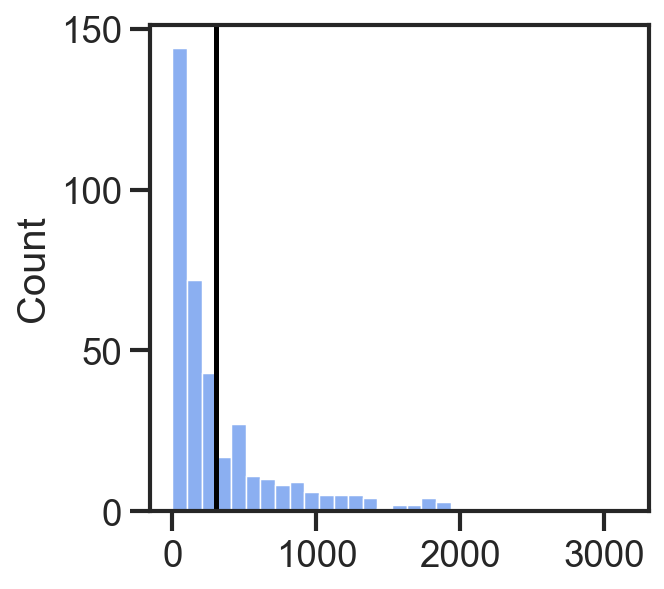

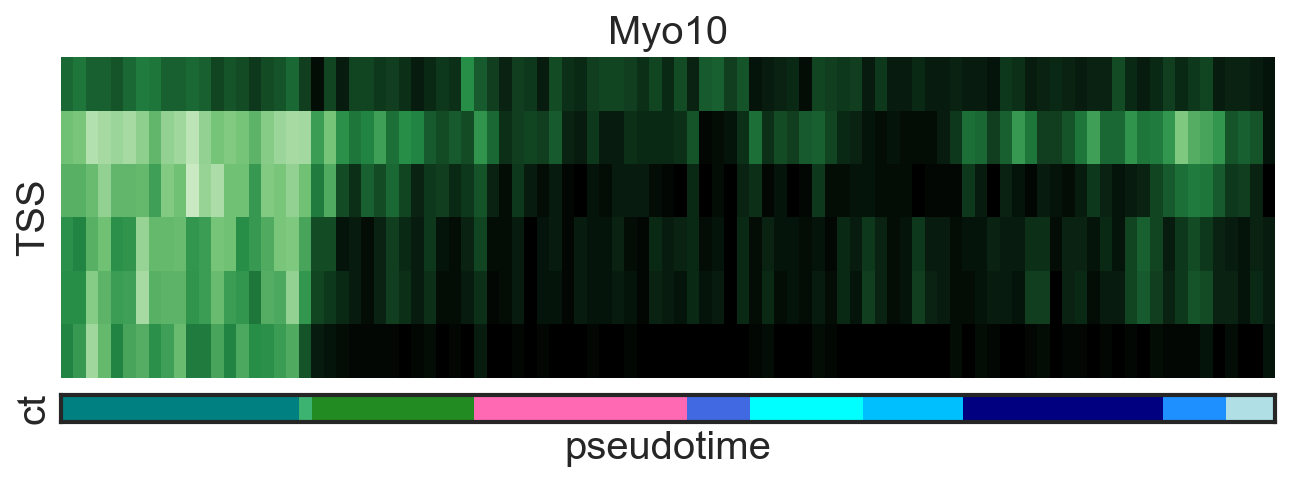

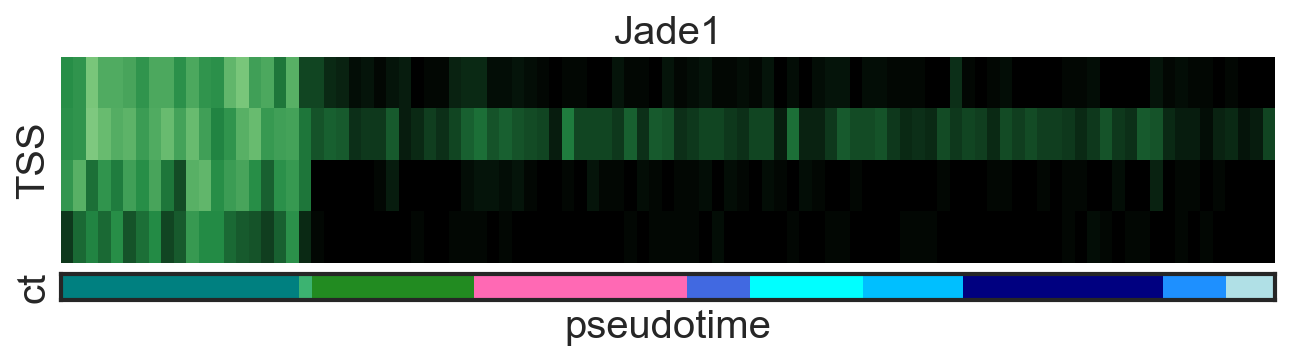

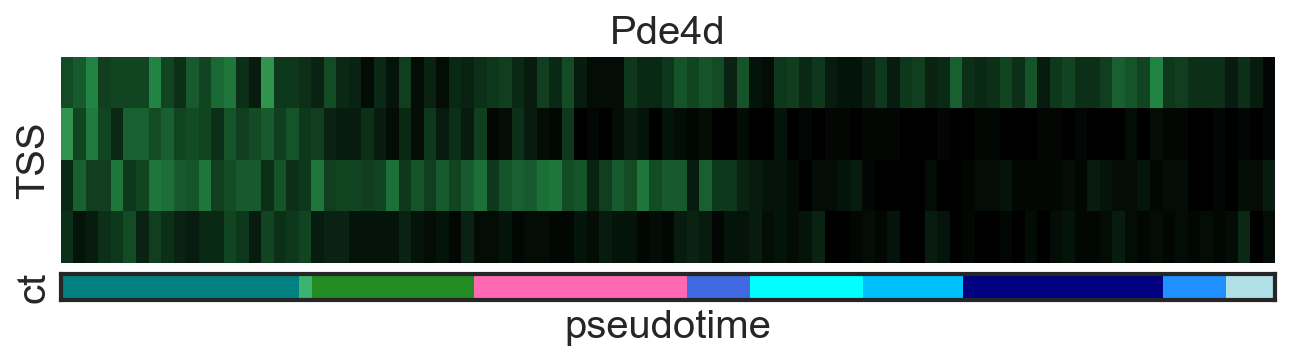

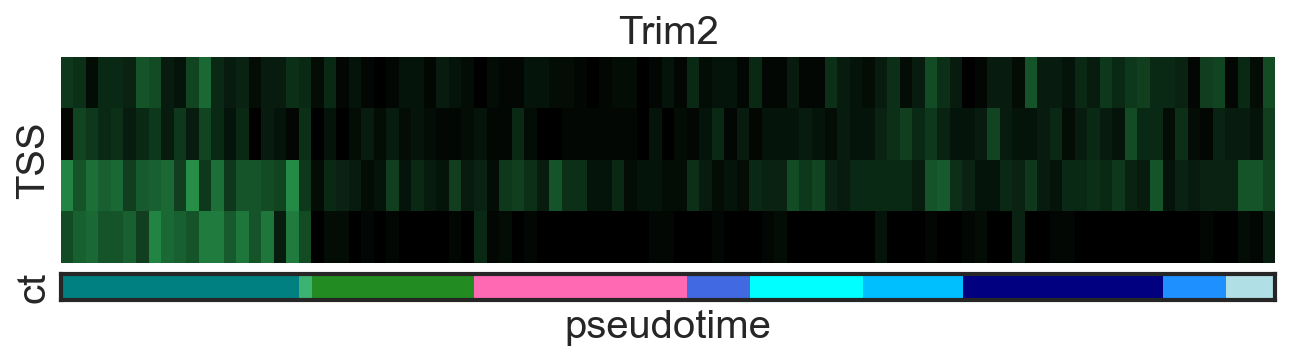

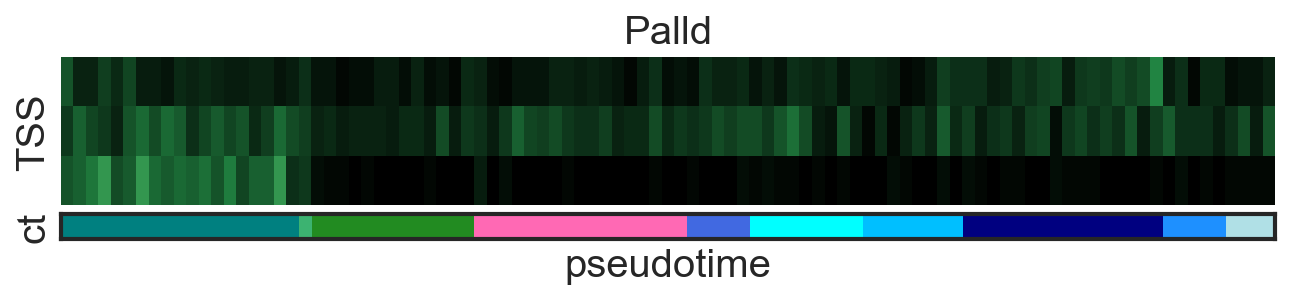

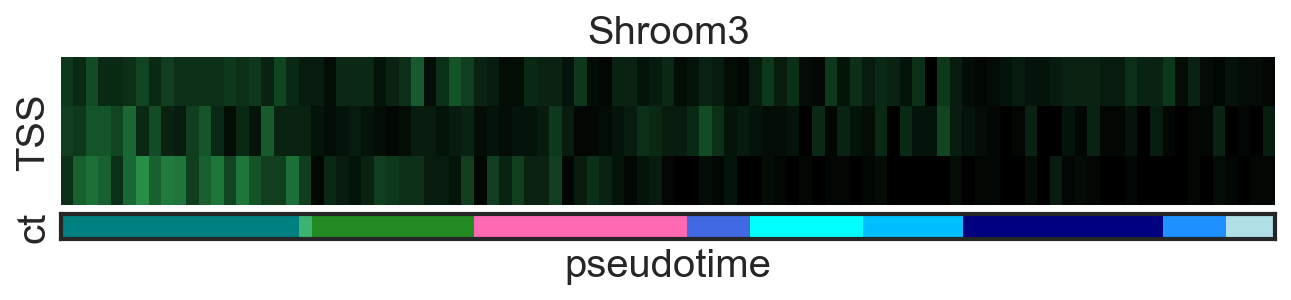

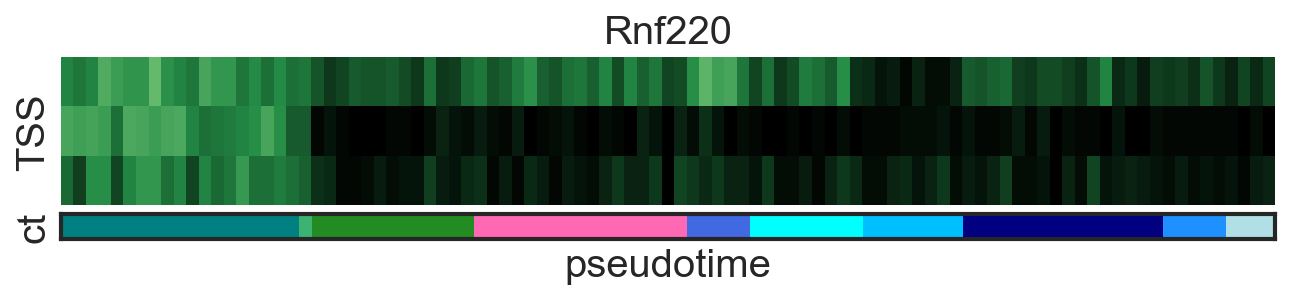

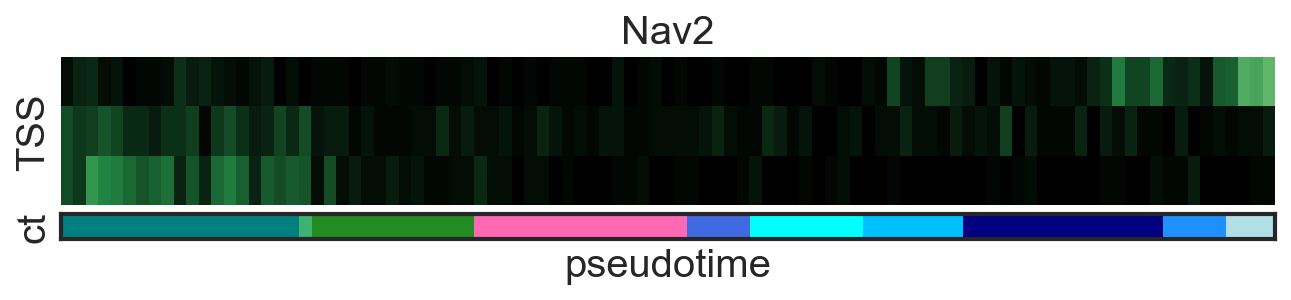

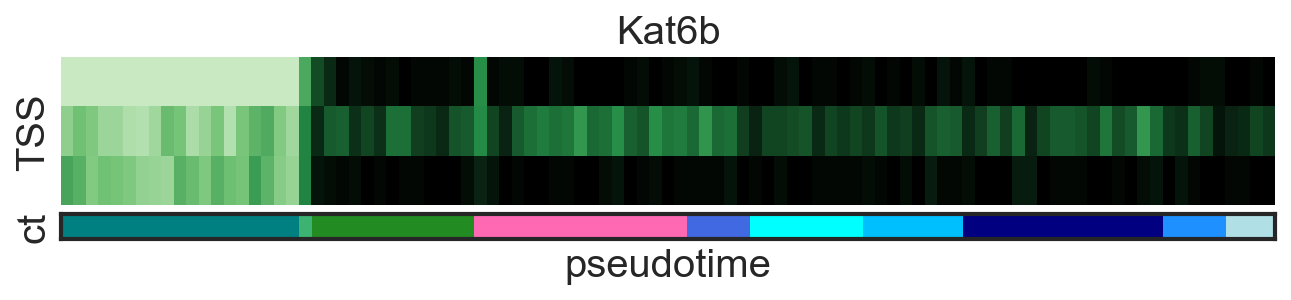

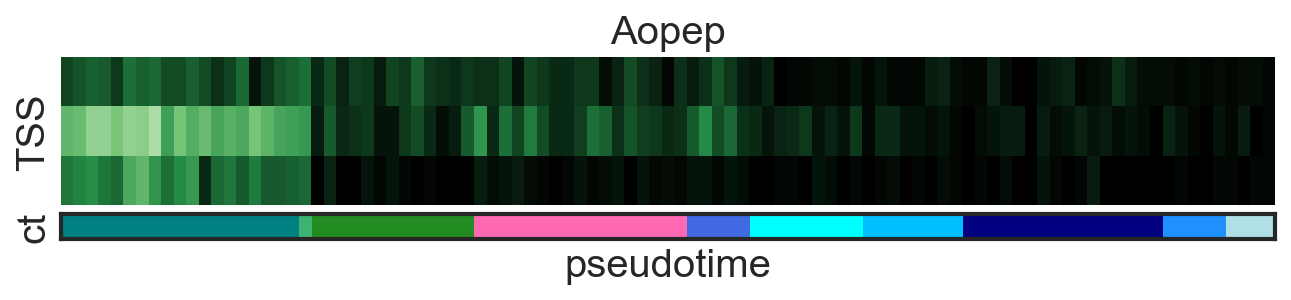

In [450]:
makeHeatmap(df_k4, 'Ectoderm', vmax = 0.6)

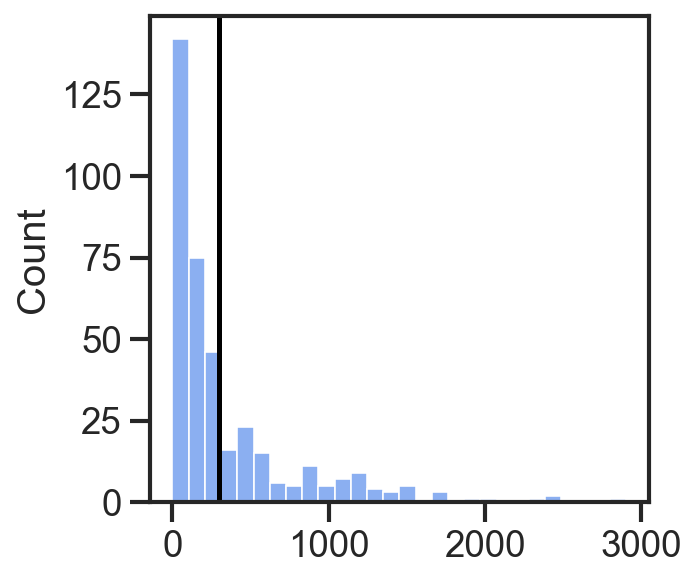

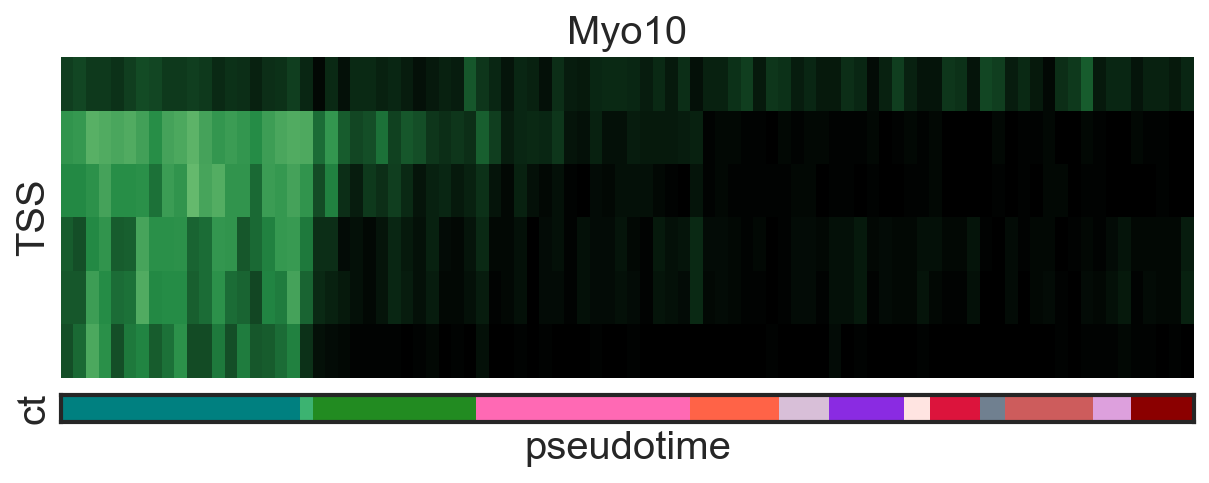

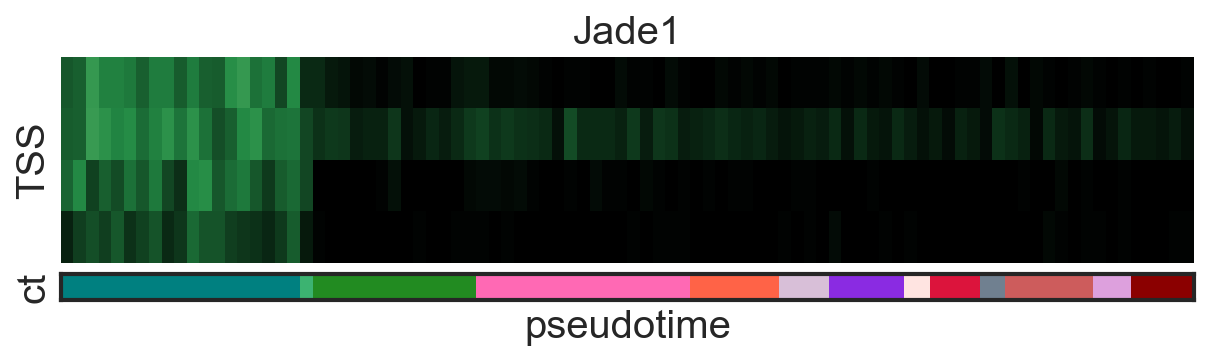

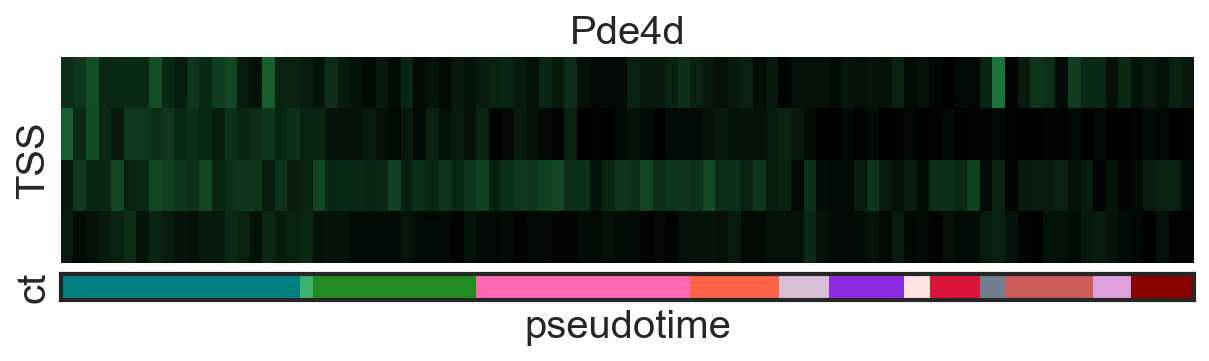

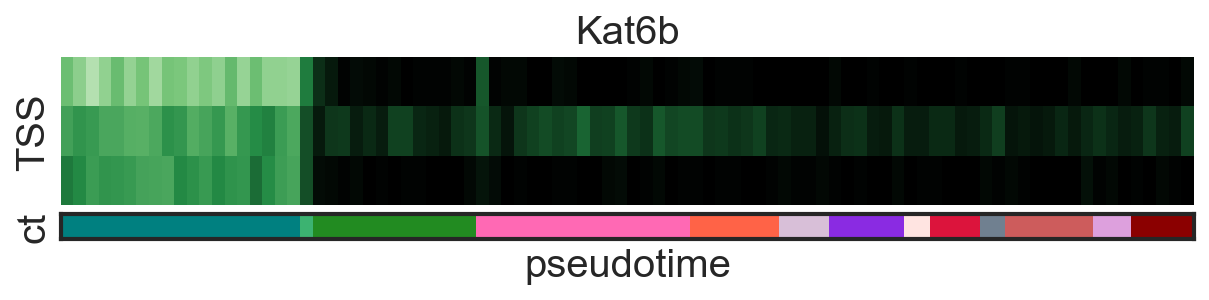

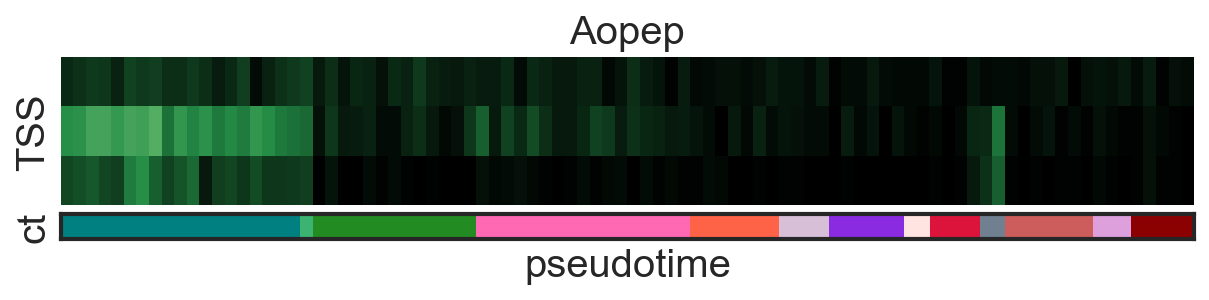

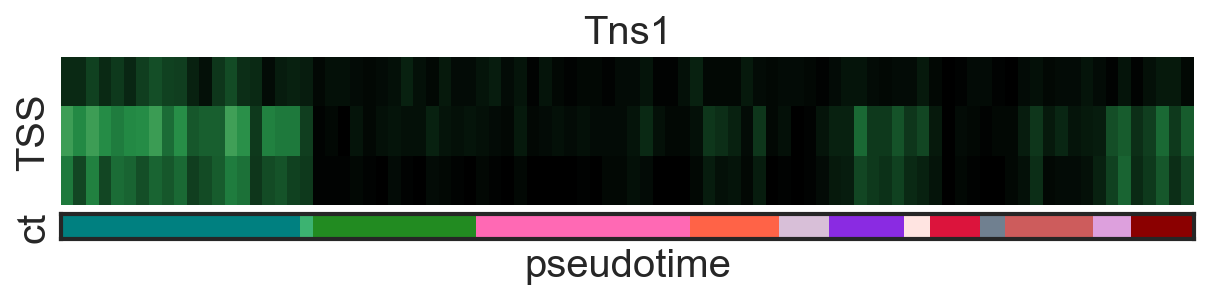

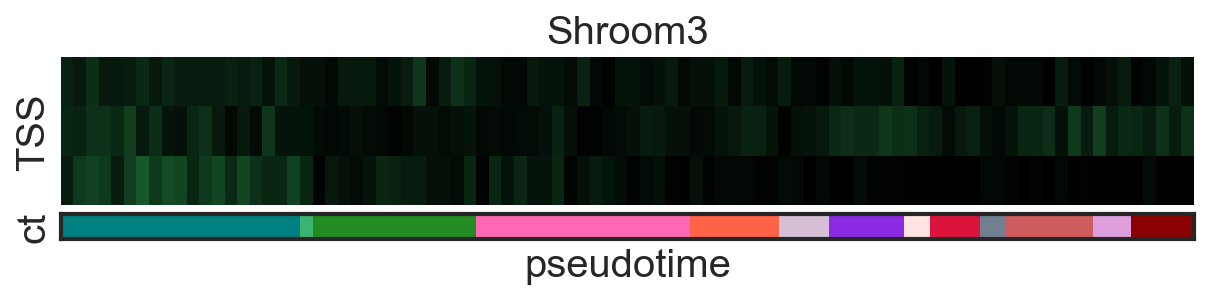

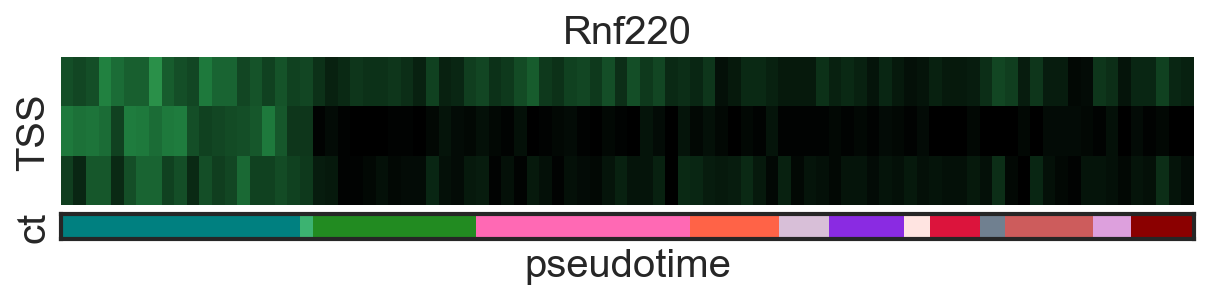

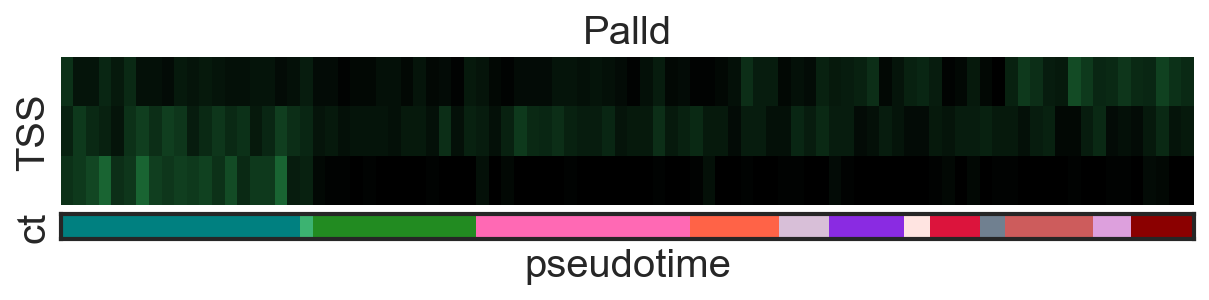

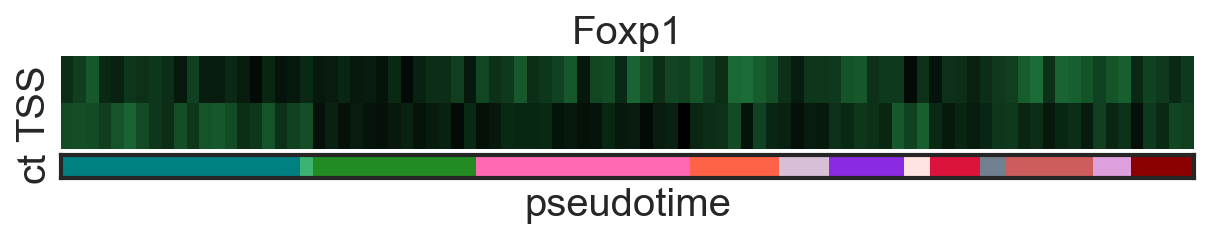

In [451]:
makeHeatmap(df_k4, 'Mesoderm')

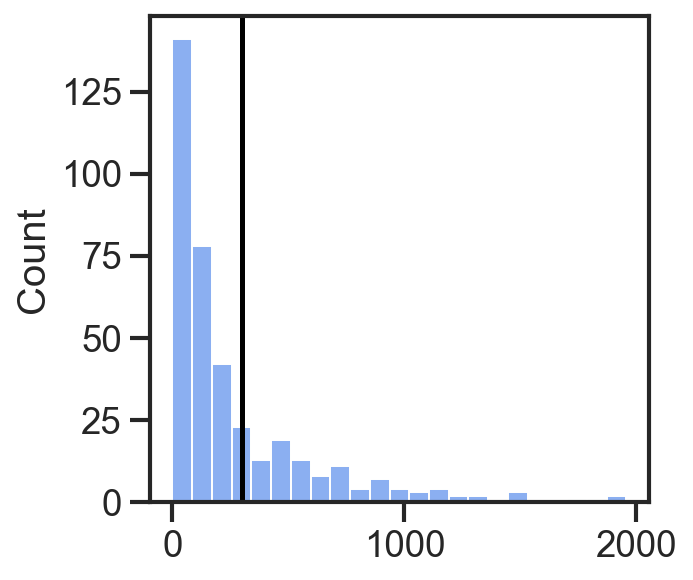

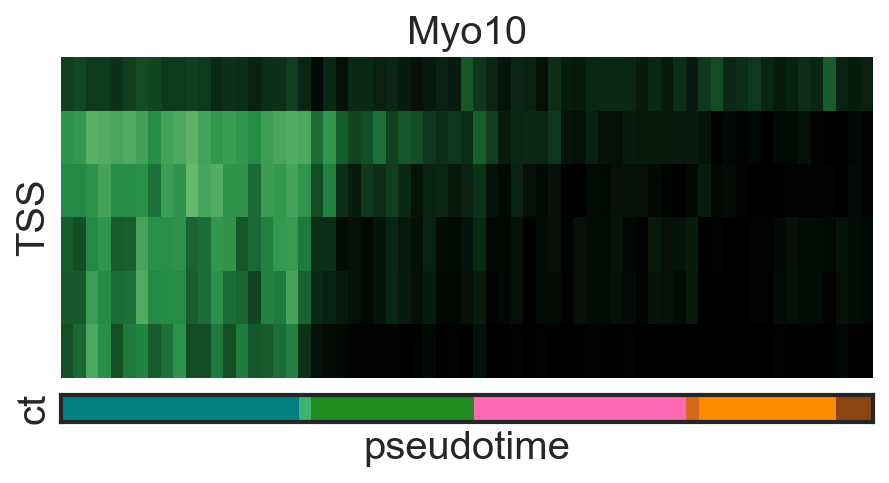

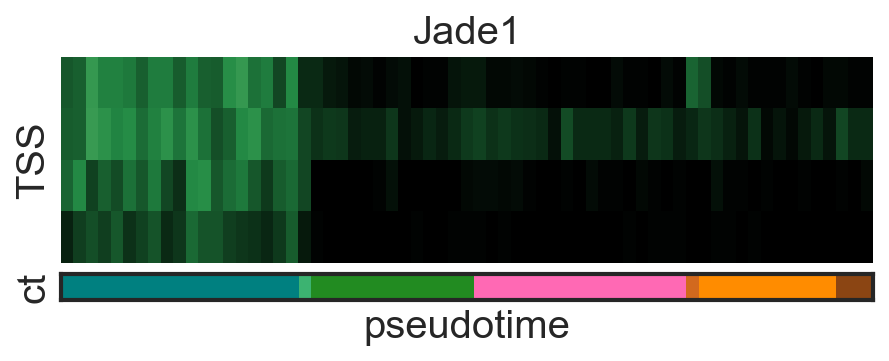

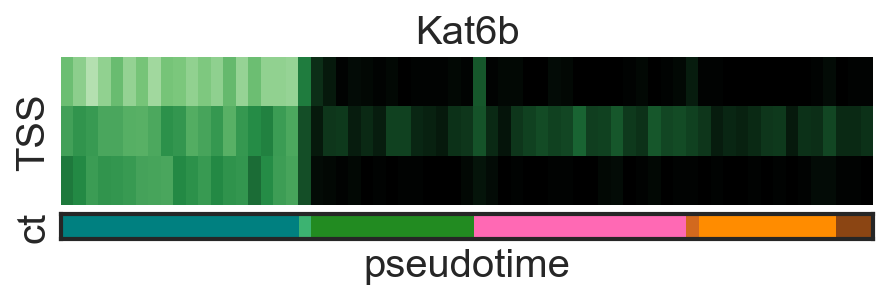

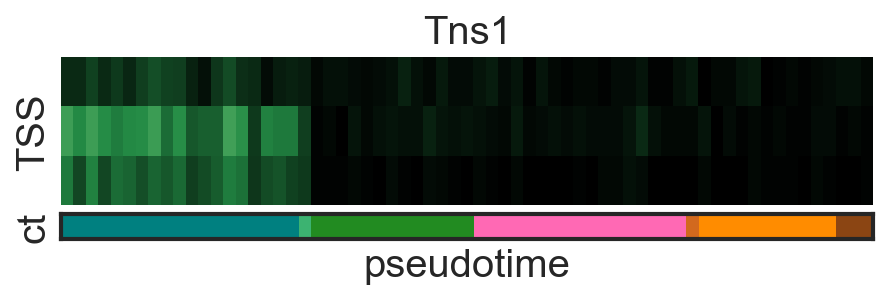

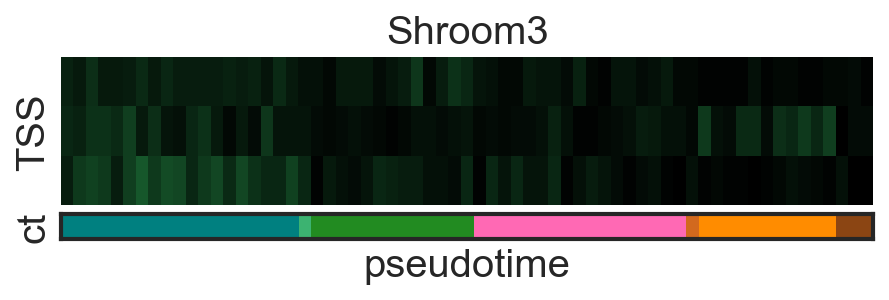

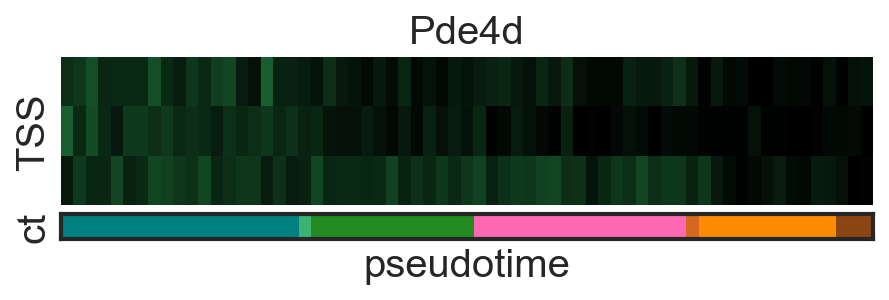

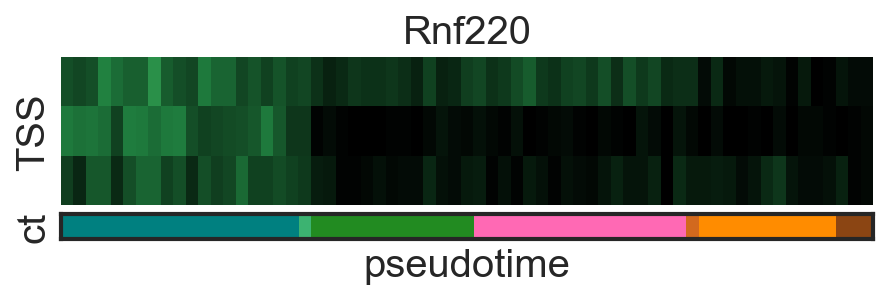

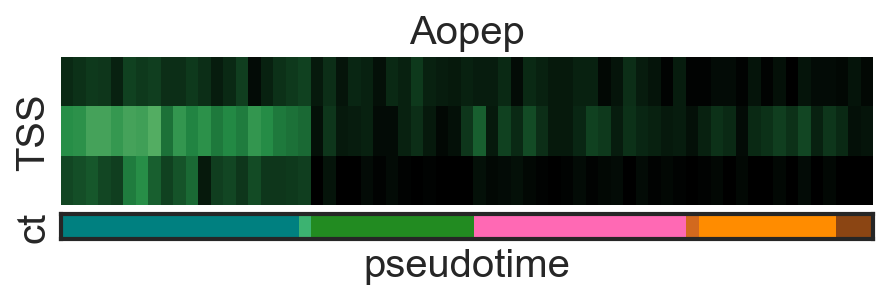

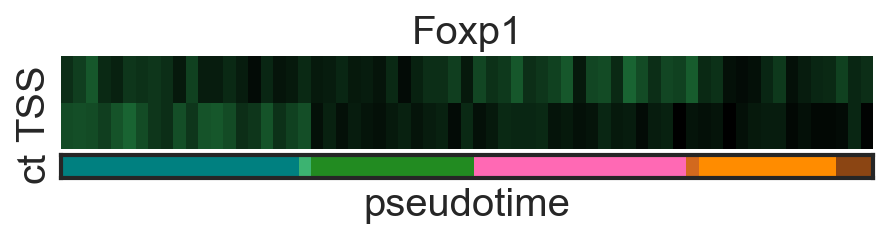

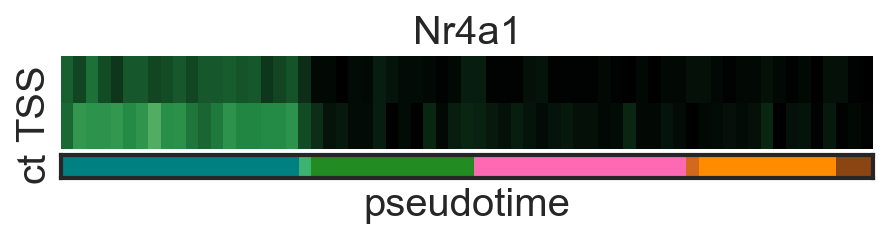

In [452]:
makeHeatmap(df_k4, 'Endoderm')

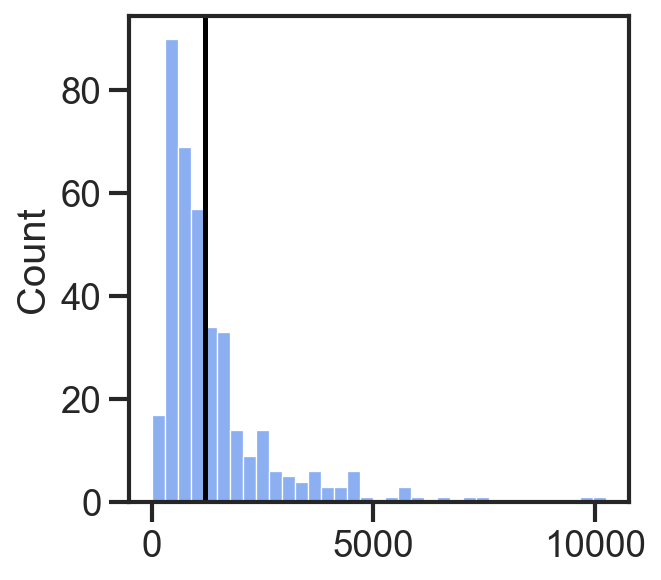

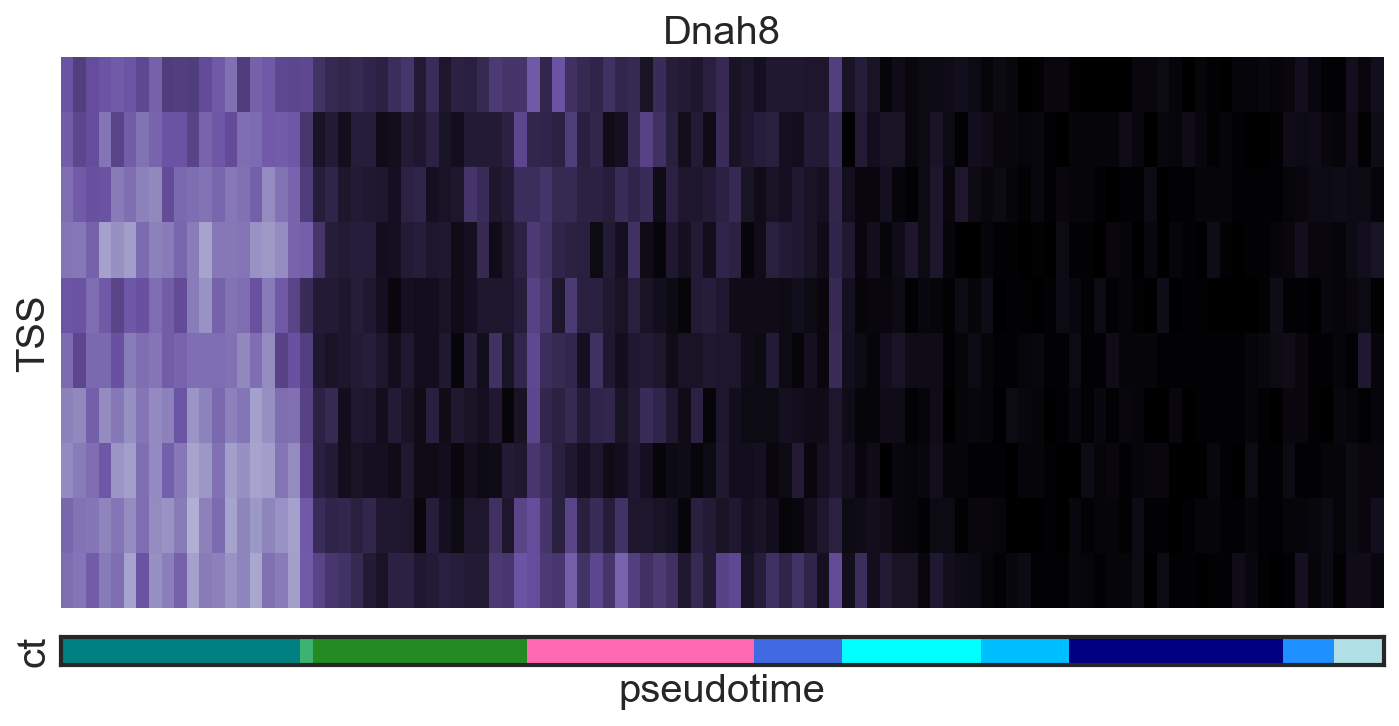

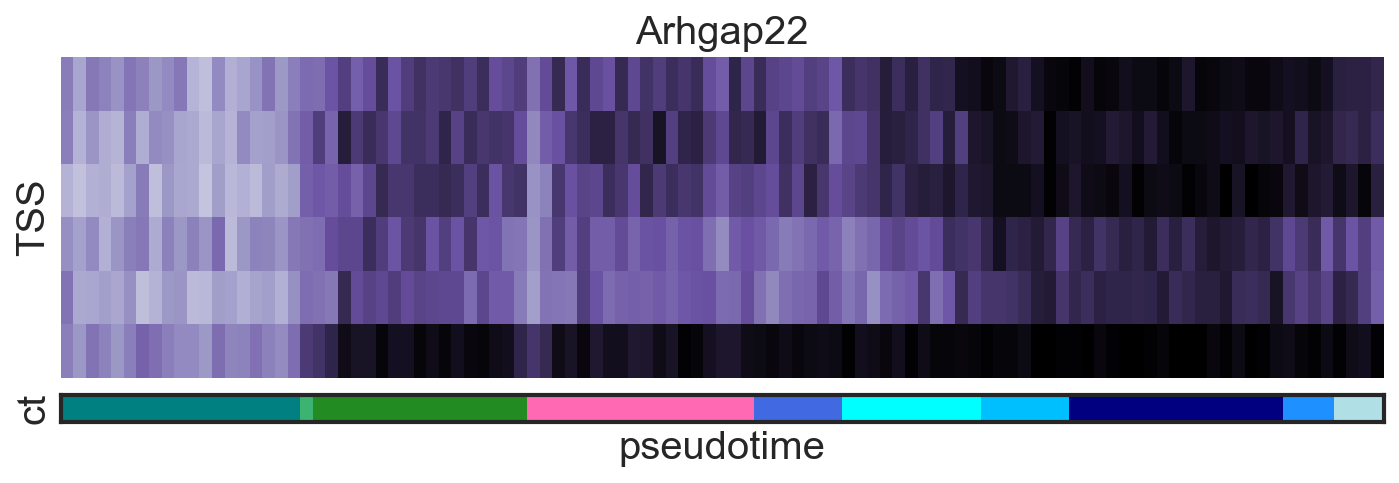

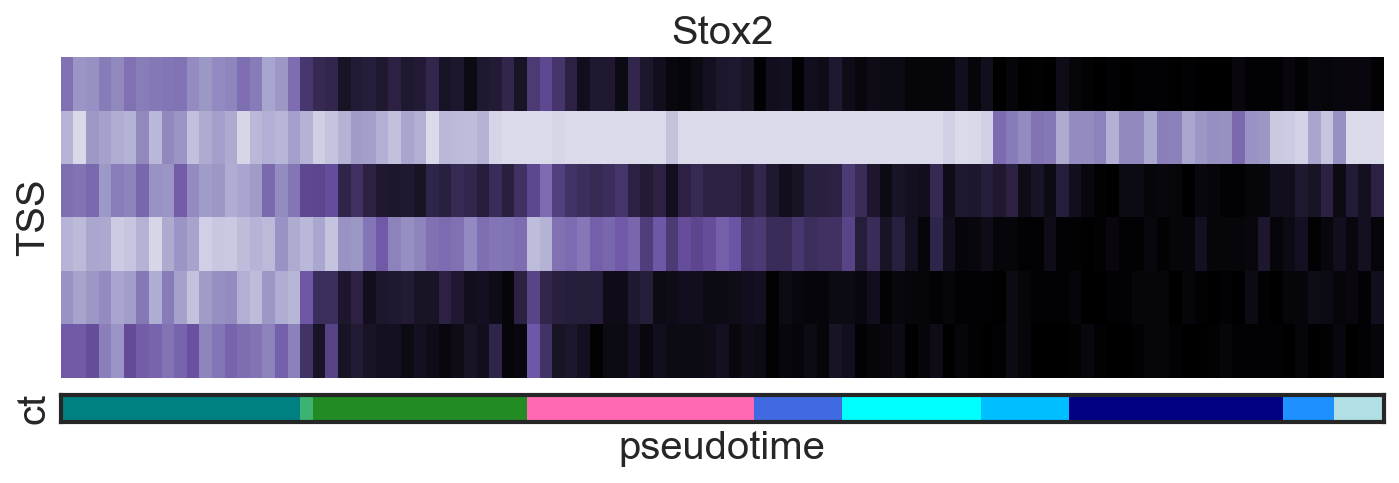

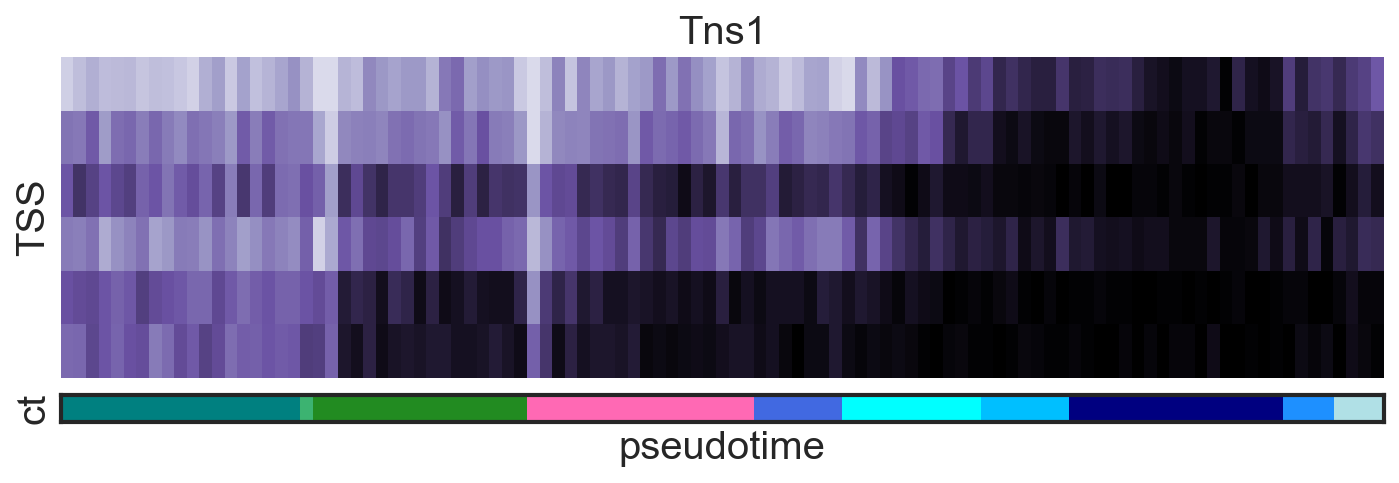

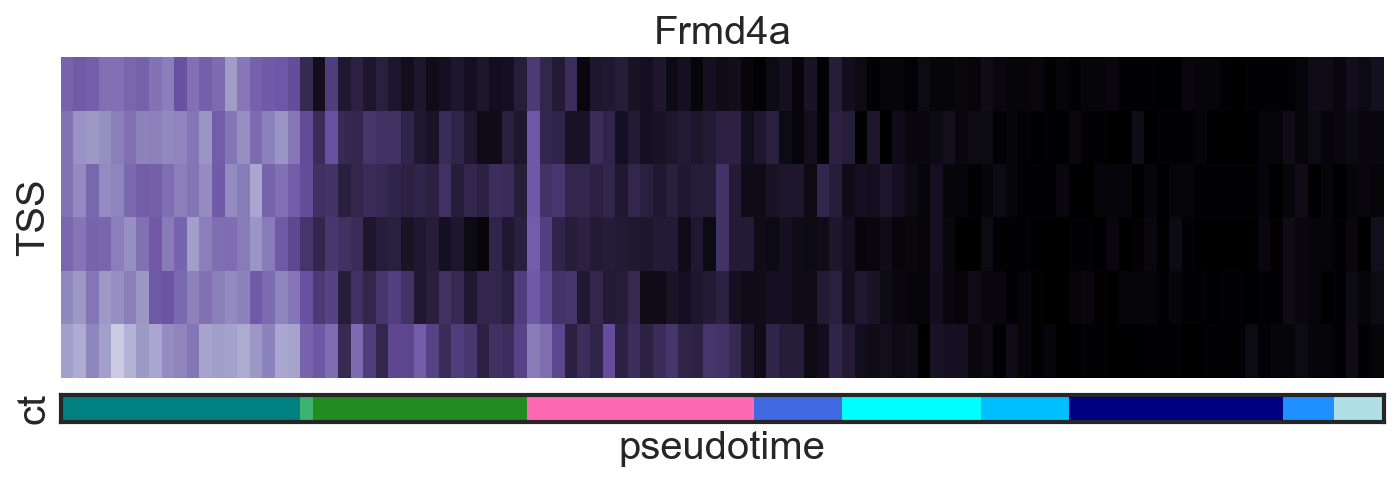

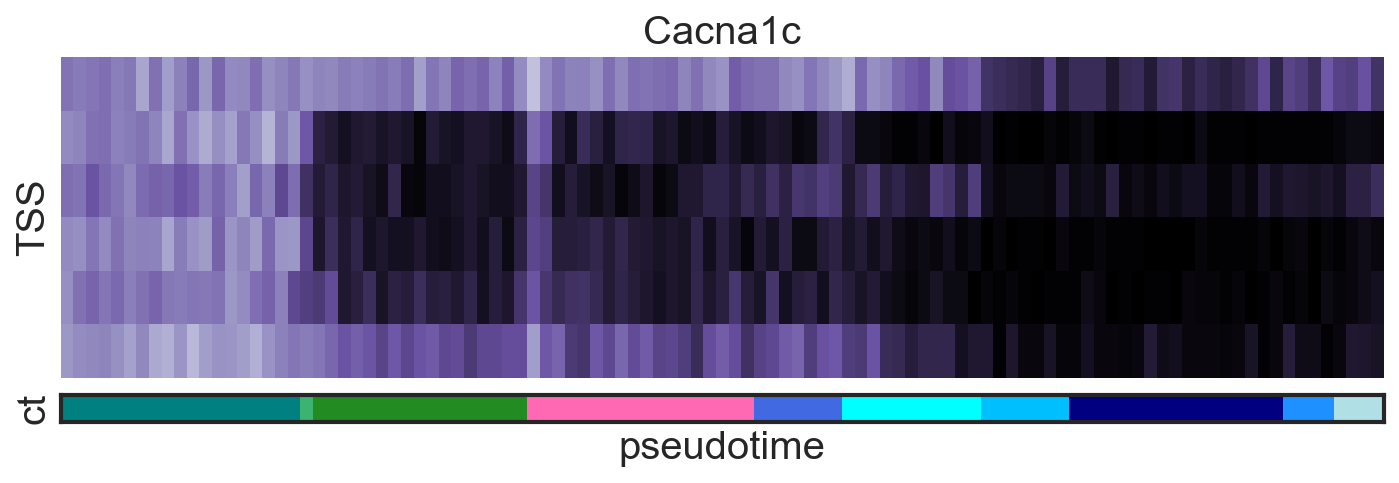

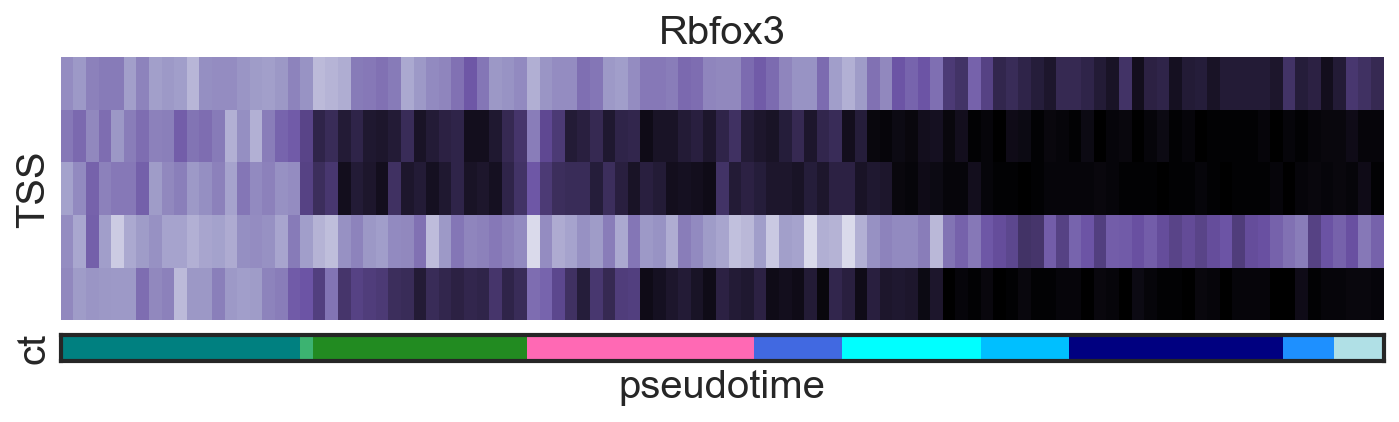

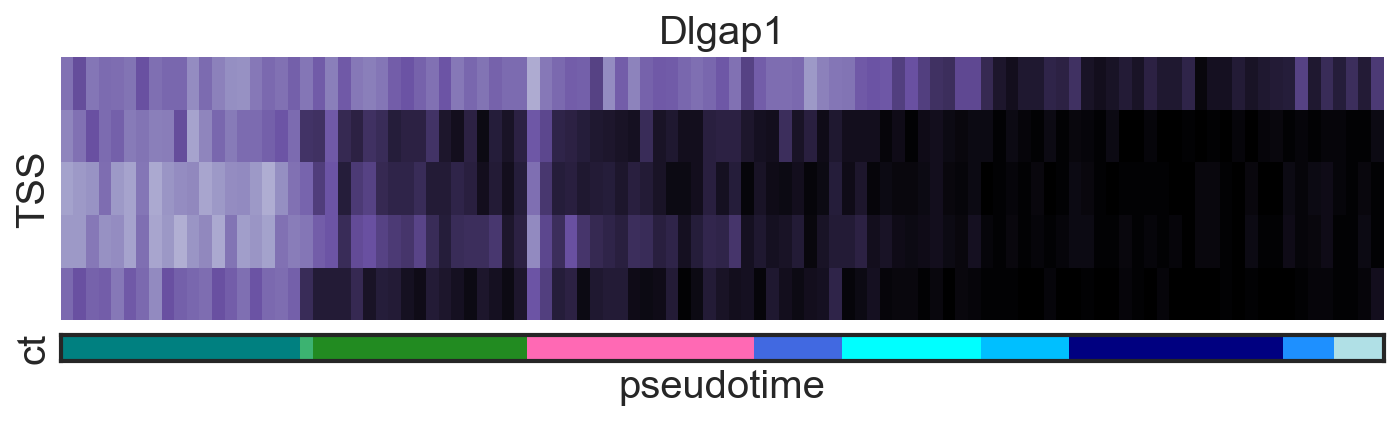

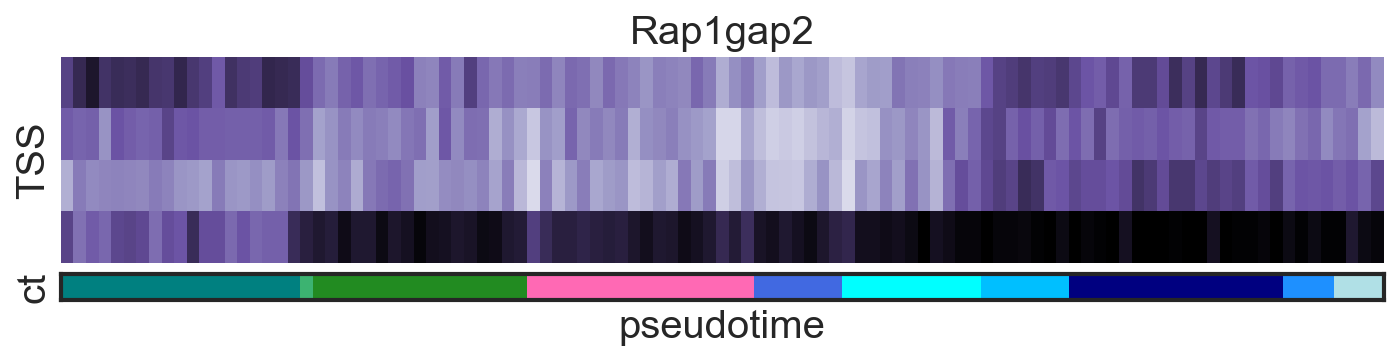

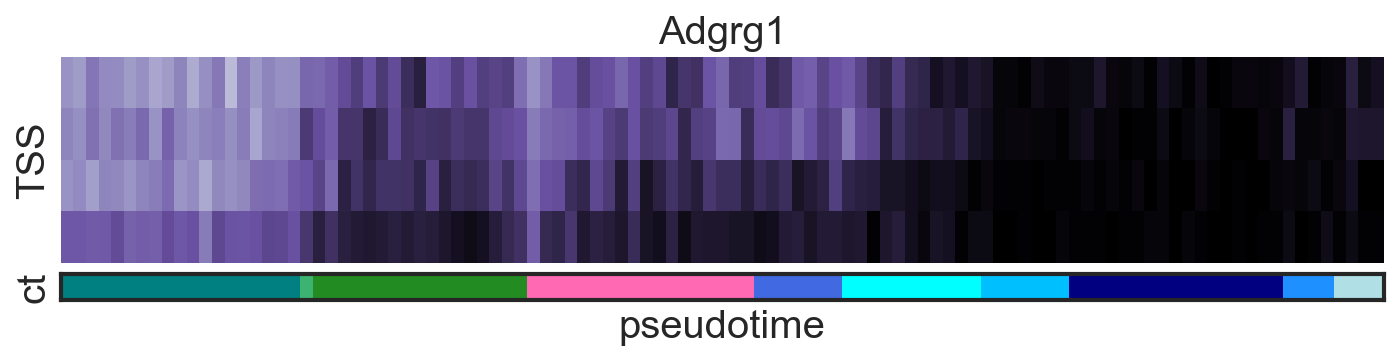

In [453]:
makeHeatmap(df_k27, 'Ectoderm', palette = purples_r, threshold = 1200, vmax = 1)

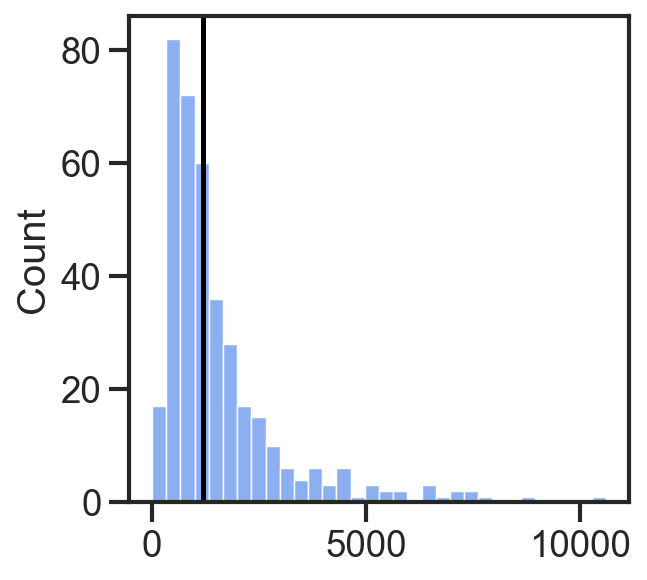

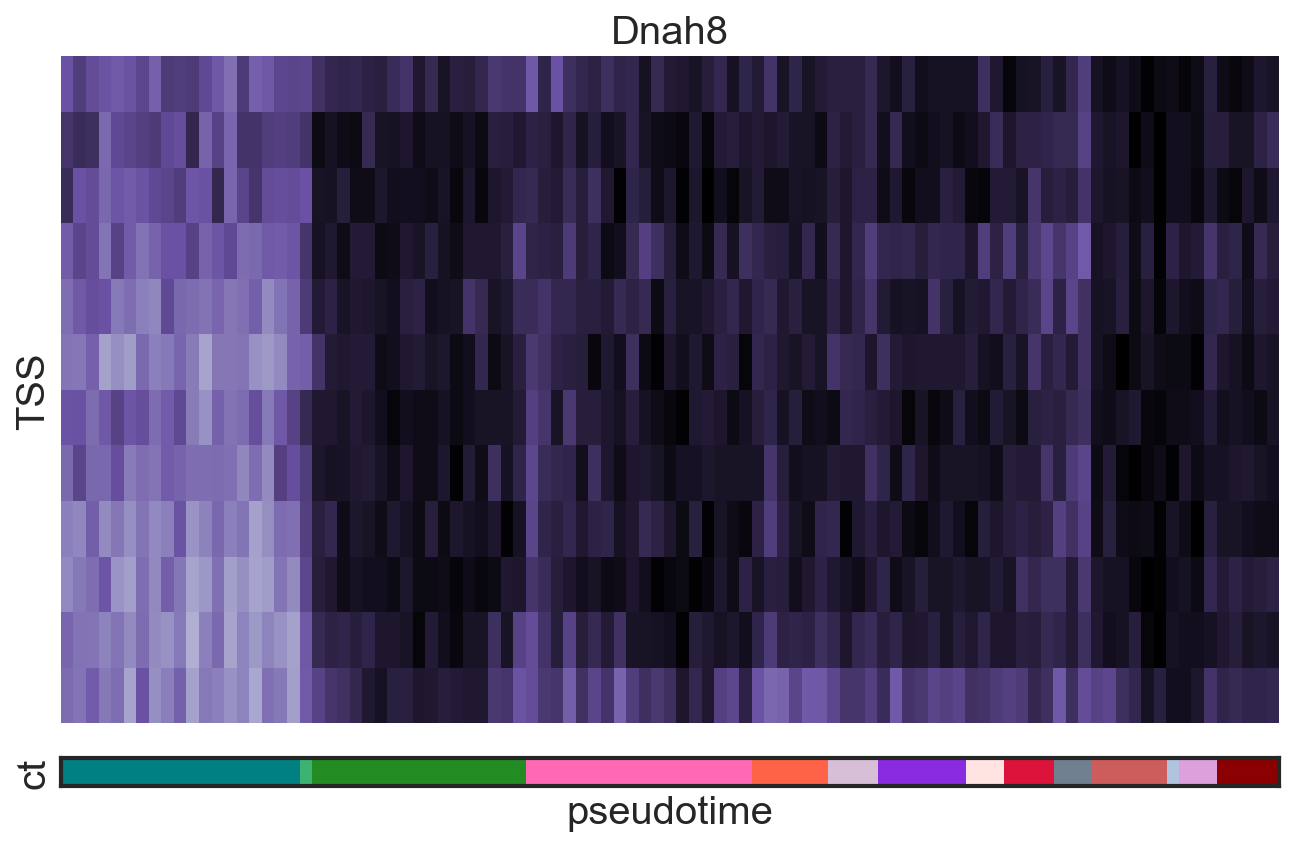

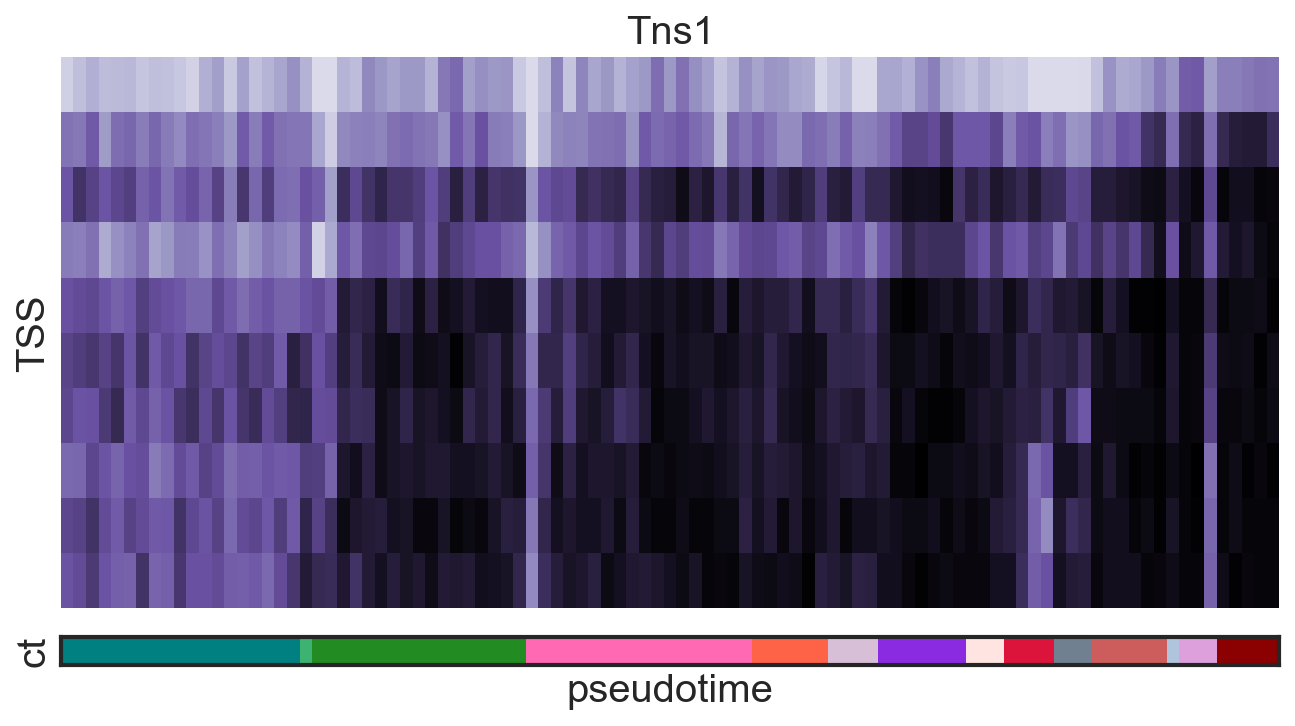

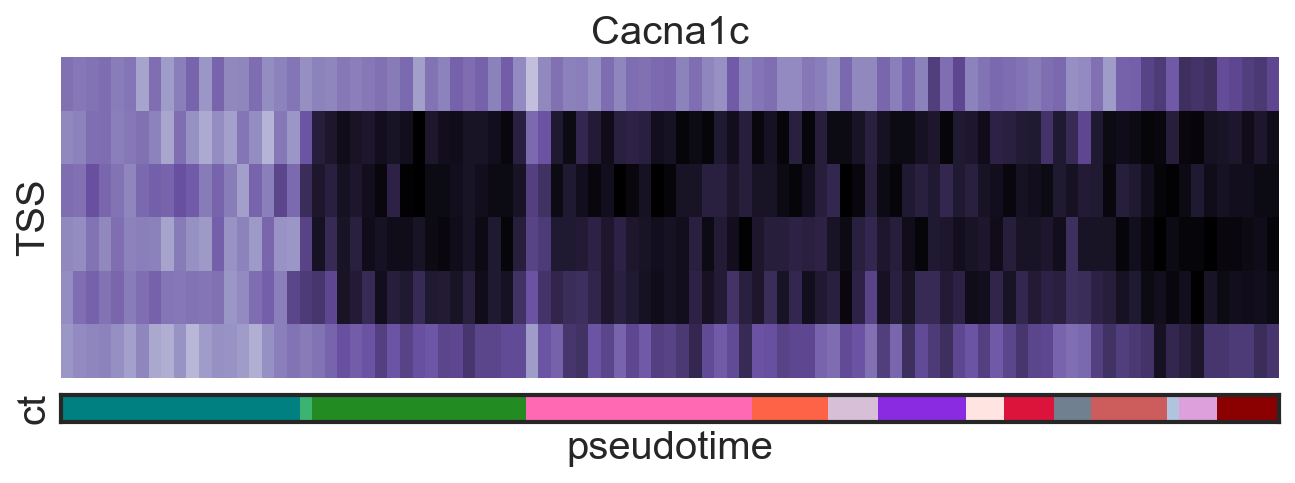

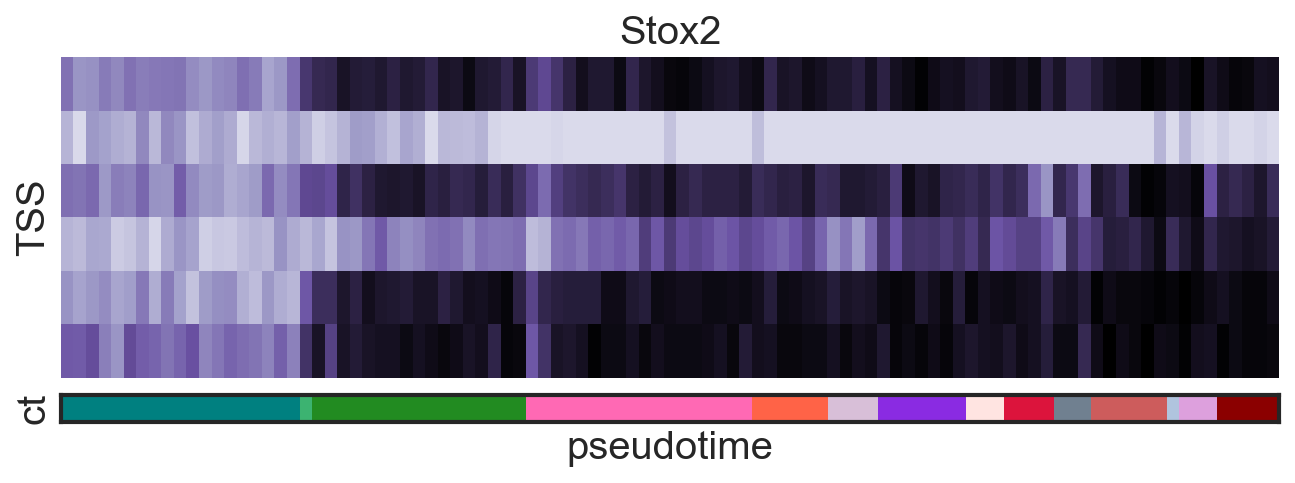

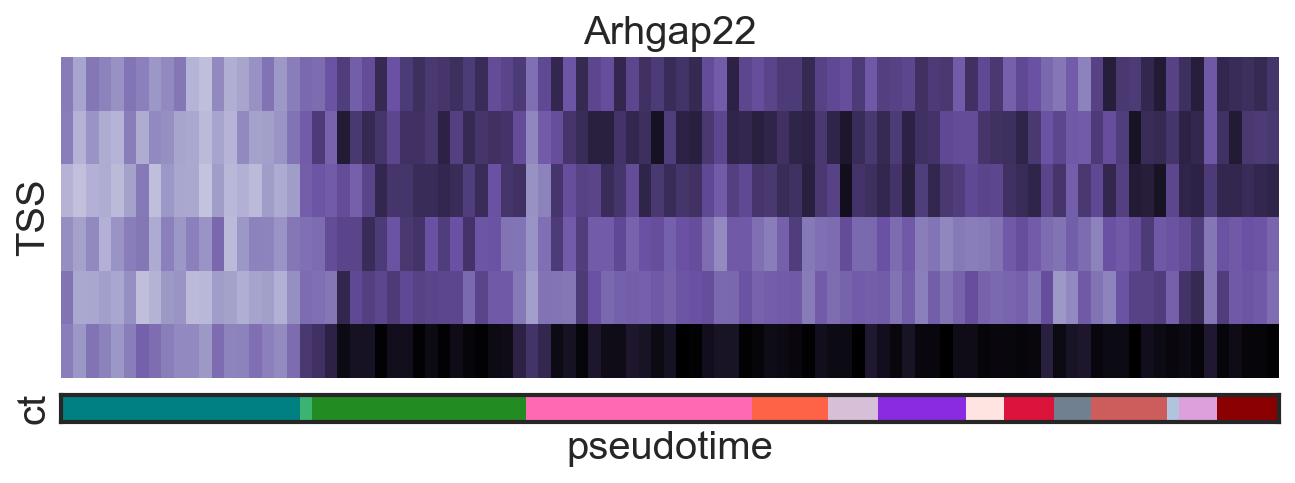

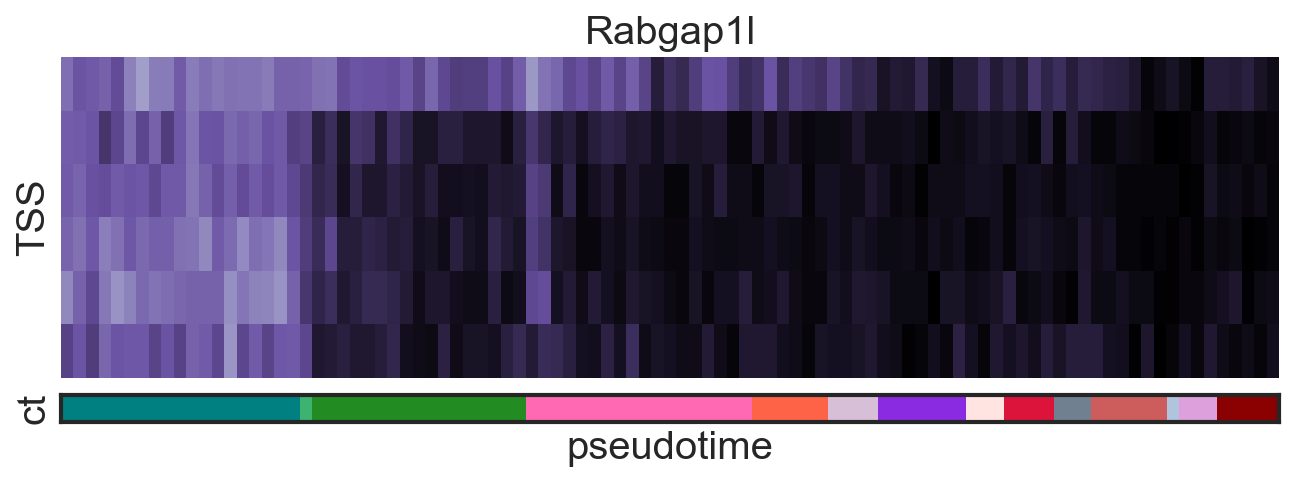

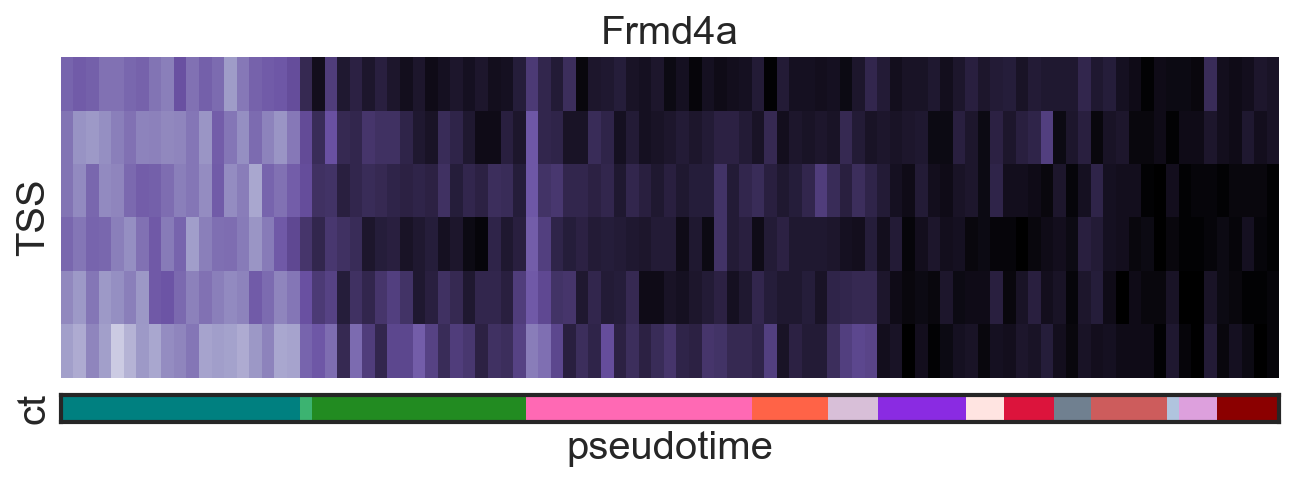

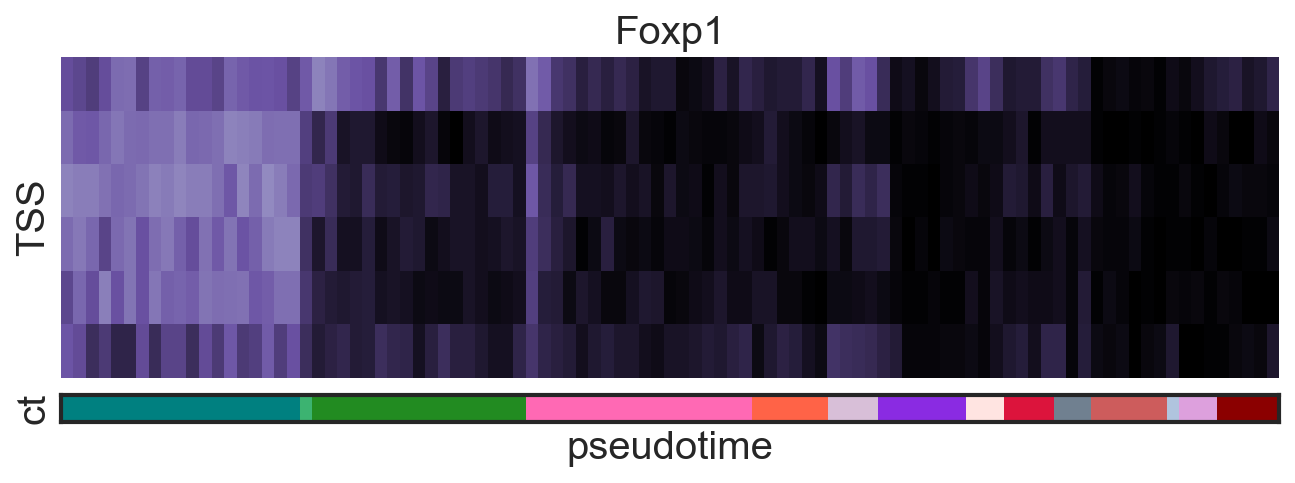

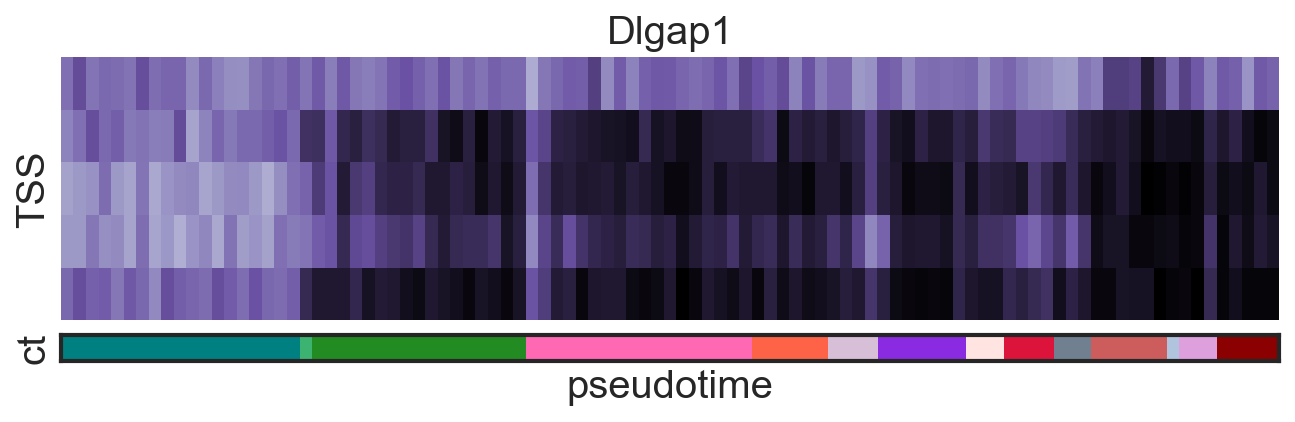

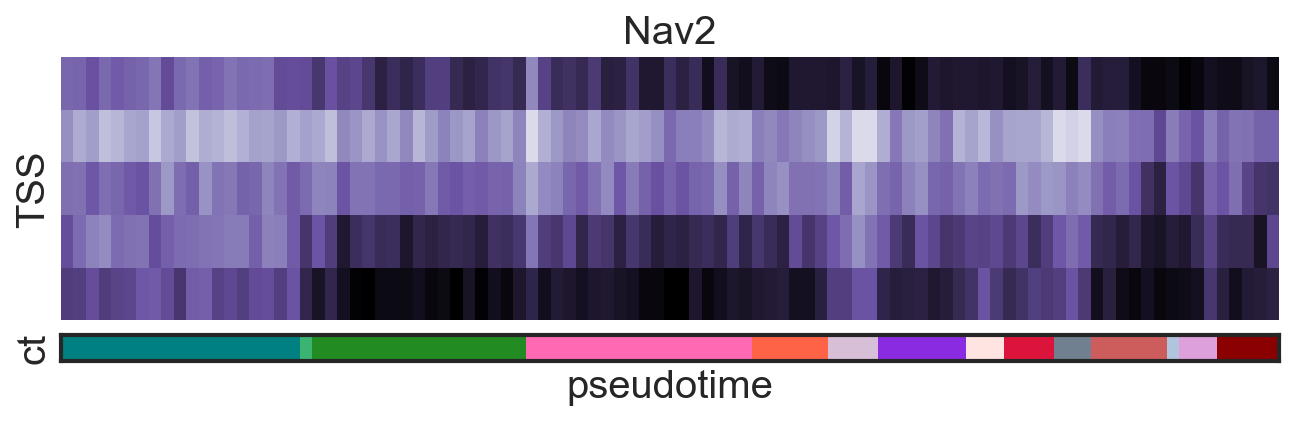

In [454]:
makeHeatmap(df_k27, 'Mesoderm', palette = purples_r, threshold = 1200, vmax = 1)

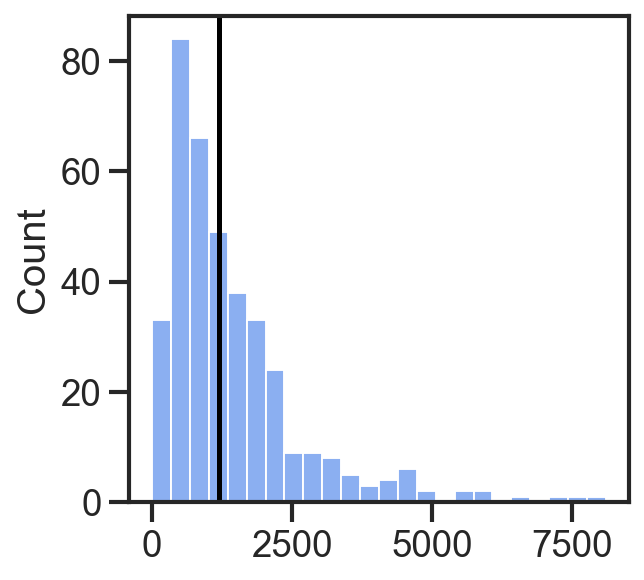

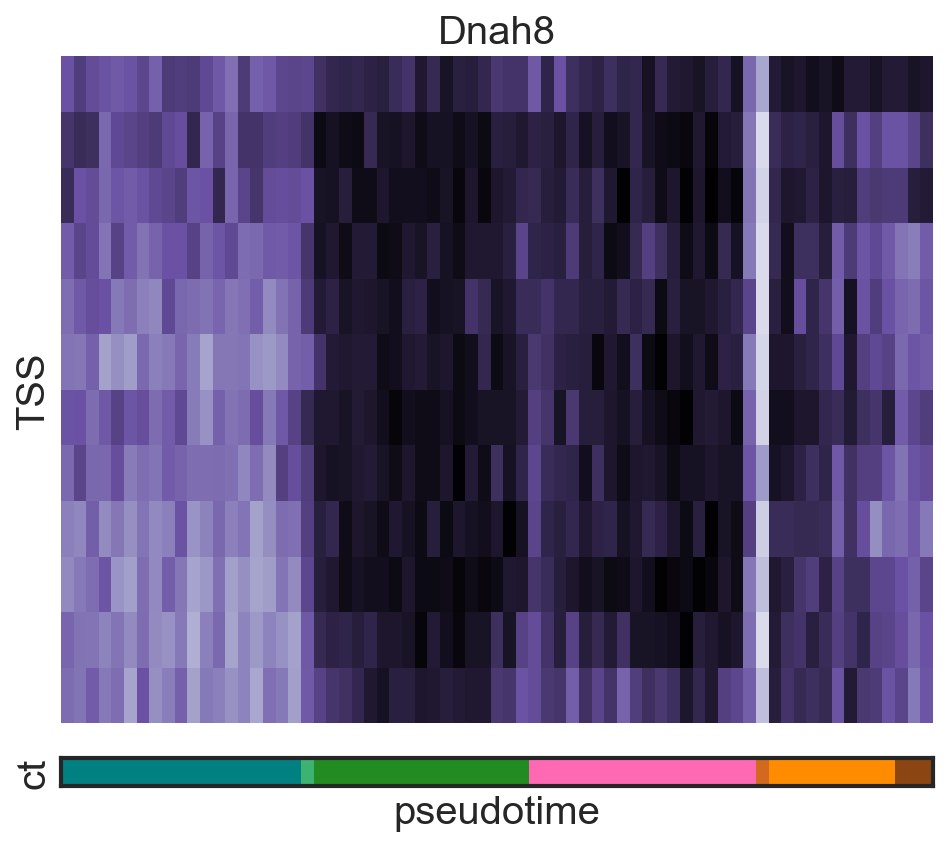

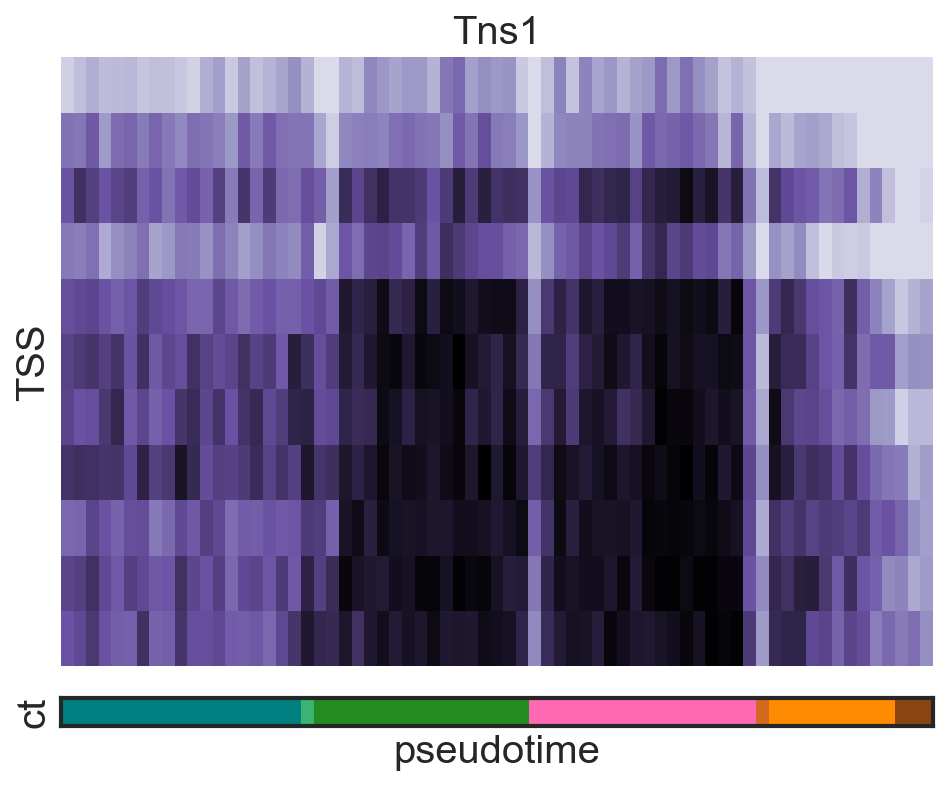

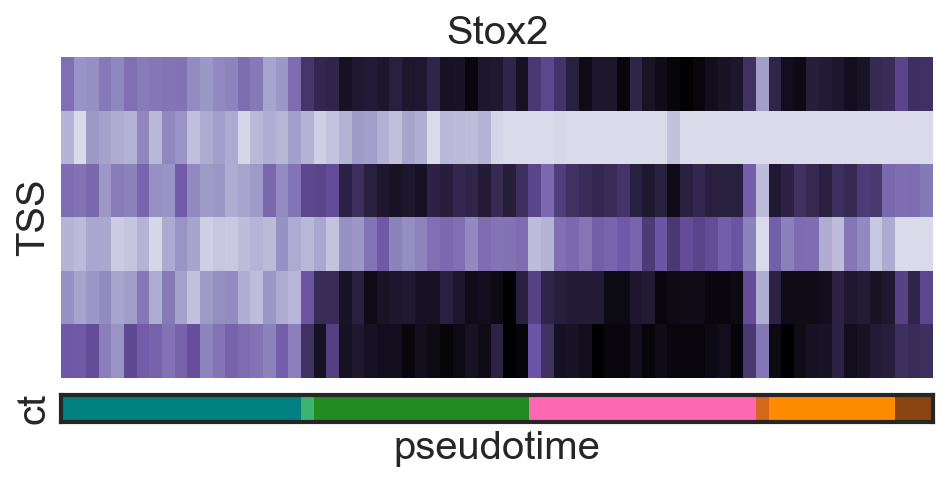

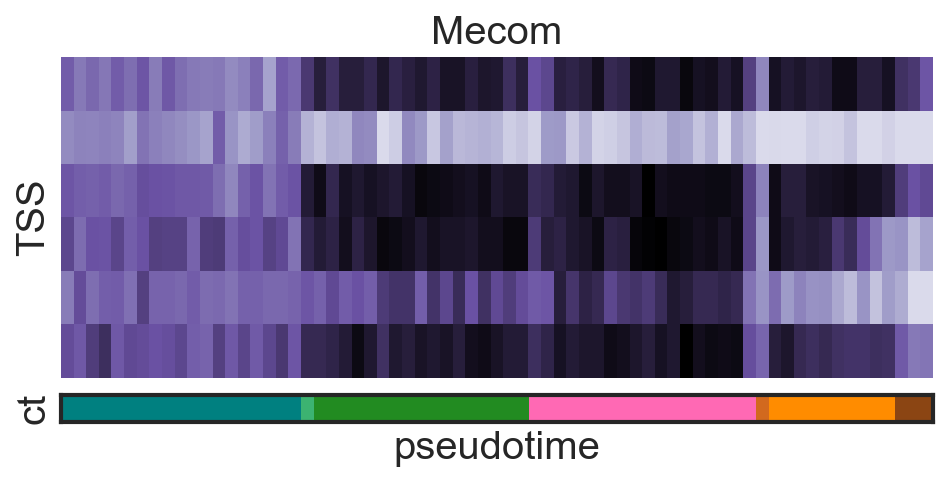

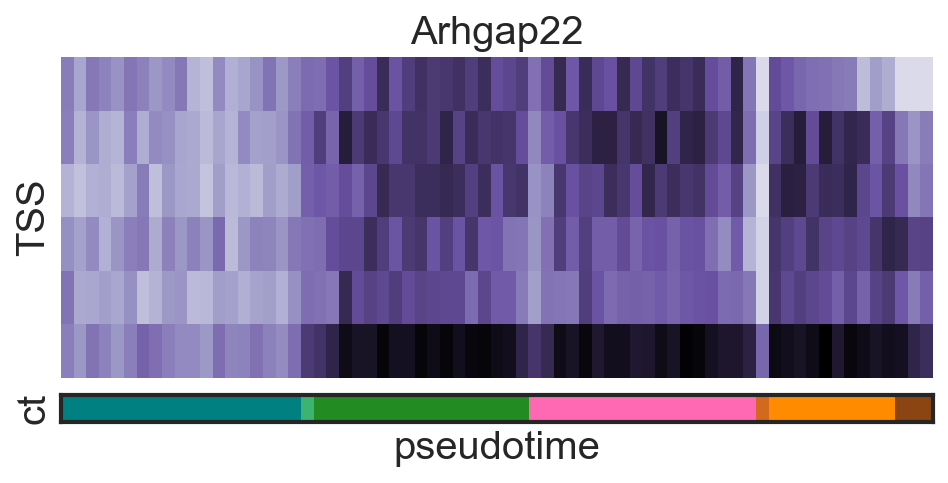

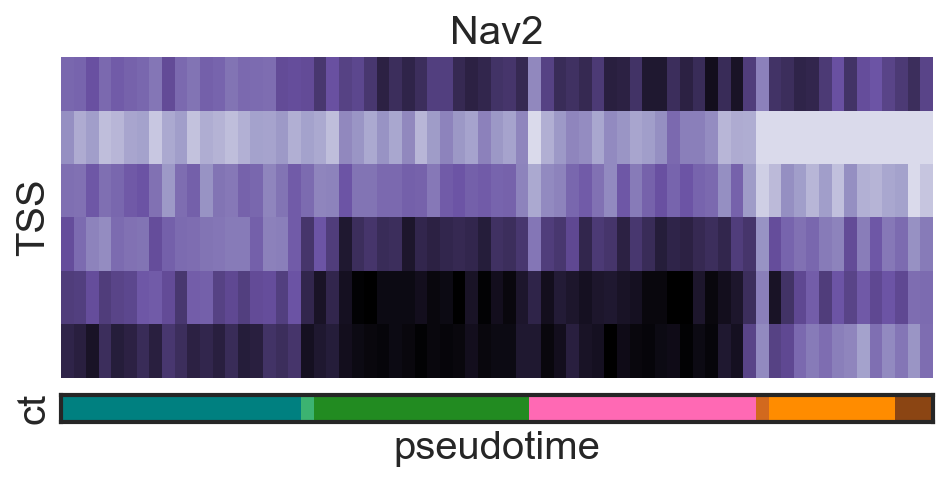

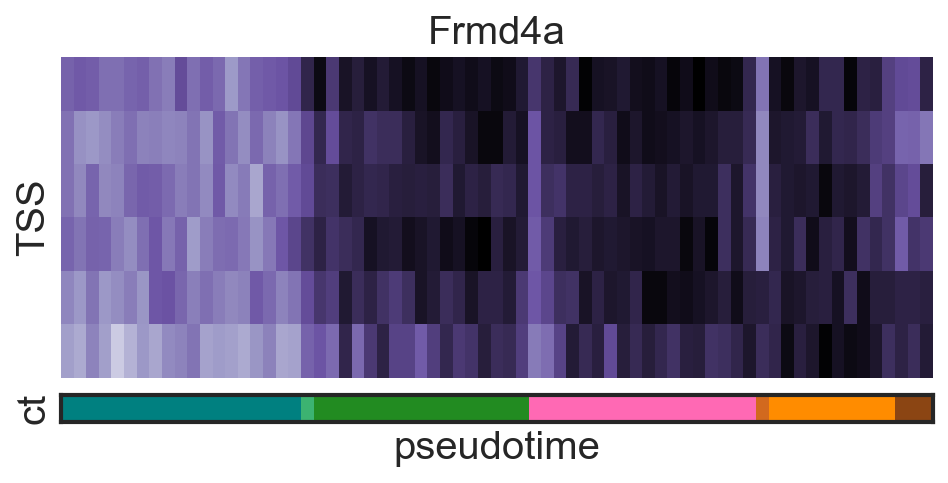

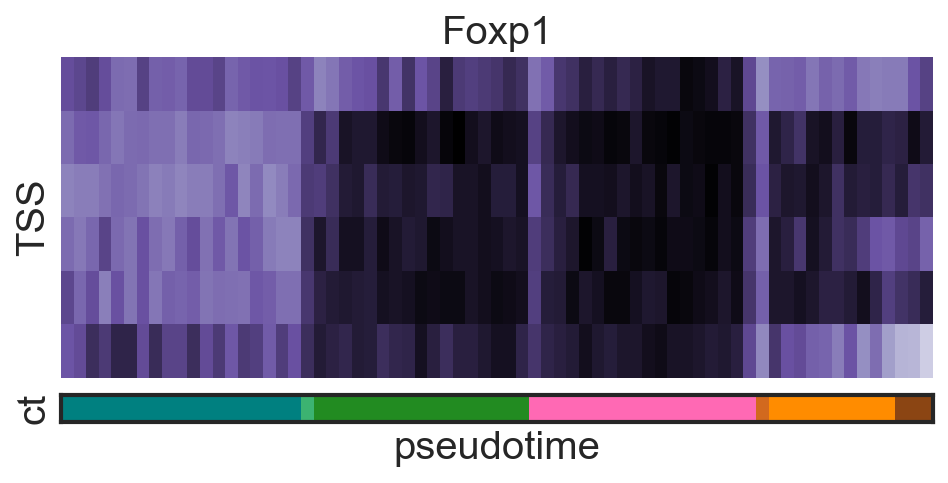

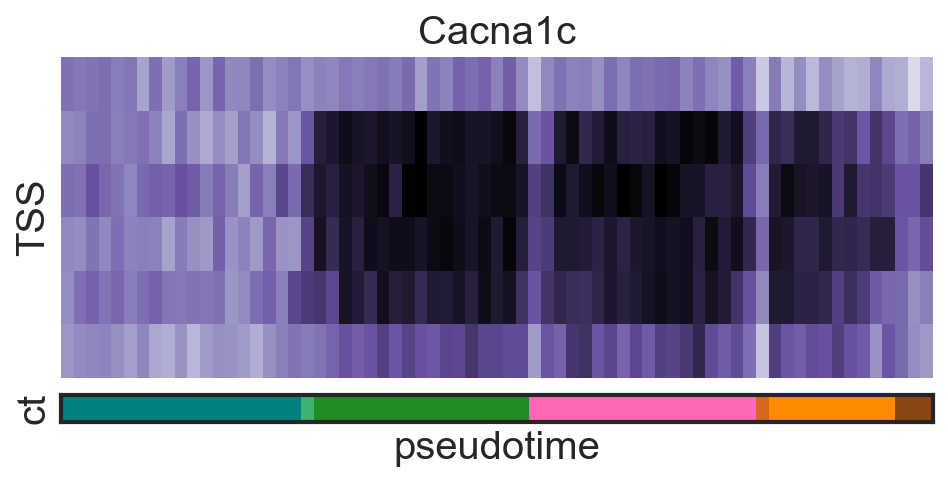

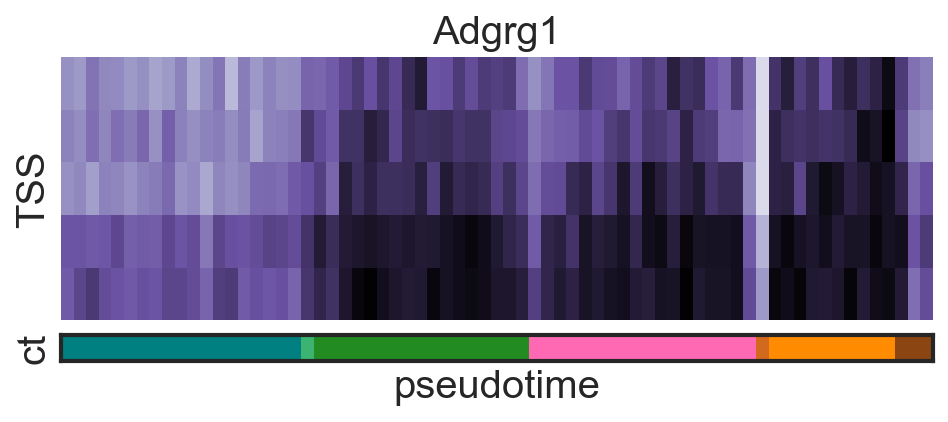

In [455]:
makeHeatmap(df_k27, 'Endoderm', palette = purples_r, threshold = 1200, vmax = 1)

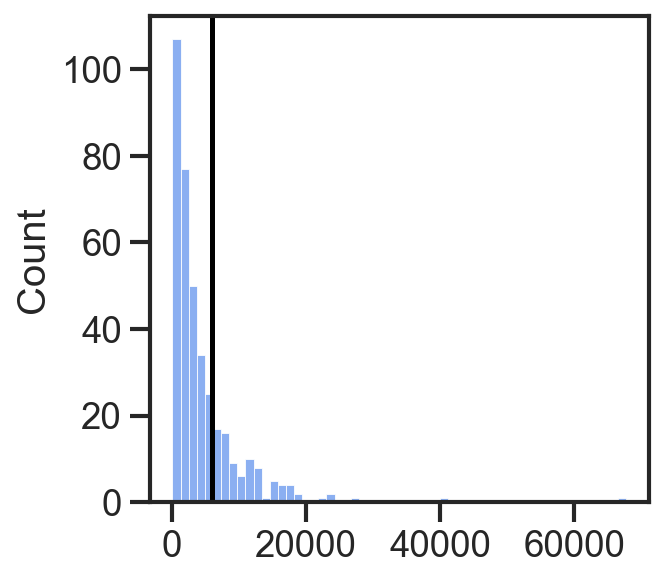

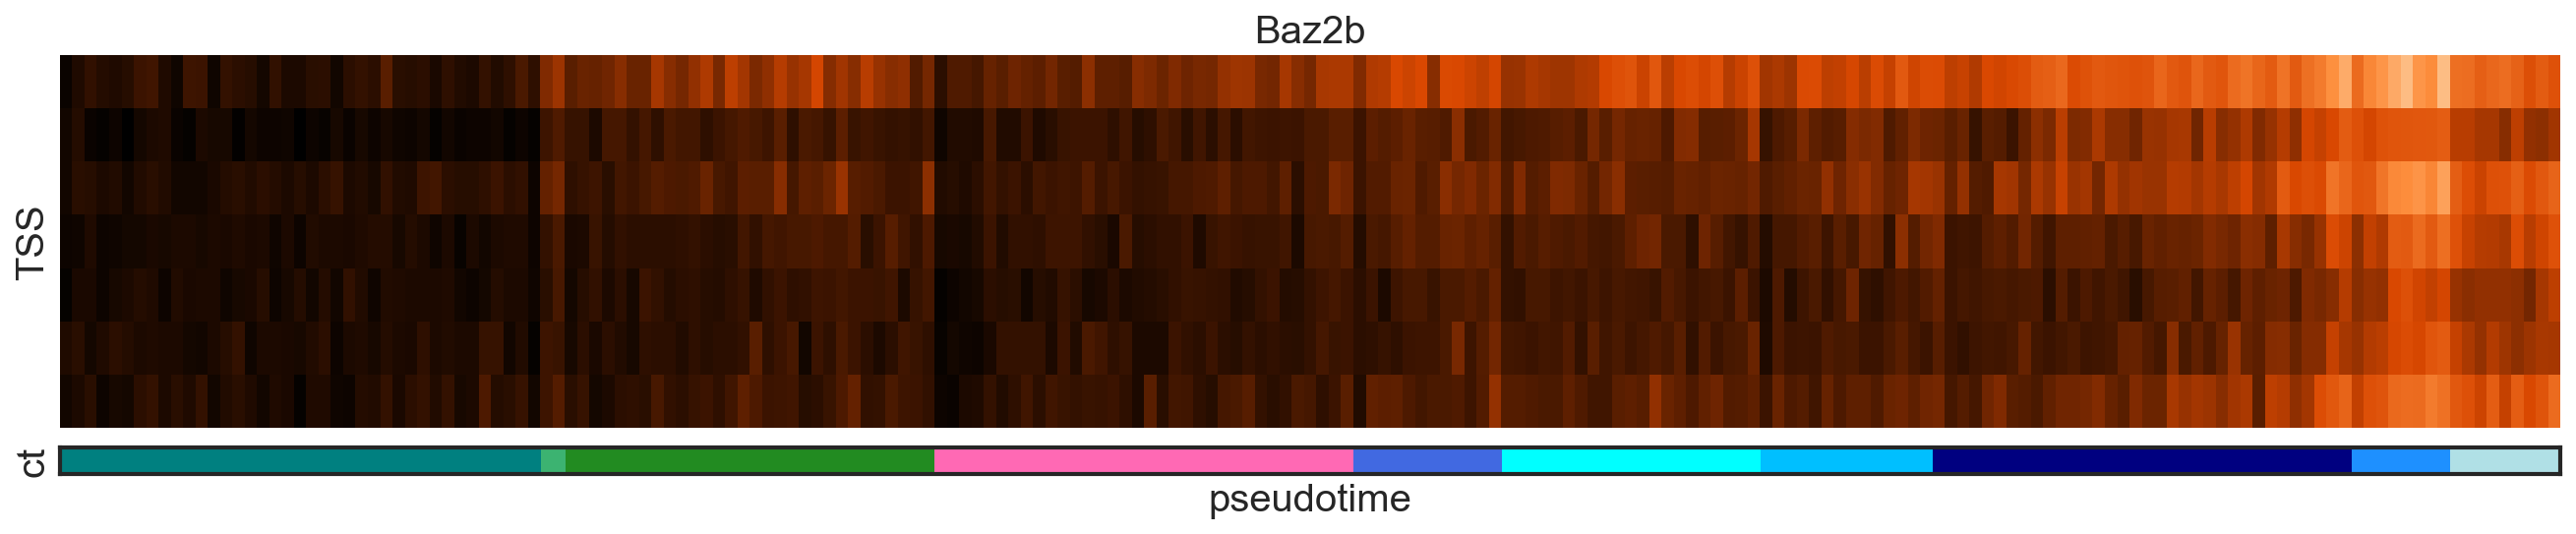

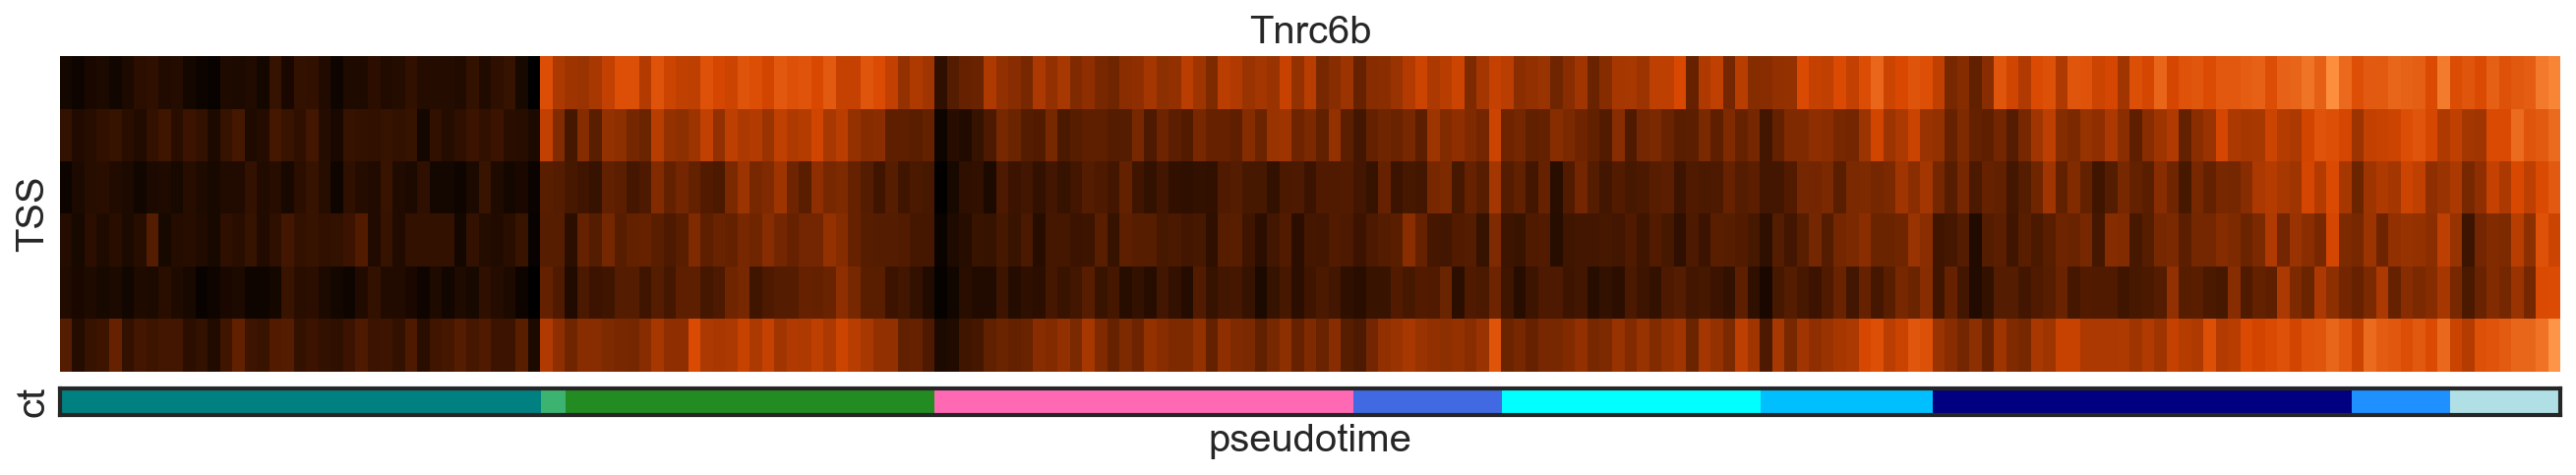

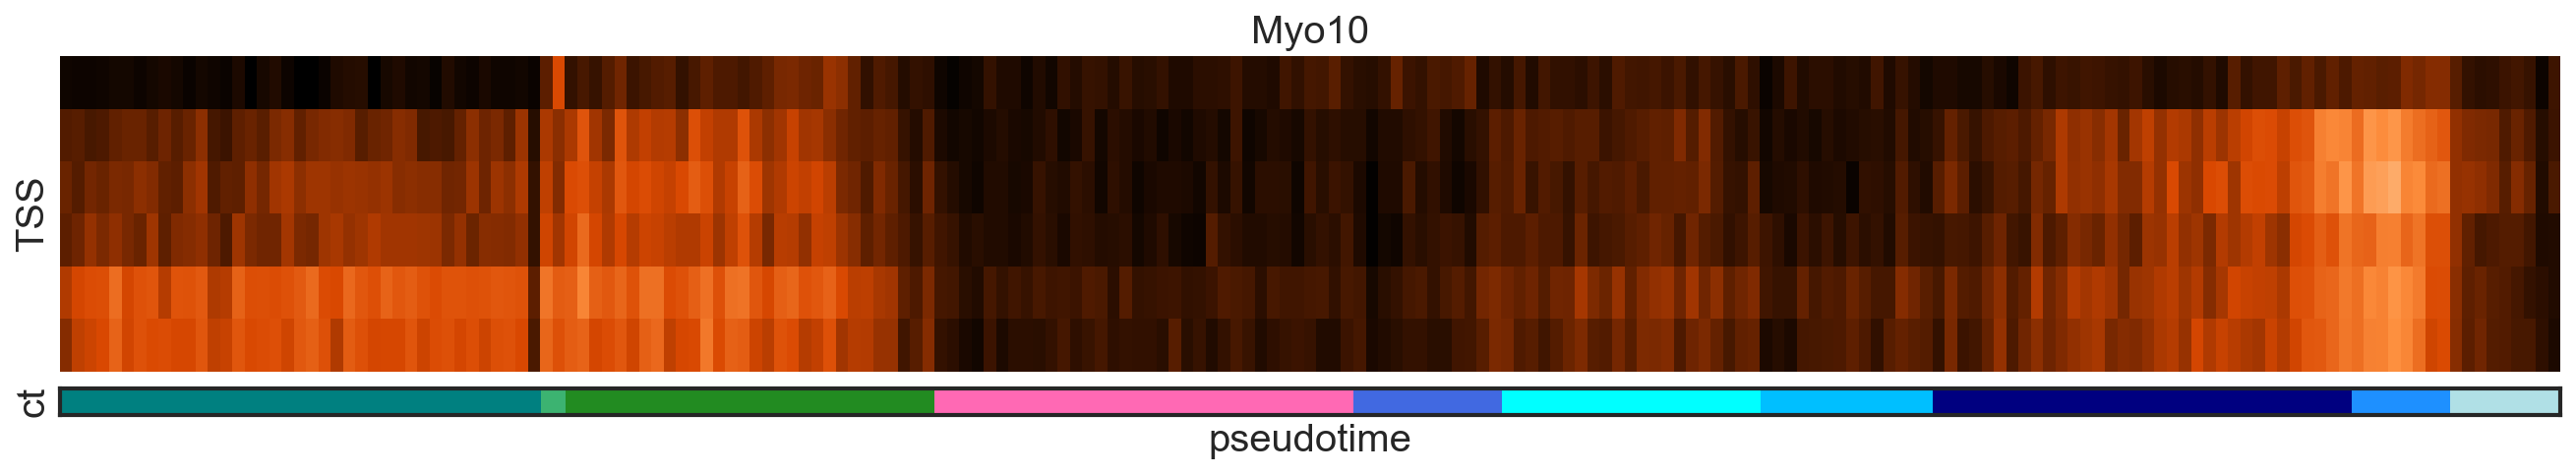

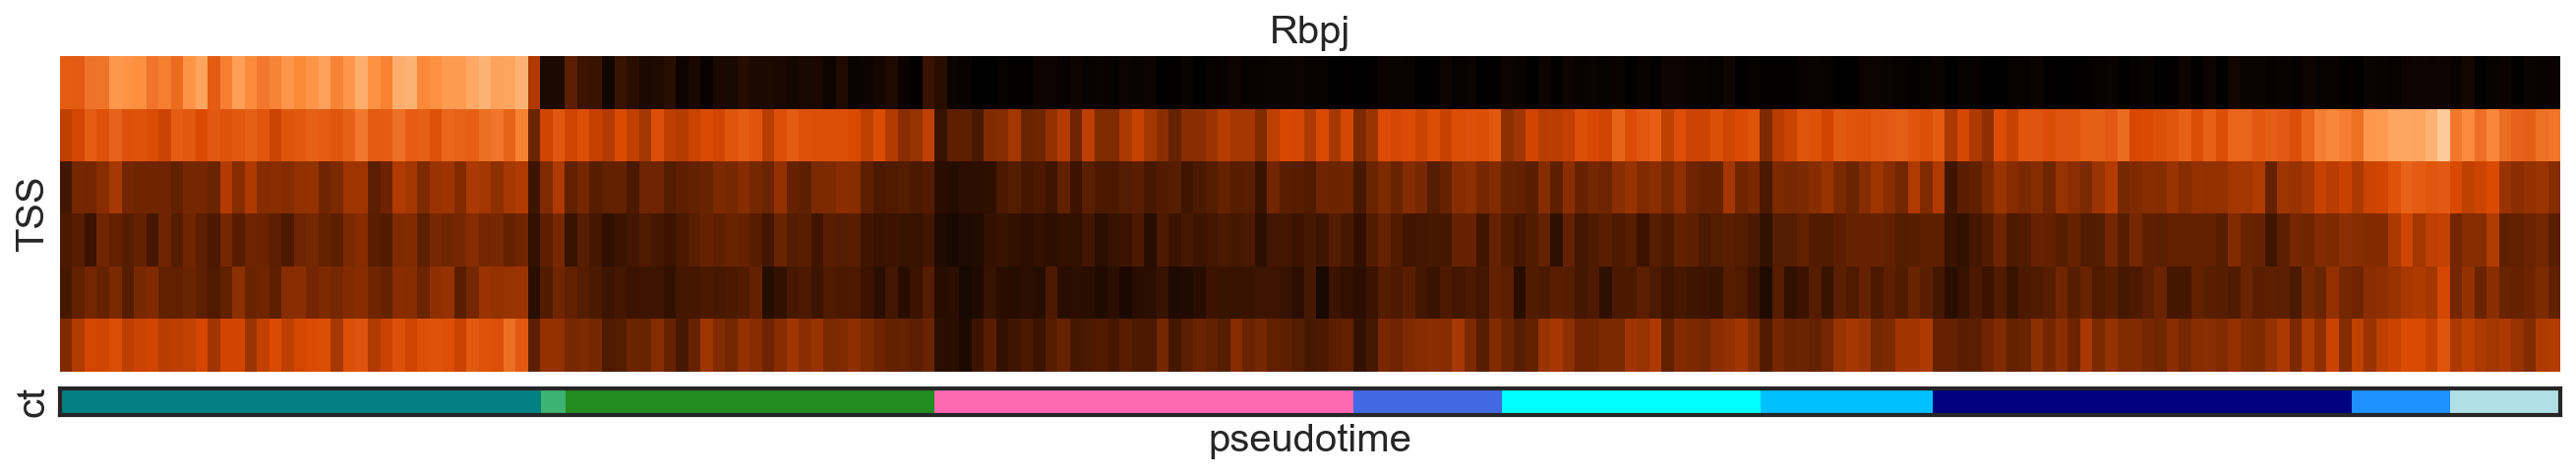

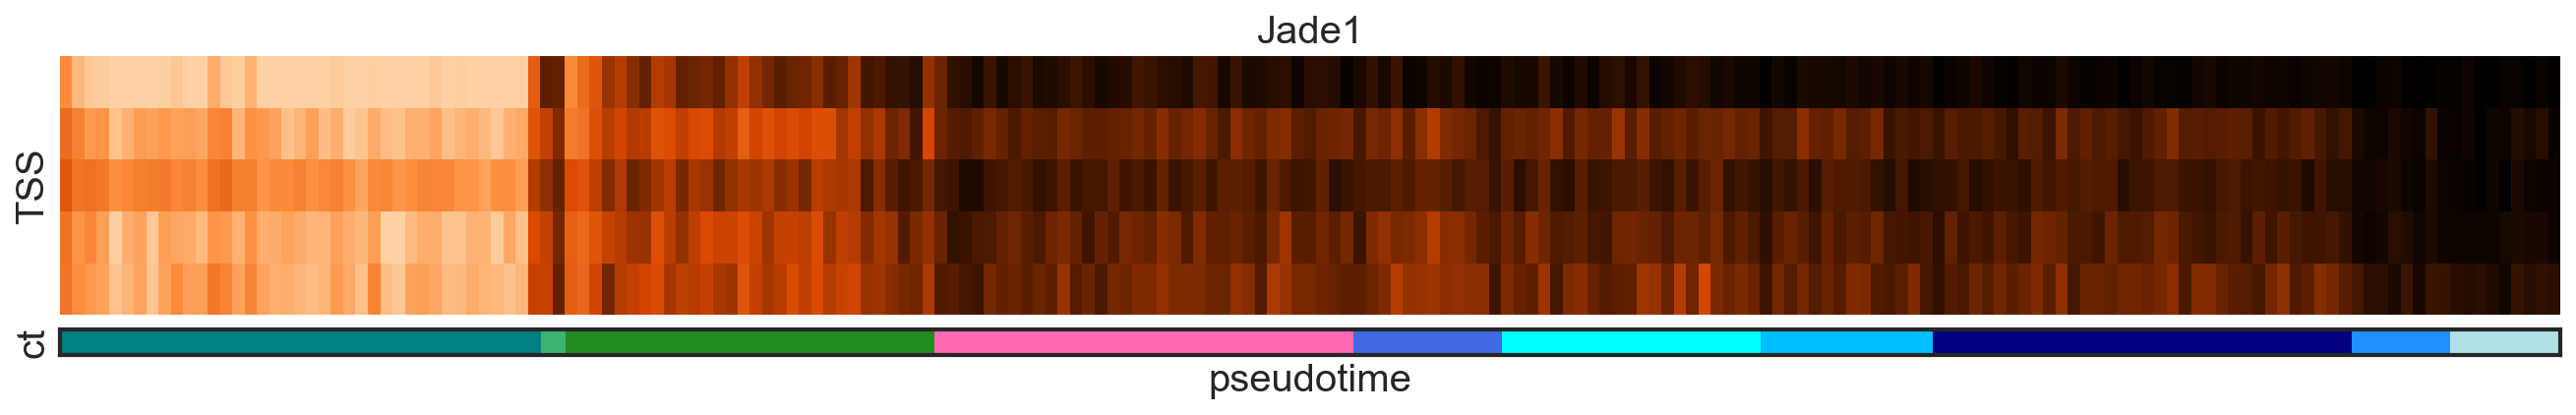

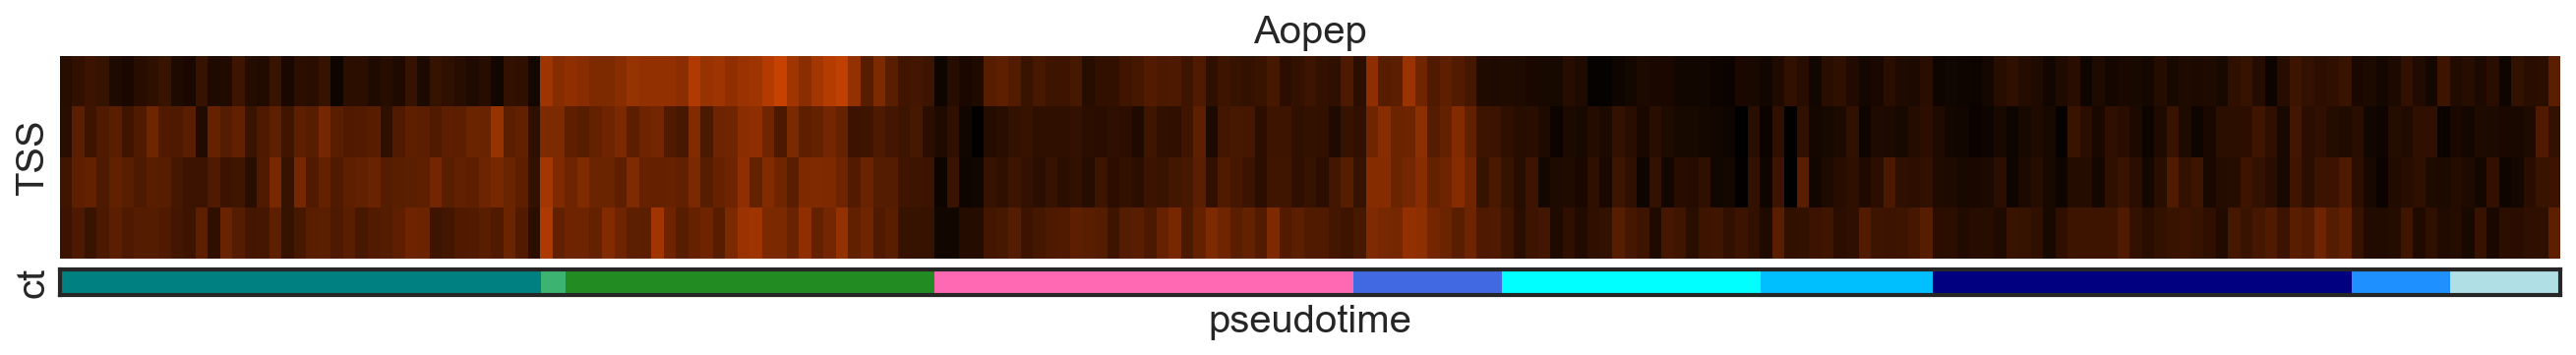

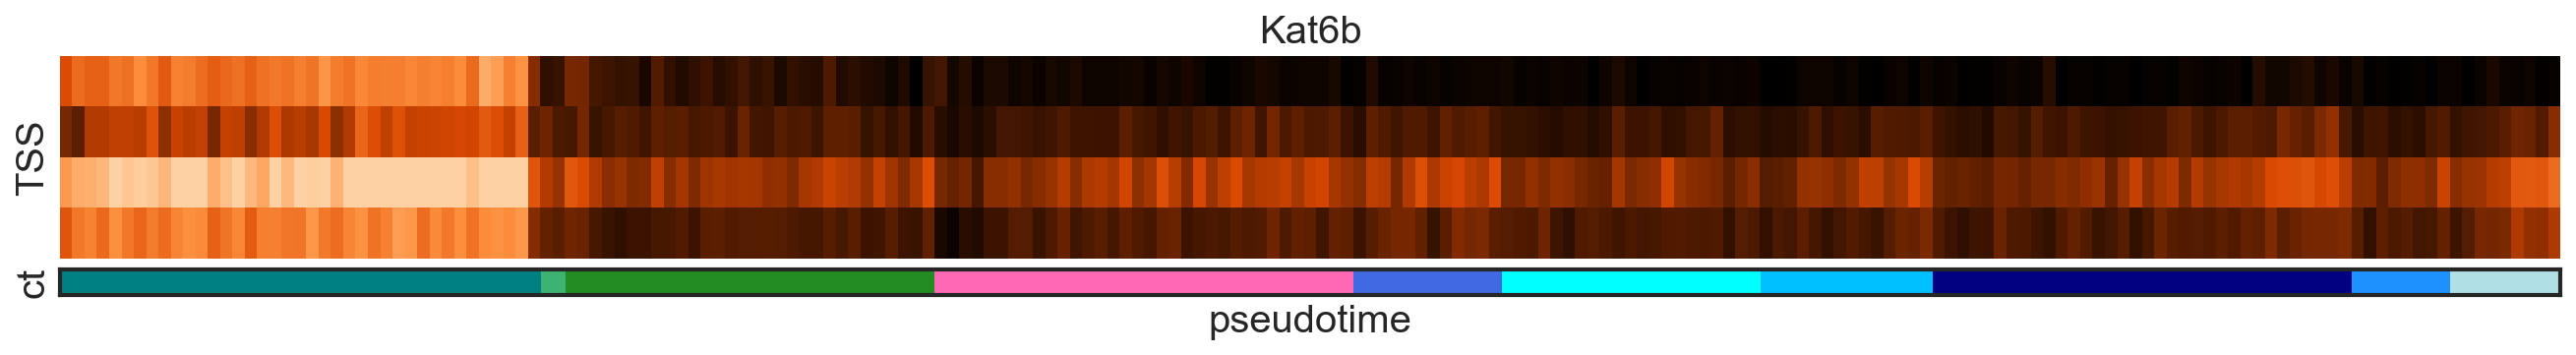

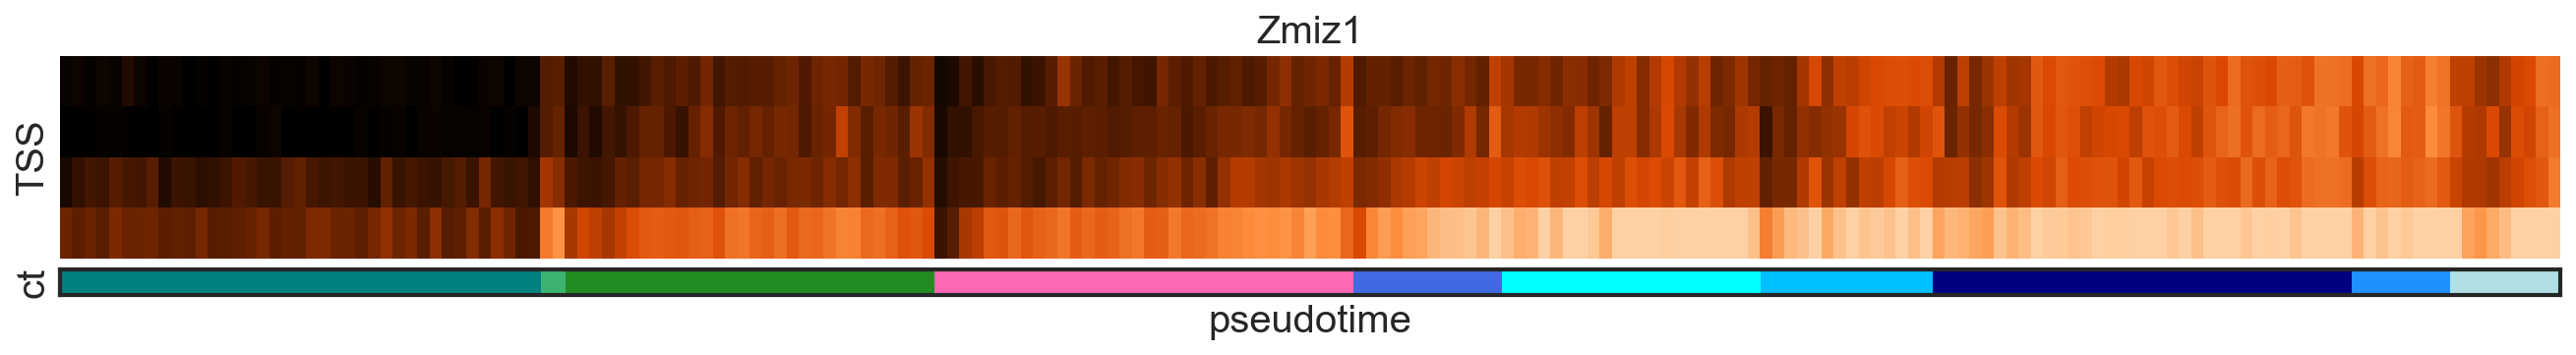

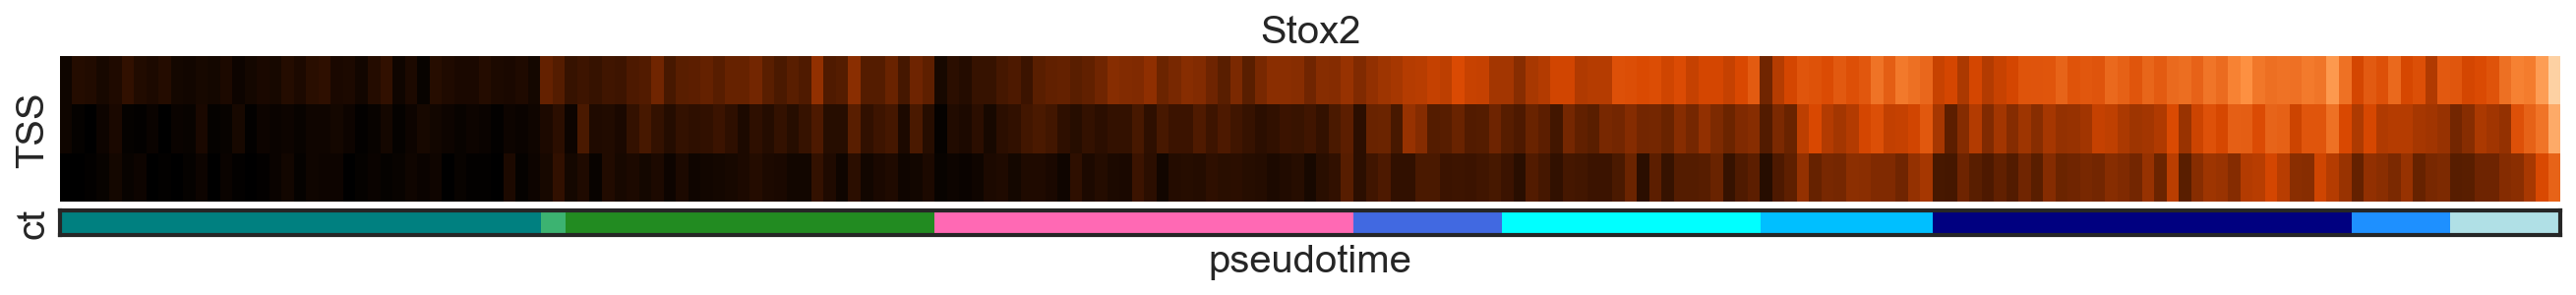

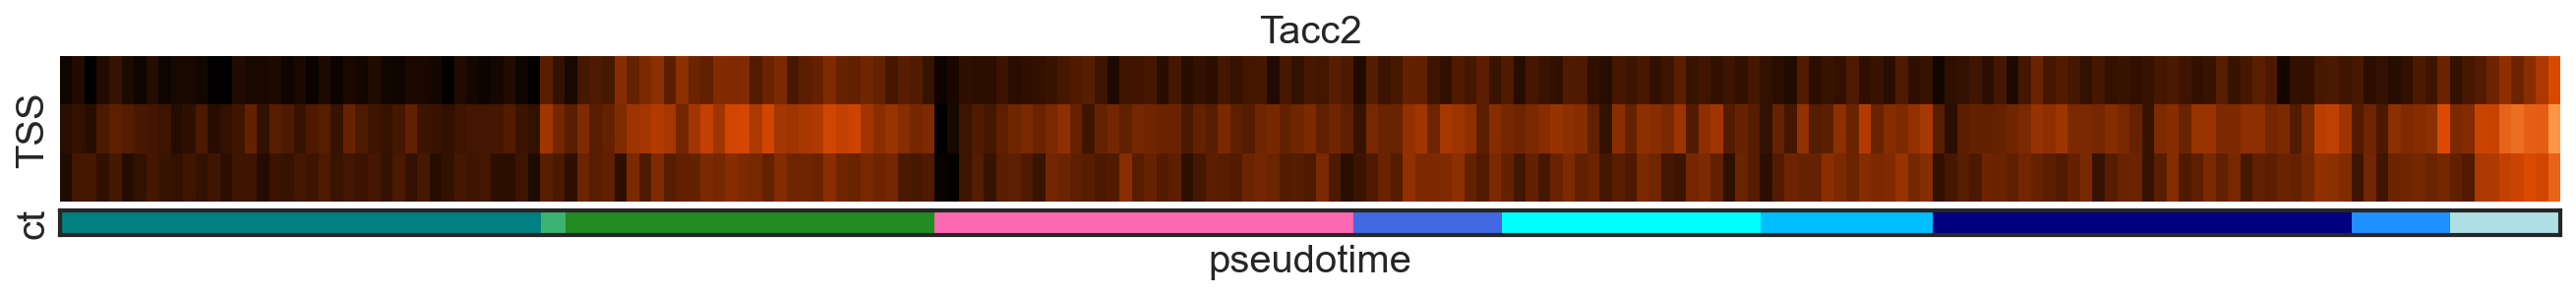

In [456]:
makeHeatmap(df_rna, 'Ectoderm',  palette = oranges_r, threshold = 6000, vmax = 3)

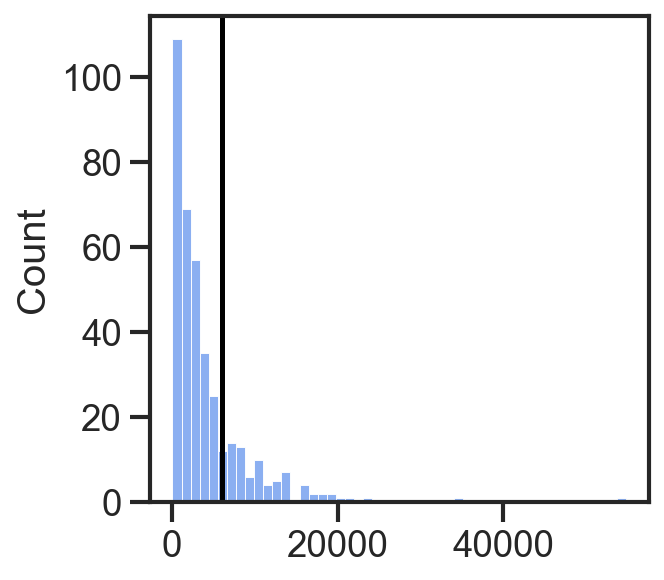

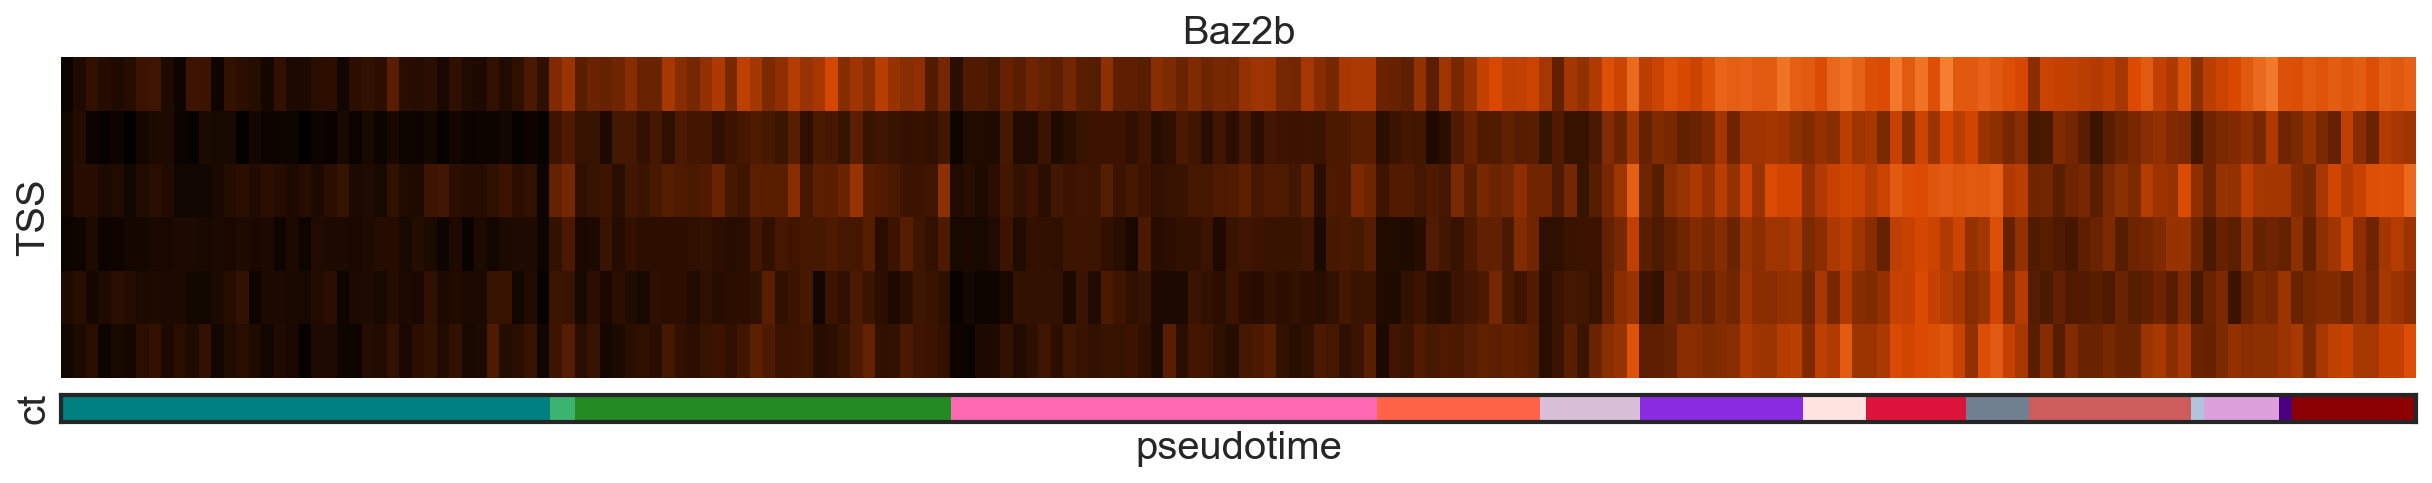

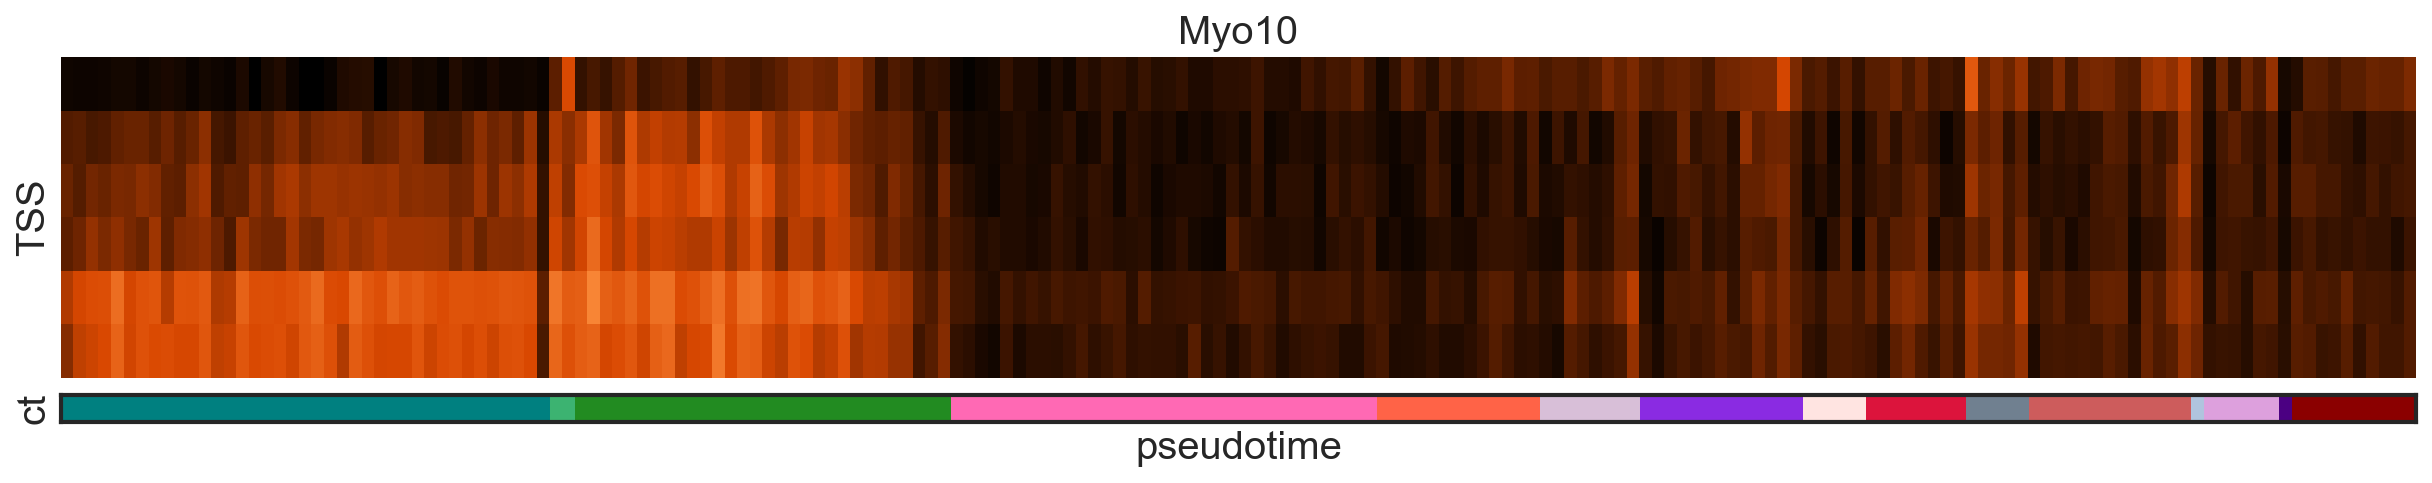

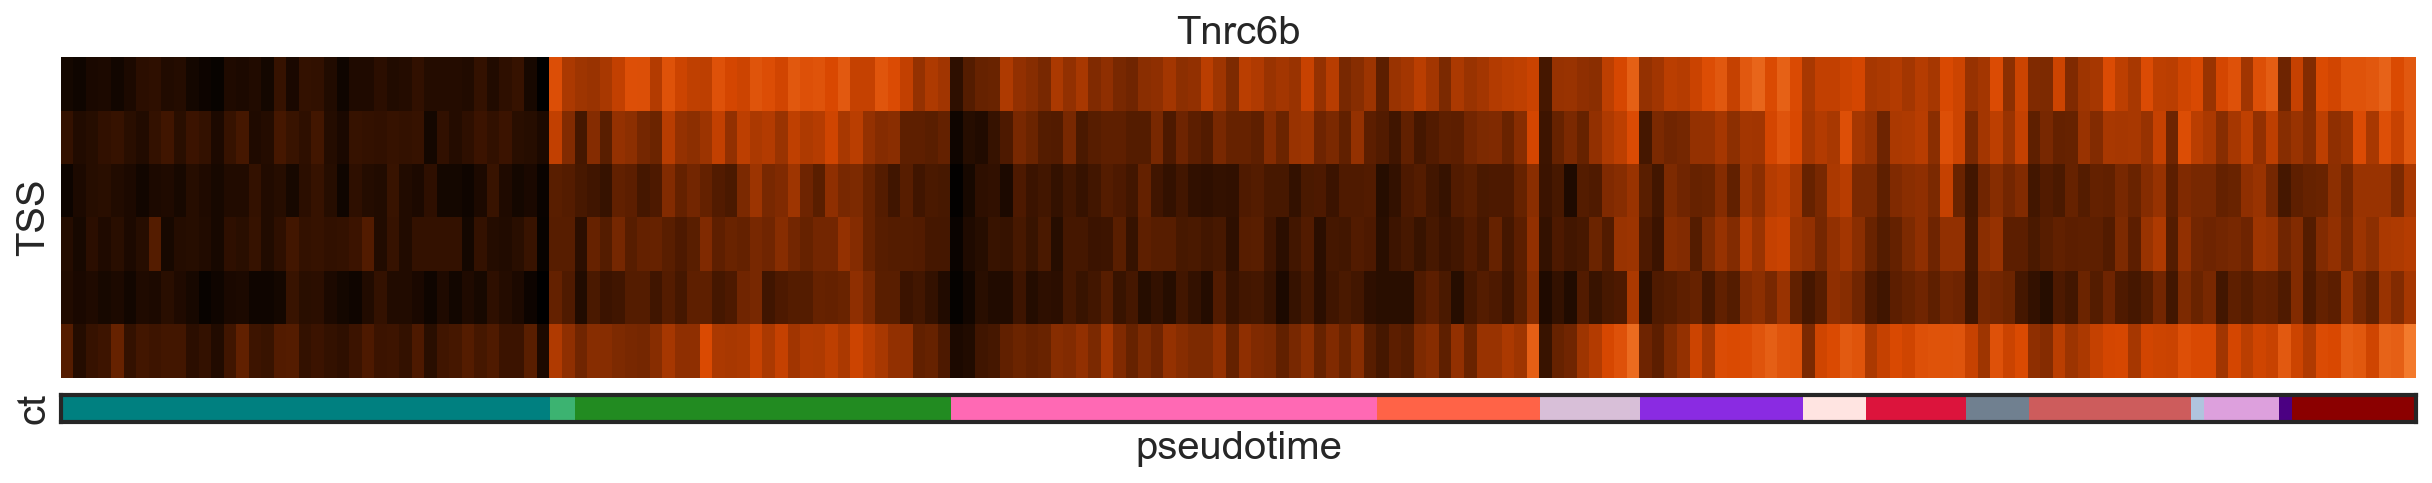

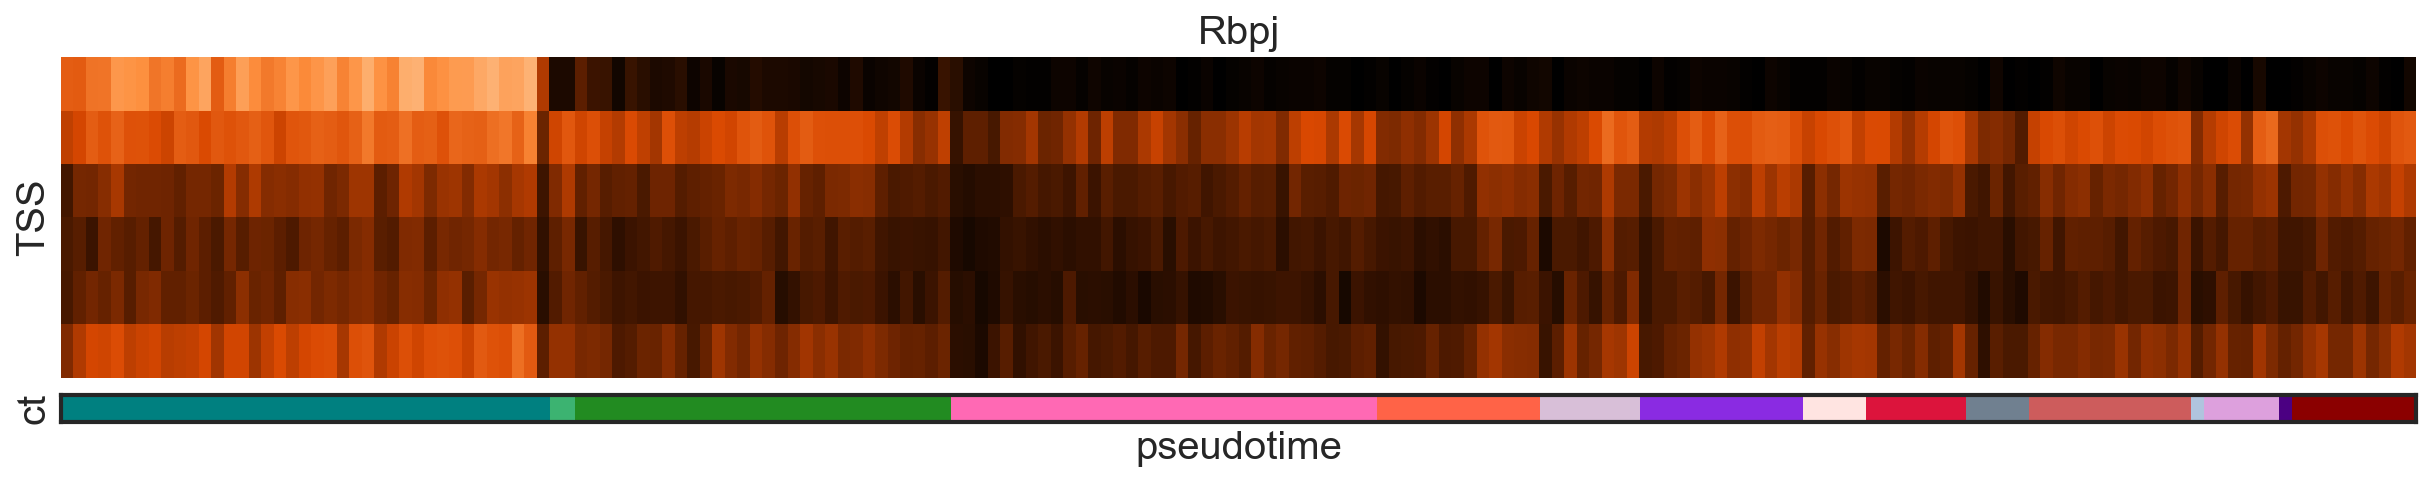

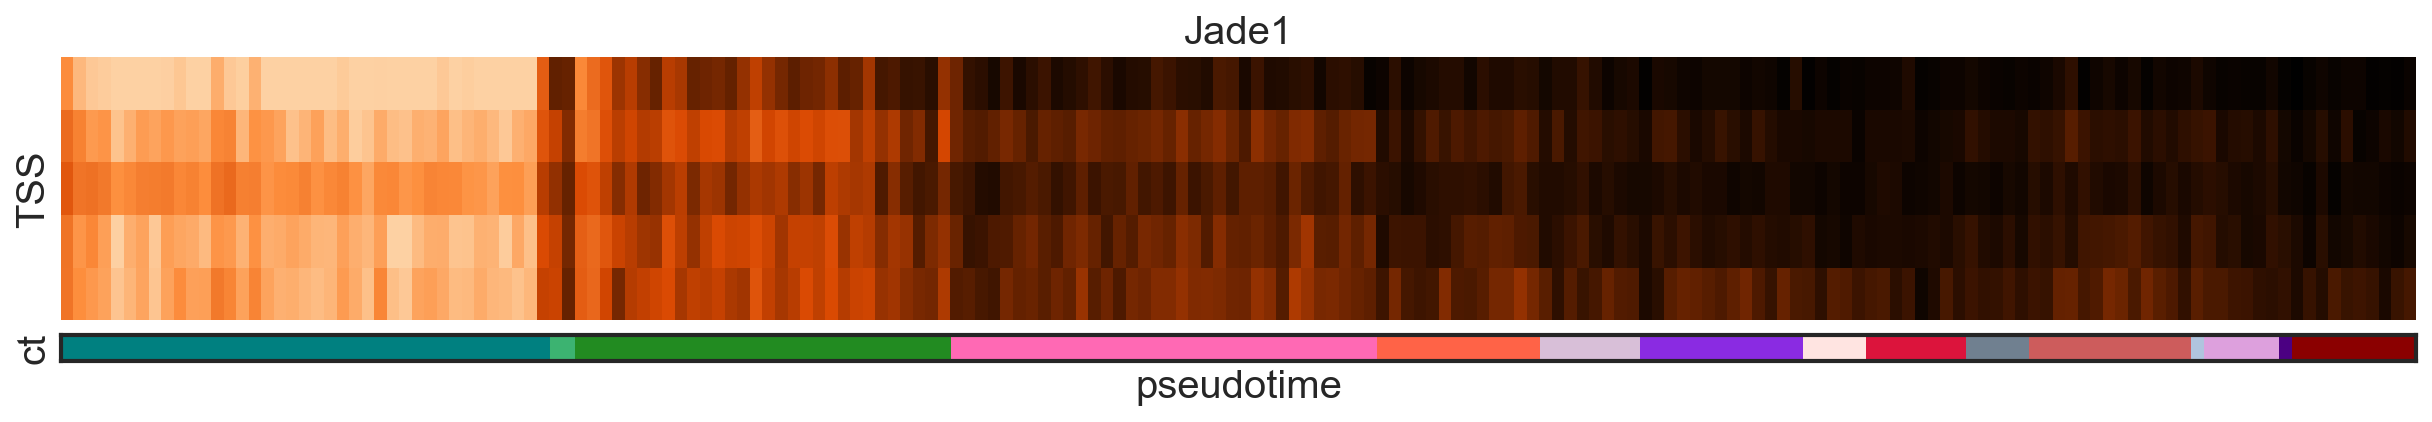

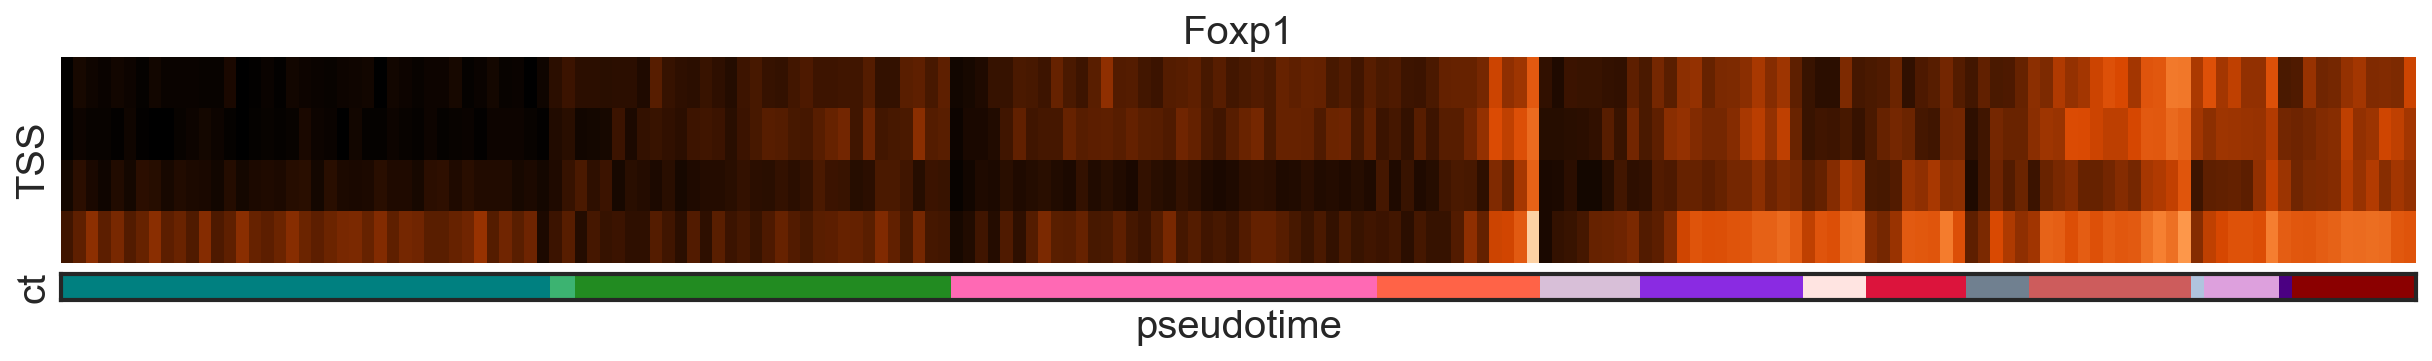

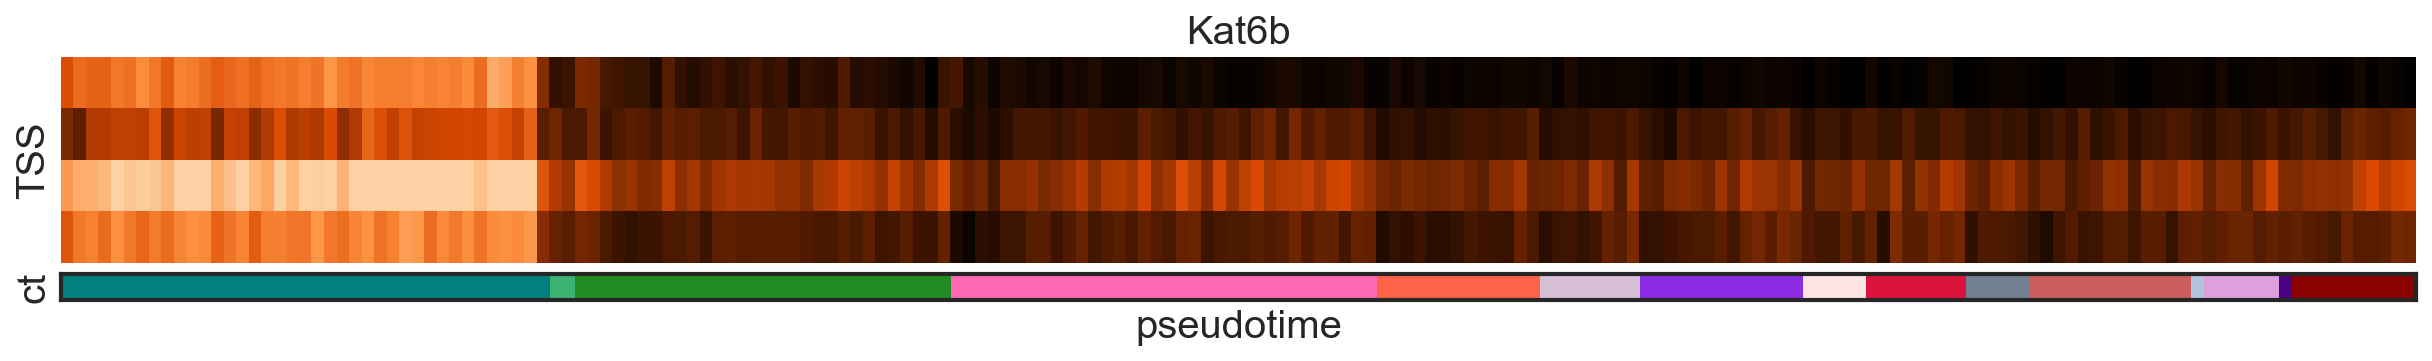

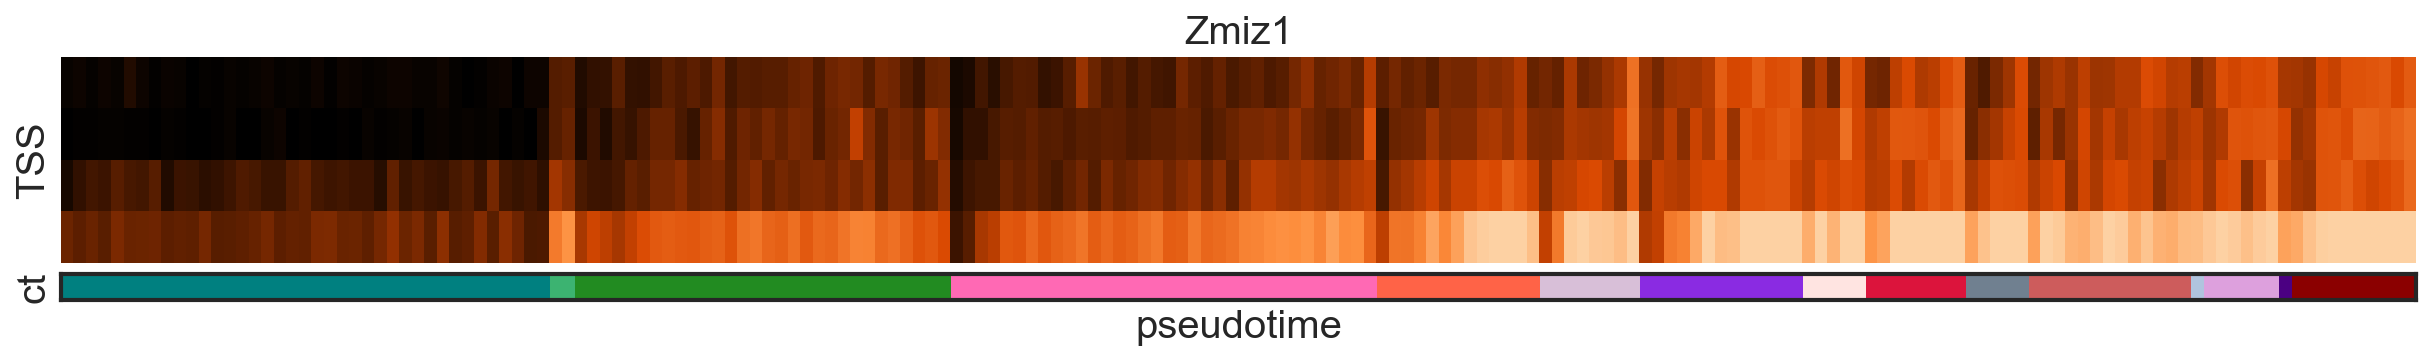

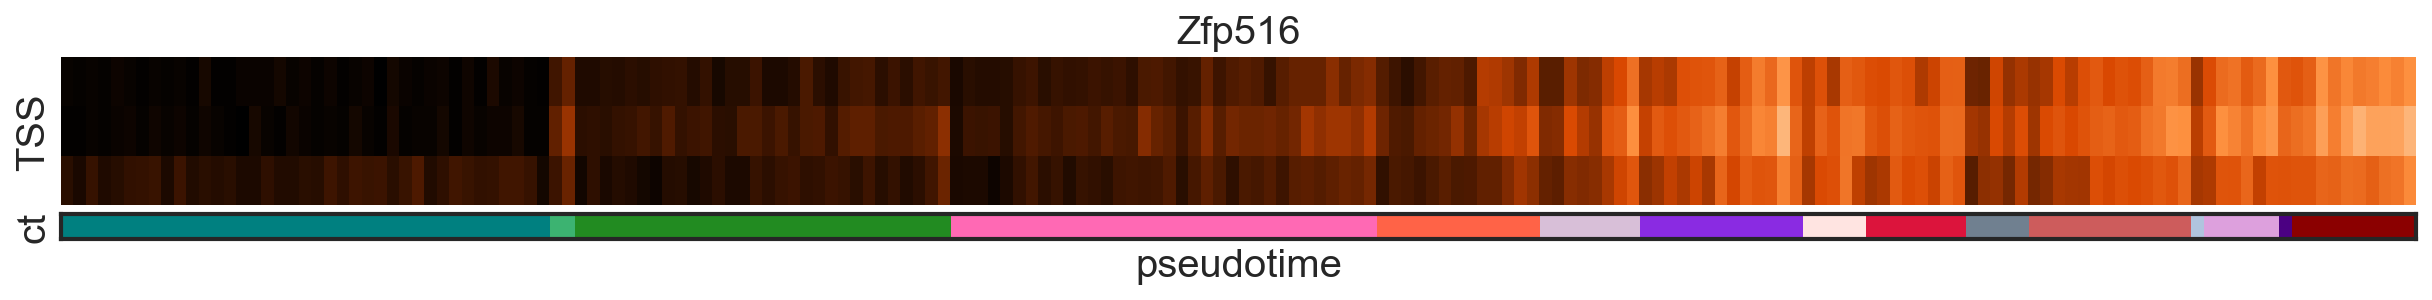

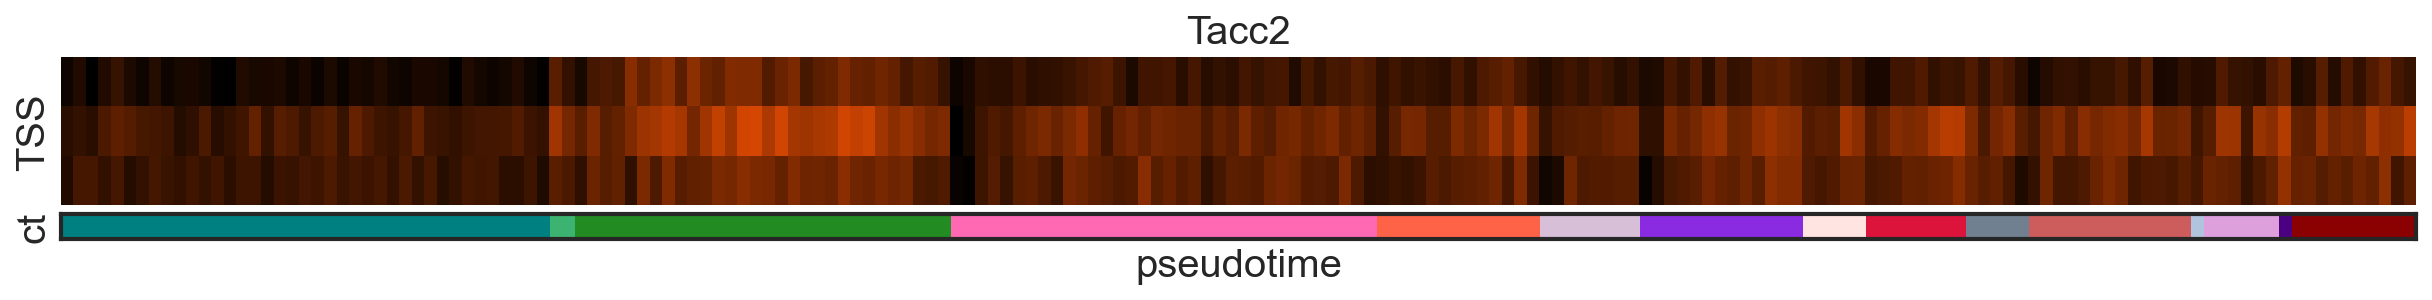

In [457]:
makeHeatmap(df_rna, 'Mesoderm',  palette = oranges_r, threshold = 6000, vmax = 3)

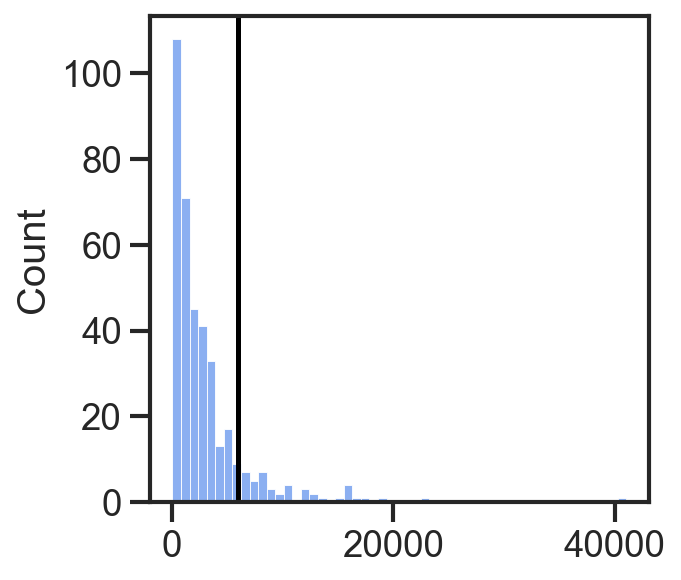

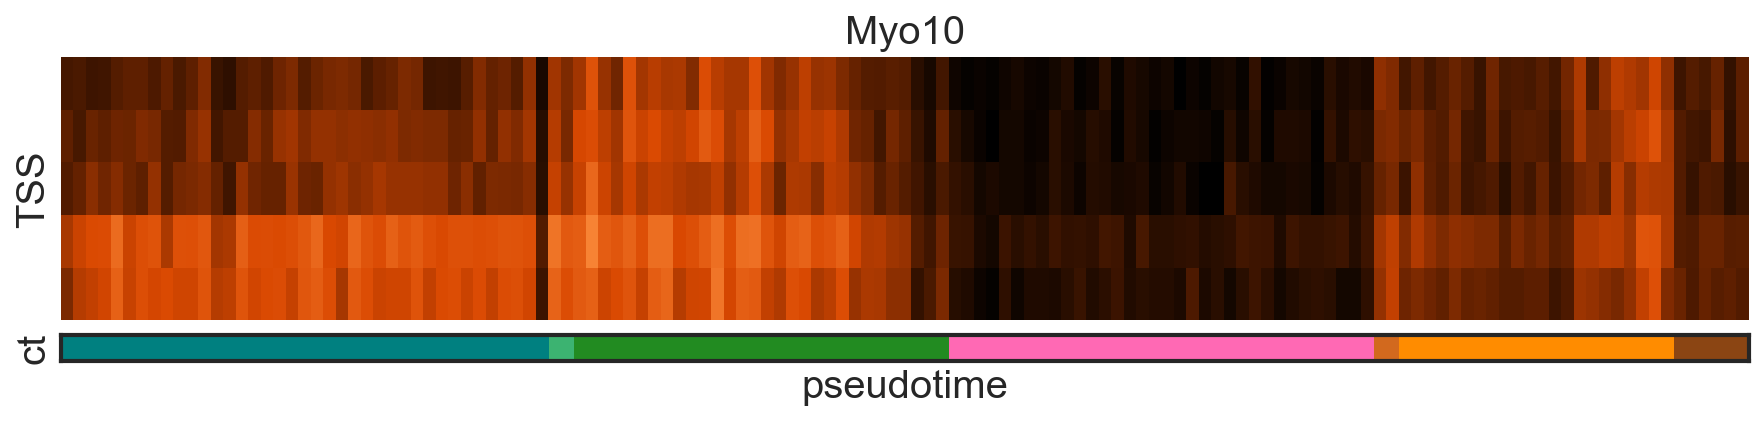

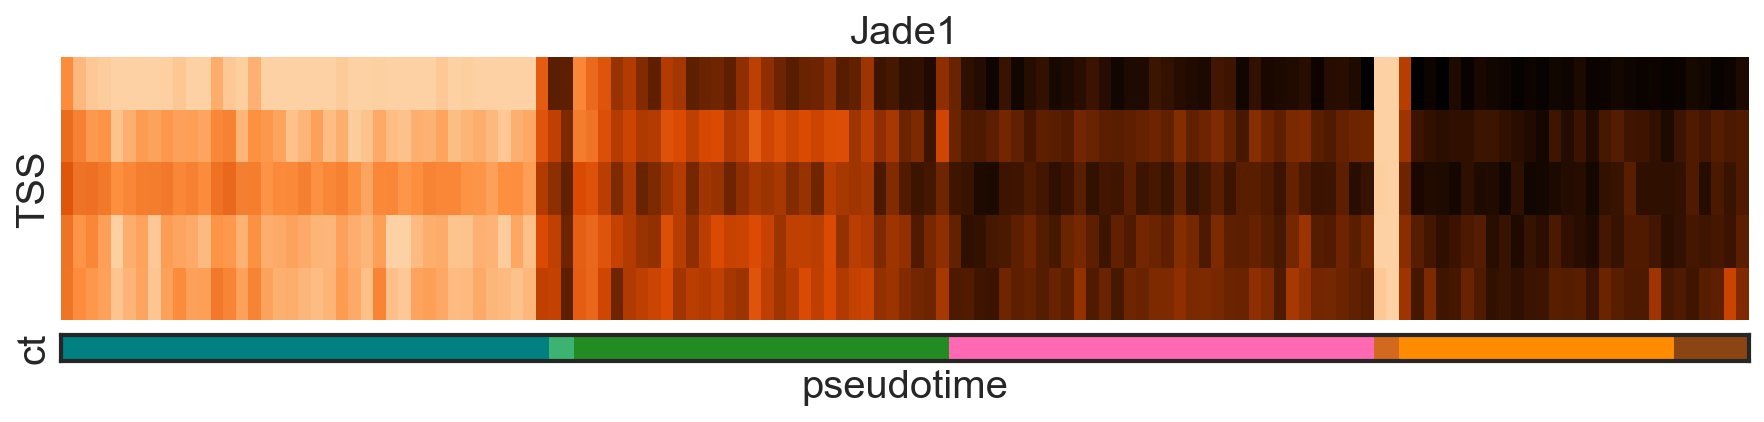

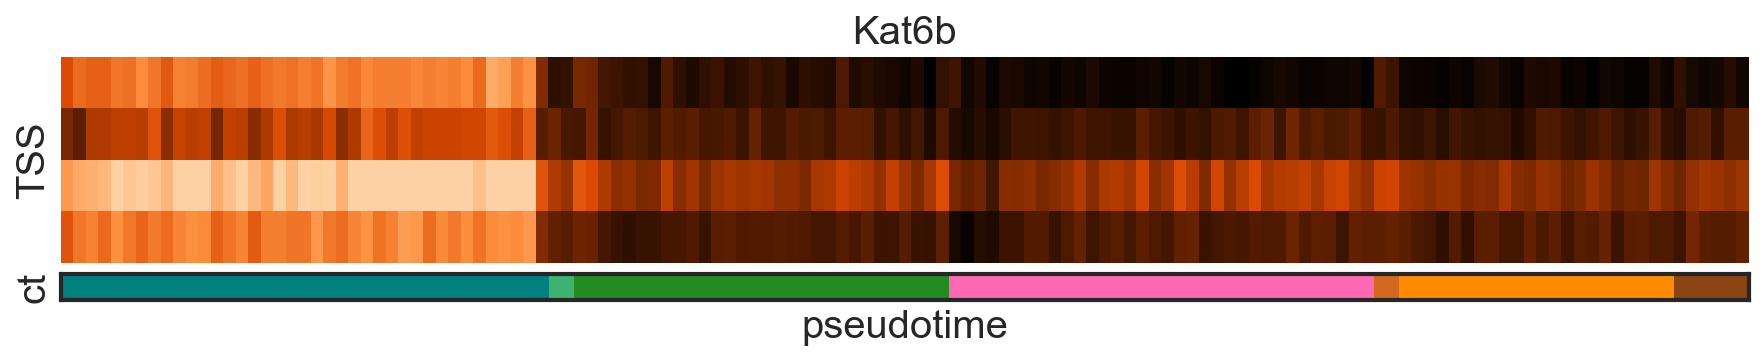

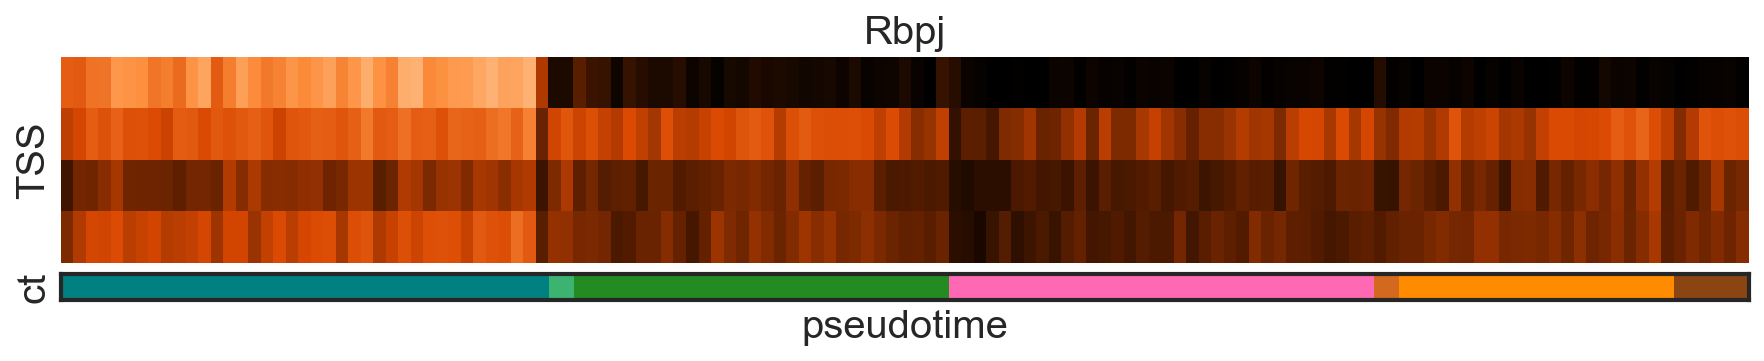

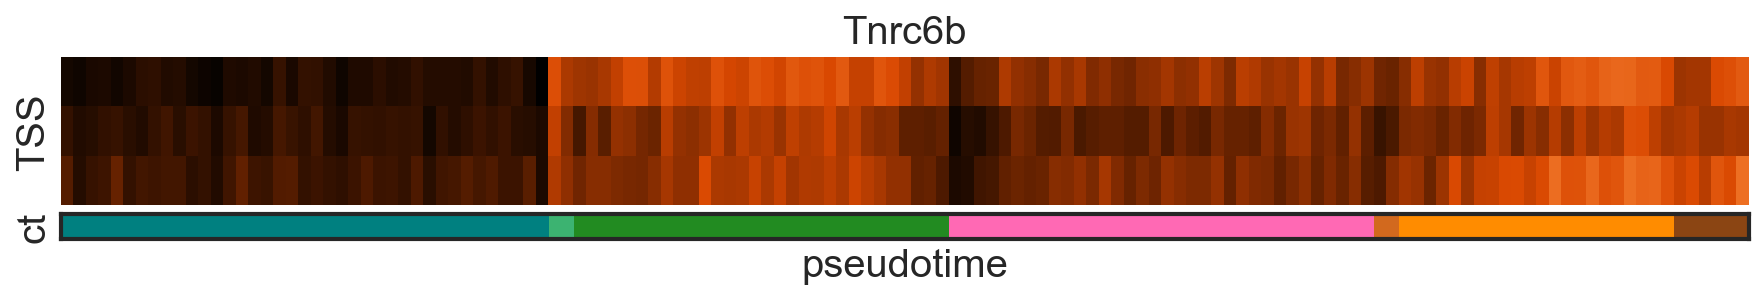

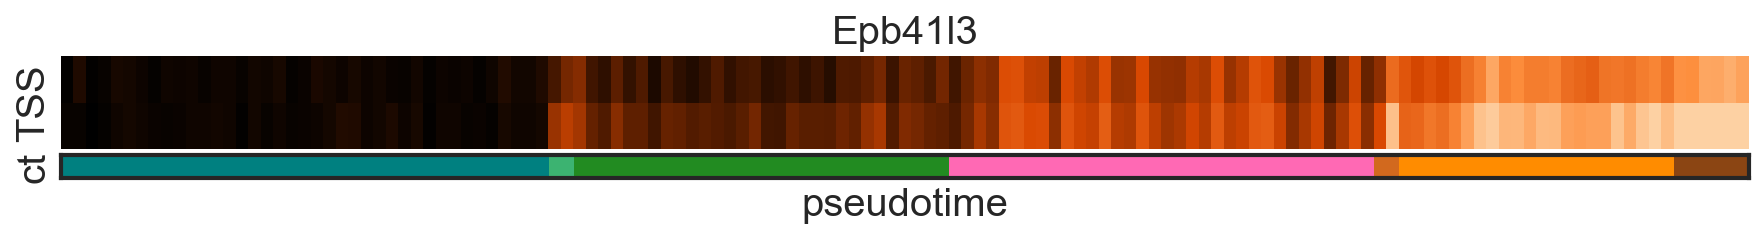

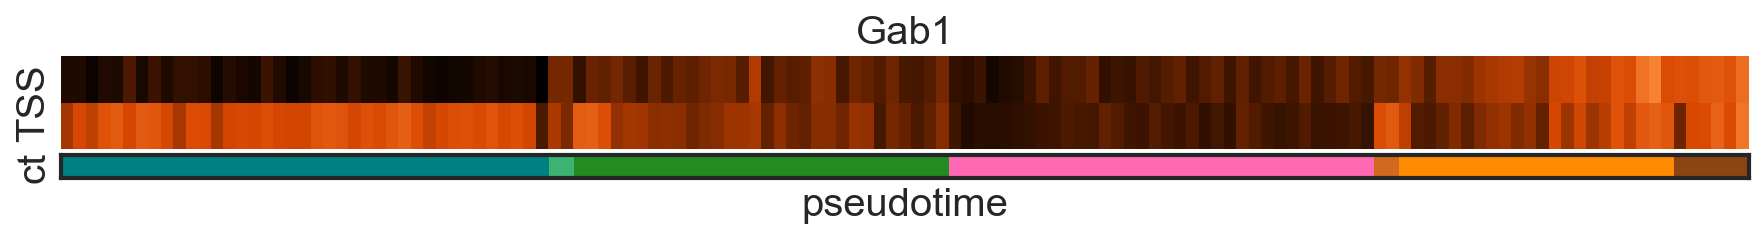

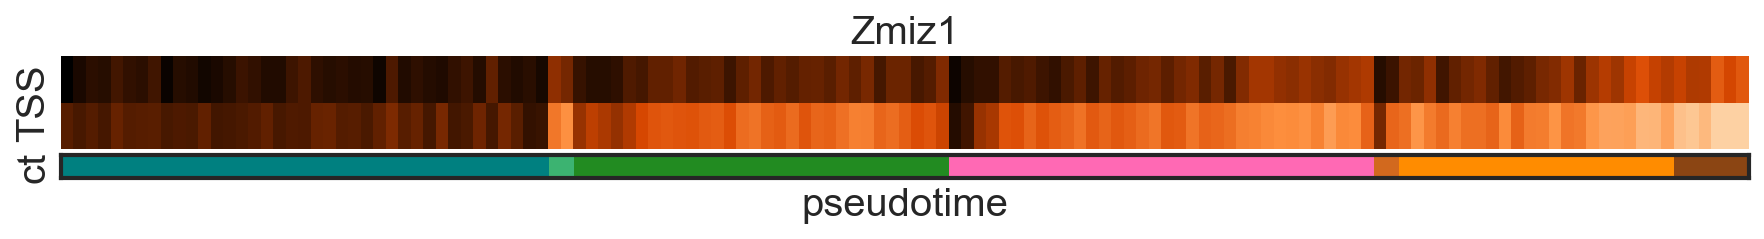

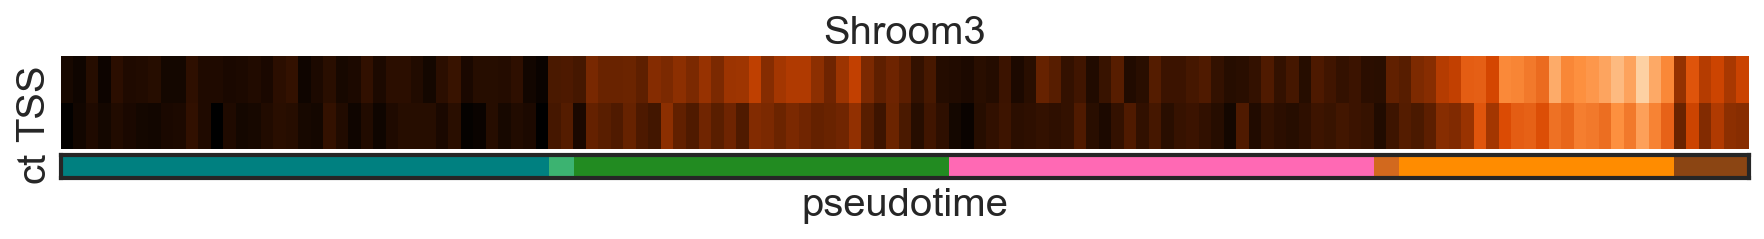

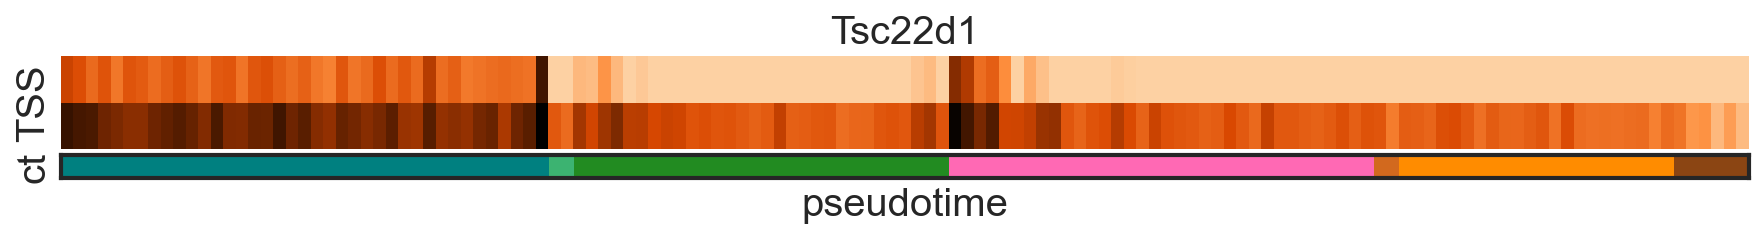

In [458]:
makeHeatmap(df_rna, 'Endoderm',  palette = oranges_r, threshold = 6000, vmax = 3)